# Experiments 19-22
### Tested: _Model versions / Size plant inference_

### Dataset:
- **Dataset:** 3.5m | 90º
- **Sizes:** small & mid
- **Split:** 640 px
- **Tags:** 5472 `plant-weed`
- **Train/Valid dist:** 66,6% / 33,3%

### Experiments:
1. ***YOLO v8** | 1000 epochs + Early stopping*
2. ***YOLO v9** | 1000 epochs + Early stopping*
3. ***YOLO v11** | 1000 epochs + Early stopping*
4. ***YOLO v12** | 1000 epochs + Early stopping*

## Models detail

### Model 1:
- **Model:** `yolov8m` *(Medium)*
- **Epochs:** ~1000
- **Batch:** 64
- **Freeze:** 10

### Model 2:
- **Model:** `yolov9m` *(Medium)*
- **Epochs:** ~1000
- **Batch:** 64
- **Freeze:** 10

### Model 3:
- **Model:** `yolo11m` *(Medium)*
- **Epochs:** ~1000
- **Batch:** 64
- **Freeze:** 10

### Model 4:
- **Model:** `yolo12m` *(Medium)*
- **Epochs:** ~1000
- **Batch:** 64
- **Freeze:** 10

In [ ]:
# CONFIG FOLDER PATH

# Get the project root directory (replace with your actual path)
project_root = "../../"
experiment_number = 2

# The folder you want to navigate to (relative to the root)
target_folder = f"docs/Experimentos/5 Model version/{experiment_number} set/"

## Init

In [181]:
scale: int = 500 # size for graphs (in pixels)

In [182]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D

In [183]:
# Construct the full path
target_path = os.path.join(project_root, target_folder)

# Change the current working directory
try:
    os.chdir(target_path)
    print(f"Current working directory: {os.getcwd()}")  # Verify
except FileNotFoundError:
    print(f"Error: Folder '{target_path}' not found. Check the path.")
except NotADirectoryError:
    print(f"Error: '{target_path}' is not a directory.")
except Exception as e:
    print(f"An error occurred: {e}")

Error: Folder '../../docs/Experimentos/3 Hyperparams/2 set/' not found. Check the path.


In [184]:
# Reset to the root path
# os.chdir(project_root)
# print(f"Current working directory: {os.getcwd()}") #Verify

In [185]:
best_models = pd.DataFrame(
    columns=['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2', 'train_time'],
       data = None
       )

#### Functions

In [186]:
def graph_training_metrics(df: pd.DataFrame, epoch: np.int64, graph: str="tight"):
    """
    Plots training and validation metrics from a training log DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing training metrics, including columns
                           'epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
                           'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
                           'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
                           'metrics/mAP50-95(B)', and optionally 'lr/pg0' for the 'lr' graph.
        graph (str, optional): Type of graph to display. Options are:
            - "tight": Displays loss and metrics in a single row.
            - "full": Displays loss and metrics in two rows.
            - "lr": Displays loss, metrics, and learning rate in three rows.
            Defaults to "tight".

    Raises:
        ValueError: If the 'graph' parameter is not one of "tight", "full", or "lr".
    """
    graph = graph.lower()

    # Tight view (one row)
    if graph == "tight":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 6))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(1, 2, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

        # Graficar métricas de validación
        plt.subplot(1, 2, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X
        plt.legend()


    # Full view (two rows)
    elif graph == "full":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 12))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(2, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

        # Graficar métricas de validación
        plt.subplot(2, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X

    # Shows also Lr graph (three rows)
    elif graph == "lr":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 15))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(3, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

        # Graficar métricas de validación
        plt.subplot(3, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X
        plt.legend()

        # Gráfico de evolución del learning rate
        plt.subplot(3, 1, 3)
        plt.plot(df["epoch"], df["lr/pg0"], label="Learning Rate (pg0)", color="cadetblue", marker='.', linestyle='-')
        plt.xlabel("Epoch")
        plt.ylabel("Learning Rate")
        plt.title("Learning Rate Evolution")
        plt.grid(True)

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

    else:
        raise ValueError(f"Invalid graph parameter: '{graph}'. Must be one of 'tight', 'full', or 'lr'.")

    plt.tight_layout()
    plt.show()

In [187]:
def graph_LrLoss(df):
    """Generates a 3D plot of Learning Rate vs. Loss vs. Epoch."""

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Data
    epochs = df['epoch']
    losses = df['val/cls_loss']  # or df['train/cls_loss'], or combined as needed.
    lrs = df['lr/pg0']

    # Scatter plot
    ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis', marker='o')

    # Labels
    ax.set_xlabel('Learning Rate (lr/pg0)')
    ax.set_ylabel('Classification Loss (val/cls_loss)')
    ax.set_zlabel('Epoch')
    ax.set_title('3D Plot: Learning Rate vs. Loss vs. Epoch')

    # Color bar
    fig.colorbar(ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis'), label='Loss Value')

    plt.show()

In [188]:
def graph_LrLoss_3D(df, set: str='val'):
    """Generates an interactive 3D plot of Learning Rate vs. Loss vs. Epoch."""

    if set.lower() == 'val':
        print("Validation set")
        loss_set = 'val/cls_loss'
        title_set = 'Validation'
    elif set.lower() == 'train':
        print("Training set")
        loss_set = 'train/cls_loss'
        title_set = 'Train'
    else:
        print("Debe indicarse el set de entrenamiento: set debe ser igual 'val' o 'train'")
        return  

    fig = go.Figure(data=[go.Scatter3d(
        x=df['lr/pg0'],
        y=df[loss_set],
        z=df['epoch'],
        mode='markers',
        marker=dict(
            size=5,
            color=df[loss_set], # color based on loss value
            colorscale='Viridis',
            opacity=0.8,
            colorbar=dict(title='Loss Value')  # Add colorbar
        )
    )])

    fig.update_layout(
        margin=dict(l=0, r=0, b=0, t=0),
        scene=dict(
            xaxis=dict(title='Learning Rate (lr/pg0)'),
            yaxis=dict(title=f'Classification Loss ({loss_set})'),
            zaxis=dict(title='Epoch'),
        ),
        title=f'Learning Rate vs. {title_set} Loss vs. Epoch'
    )

    fig.show()

----

# Experimentos

## Experiment 19
### *YOLO V8 | ~1000 epochs*

In [189]:
folder = "v8/detect/train/"

In [190]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df1 = pd.read_csv(file_path)
df = df1.copy()
df1.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
385,386,2985.60,1.16564,0.64824,1.00079,0.51783,0.44915,0.42026,0.13158,2.71083,1.35703,1.74103,0.001238,0.001238,0.001238
386,387,2993.32,1.16003,0.64194,1.00164,0.49944,0.45828,0.41433,0.13166,2.68775,1.35982,1.71300,0.001236,0.001236,0.001236
387,388,3001.15,1.20936,0.66569,1.00235,0.51585,0.48194,0.43181,0.13696,2.64976,1.37377,1.70644,0.001234,0.001234,0.001234
388,389,3008.95,1.19211,0.66791,1.00913,0.51908,0.48609,0.42939,0.13653,2.62402,1.36774,1.70599,0.001232,0.001232,0.001232
389,390,3016.91,1.16665,0.65433,1.00045,0.52793,0.48187,0.43890,0.13979,2.61230,1.35686,1.70114,0.001230,0.001230,0.001230


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [191]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 50.282 min


#### Best epoch

In [192]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
360,361,2792.5,1.20257,0.66073,1.00807,0.54572,0.48236,0.45092,0.14408,2.61832,1.37244,1.71799,0.001287,0.001287,0.001287,50.281833


In [193]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 361 con mAP50 de 0.451


In [194]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [195]:
TP = 1374
FP = 1184
FN = 1035
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 3593


In [196]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.3824102421374896, 0.32952964096855, 0.2880601168939605)

### Graphs

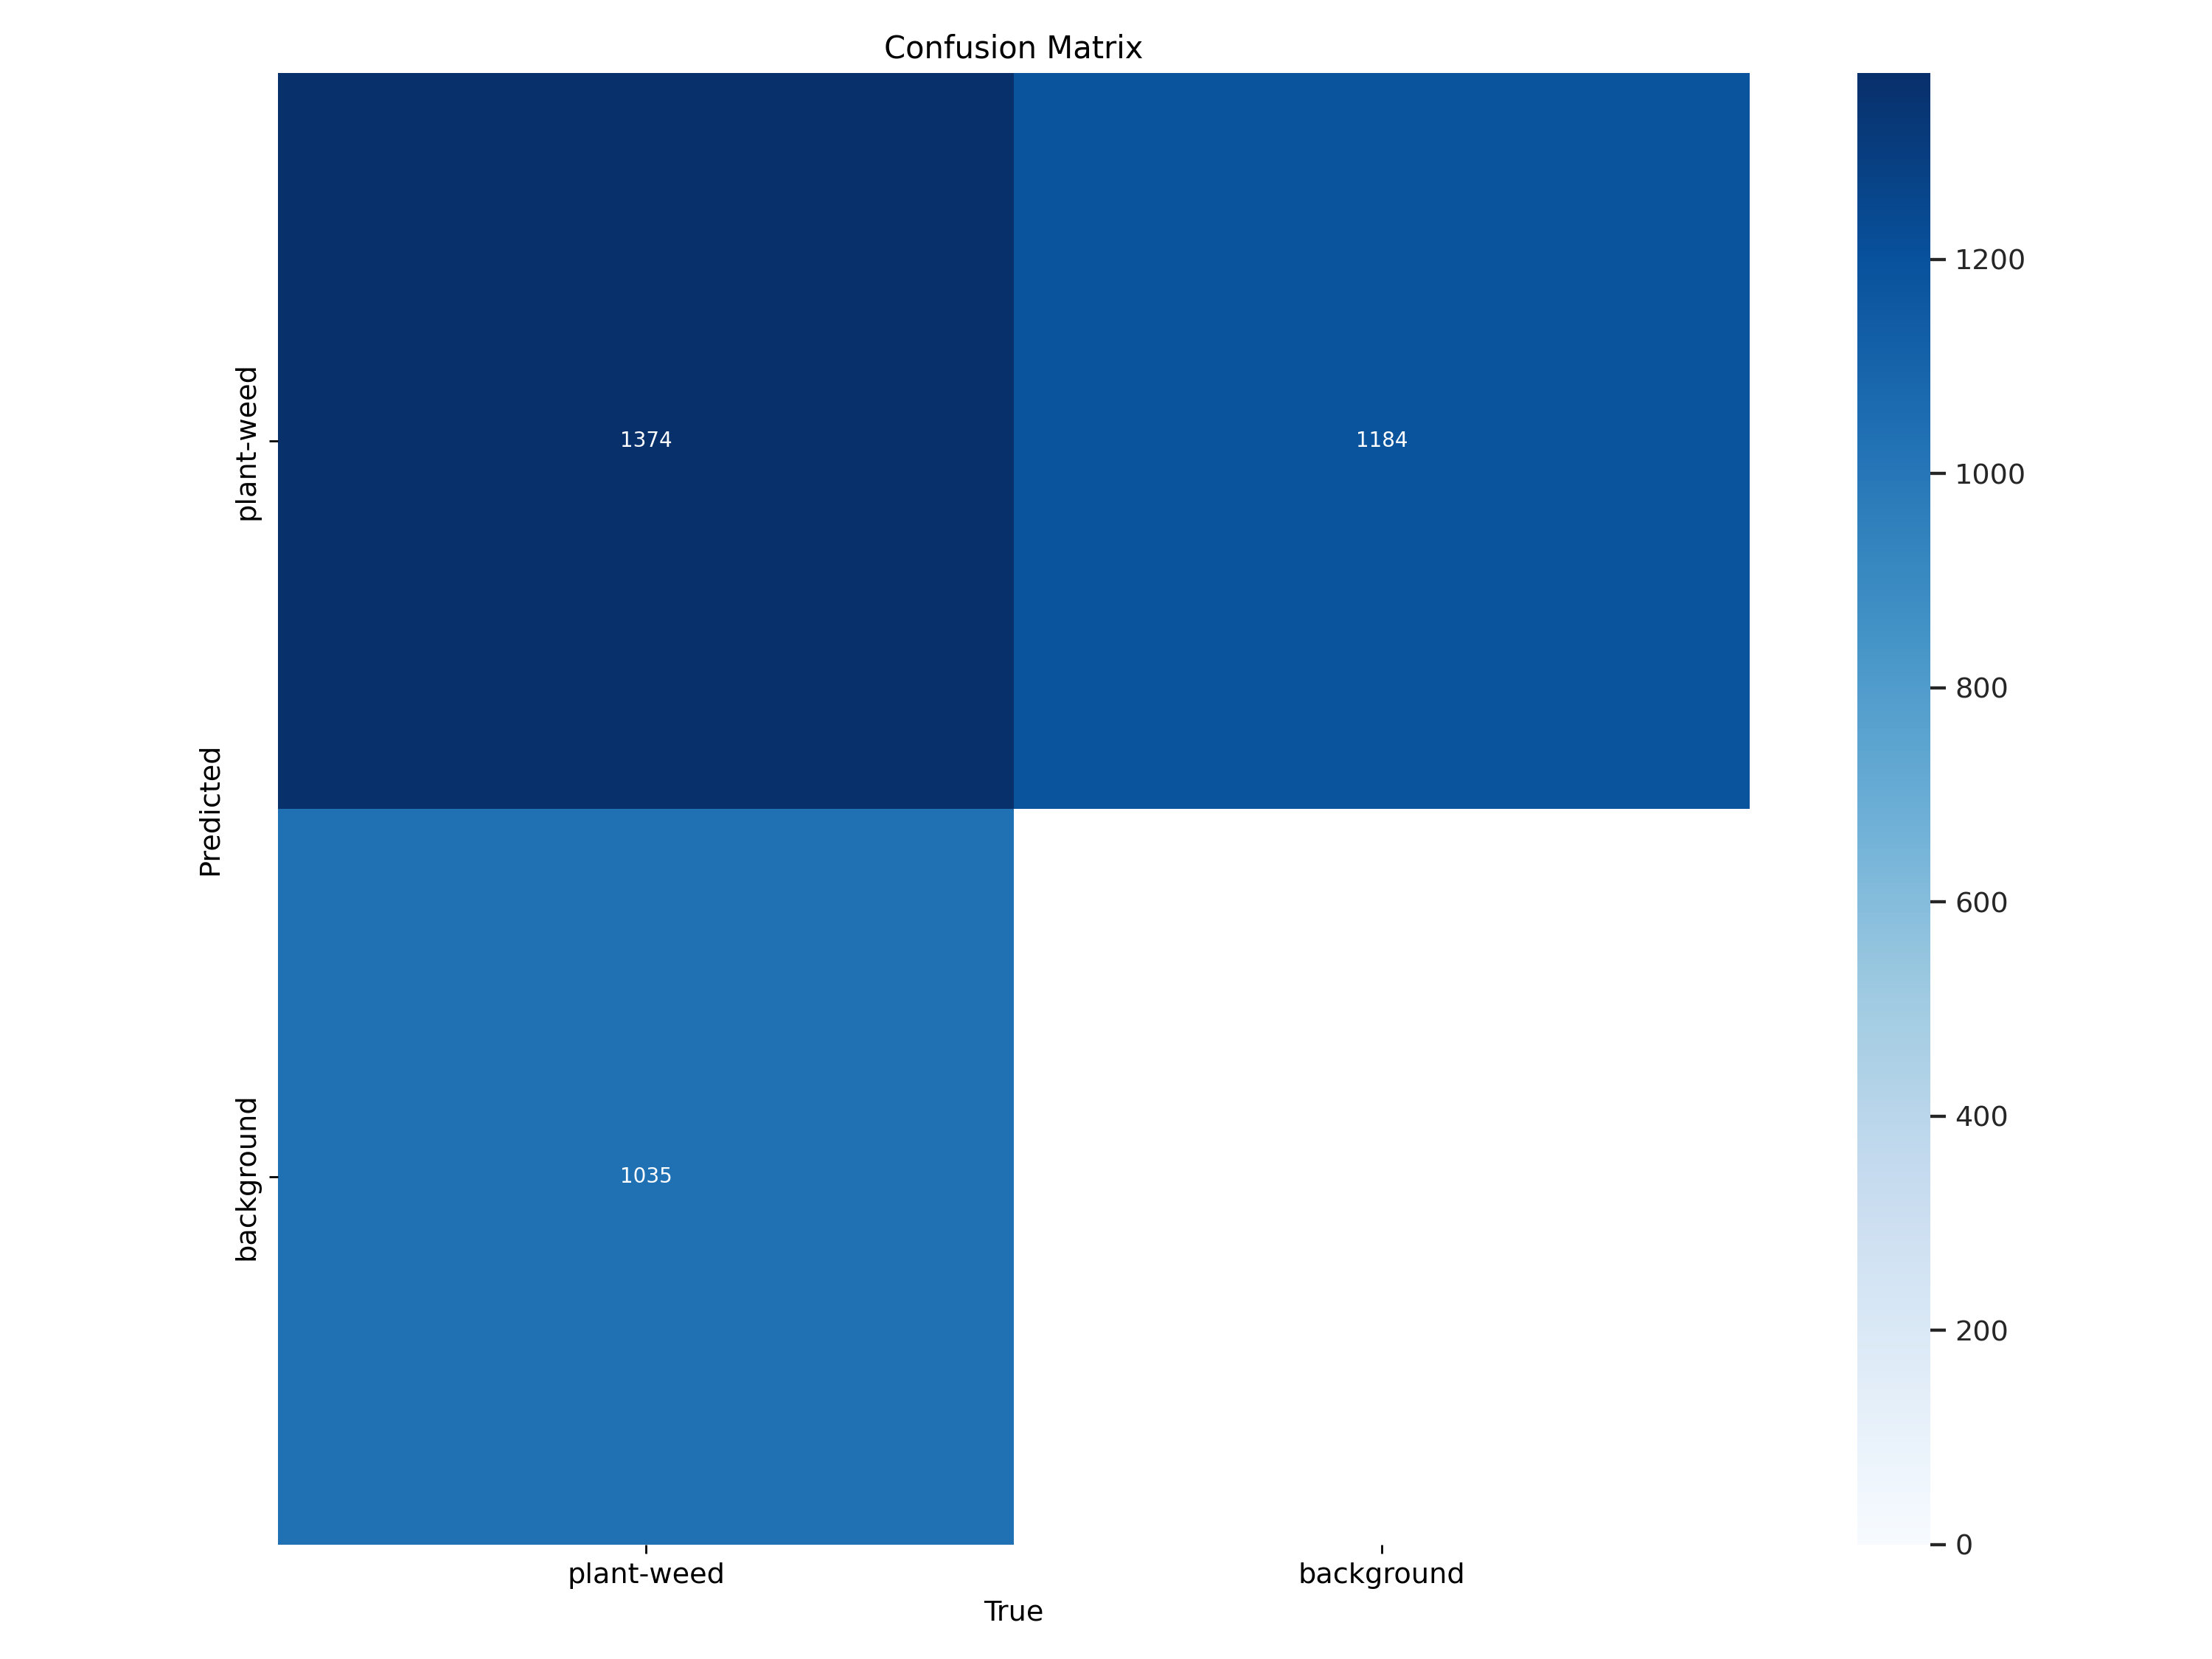

In [197]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

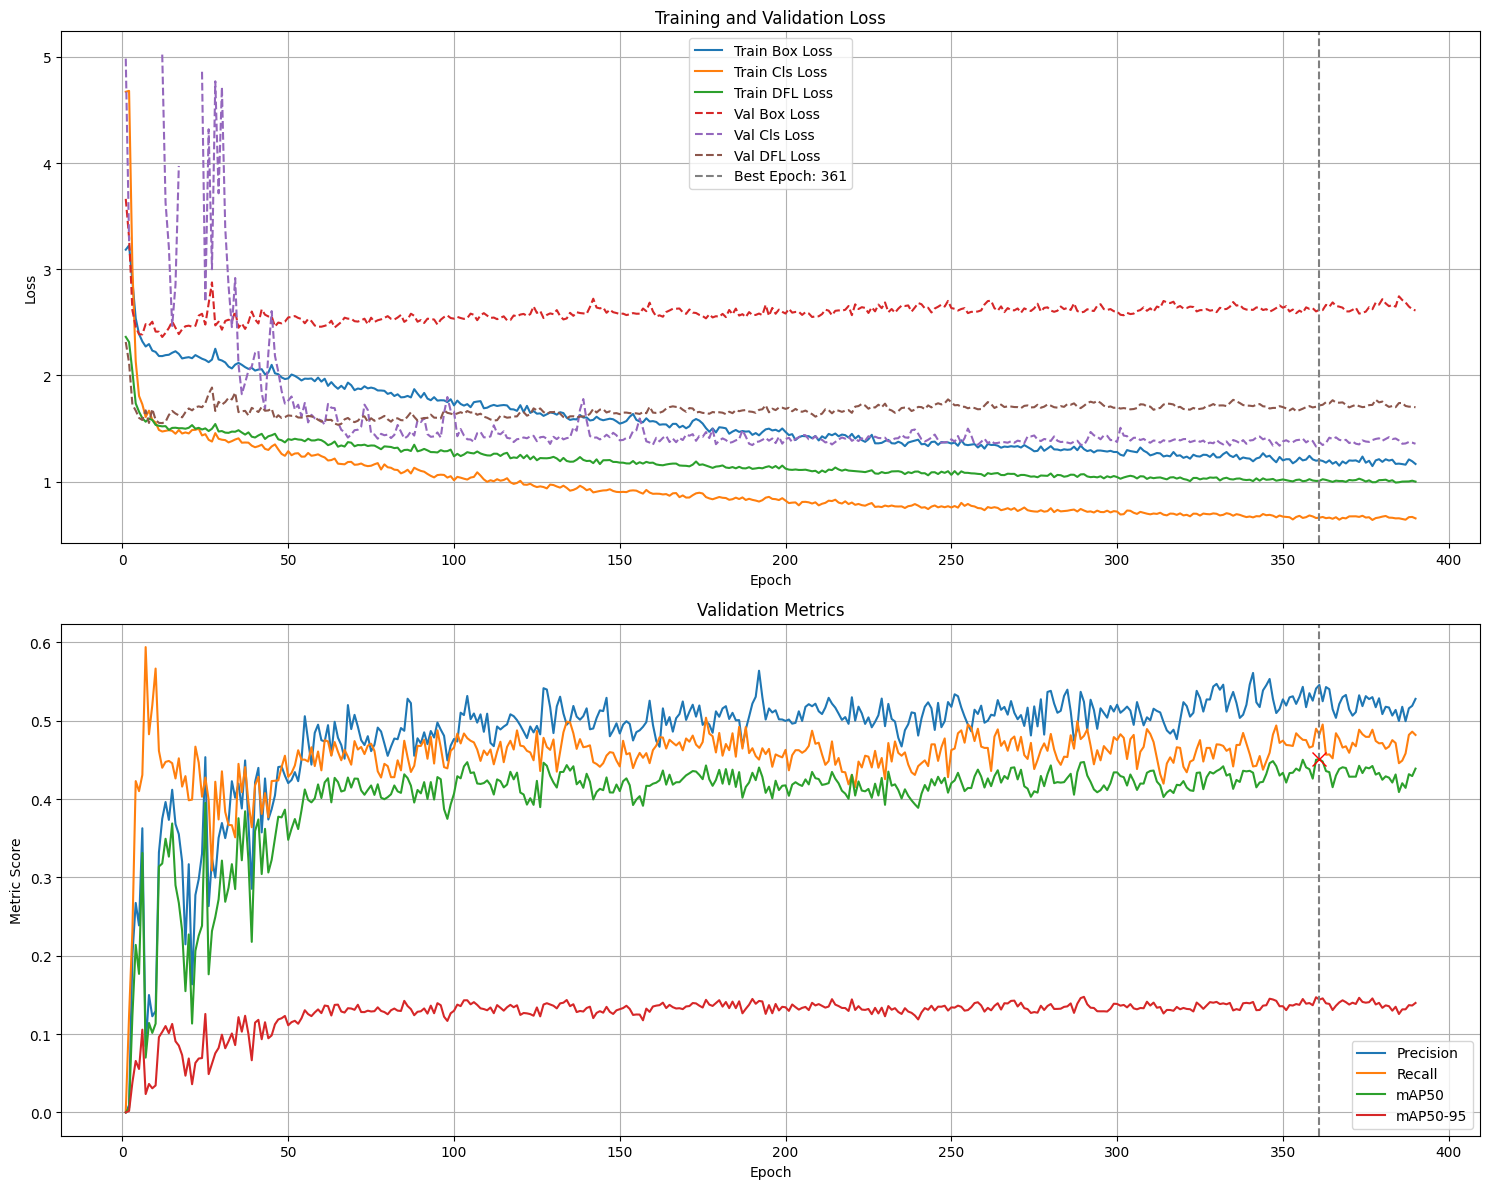

In [198]:
graph_training_metrics(df1, epoch, graph="full")


_**NOTA:** `patience`=100 para EarlyStop_

In [199]:
graph_LrLoss_3D(df1)

Validation set


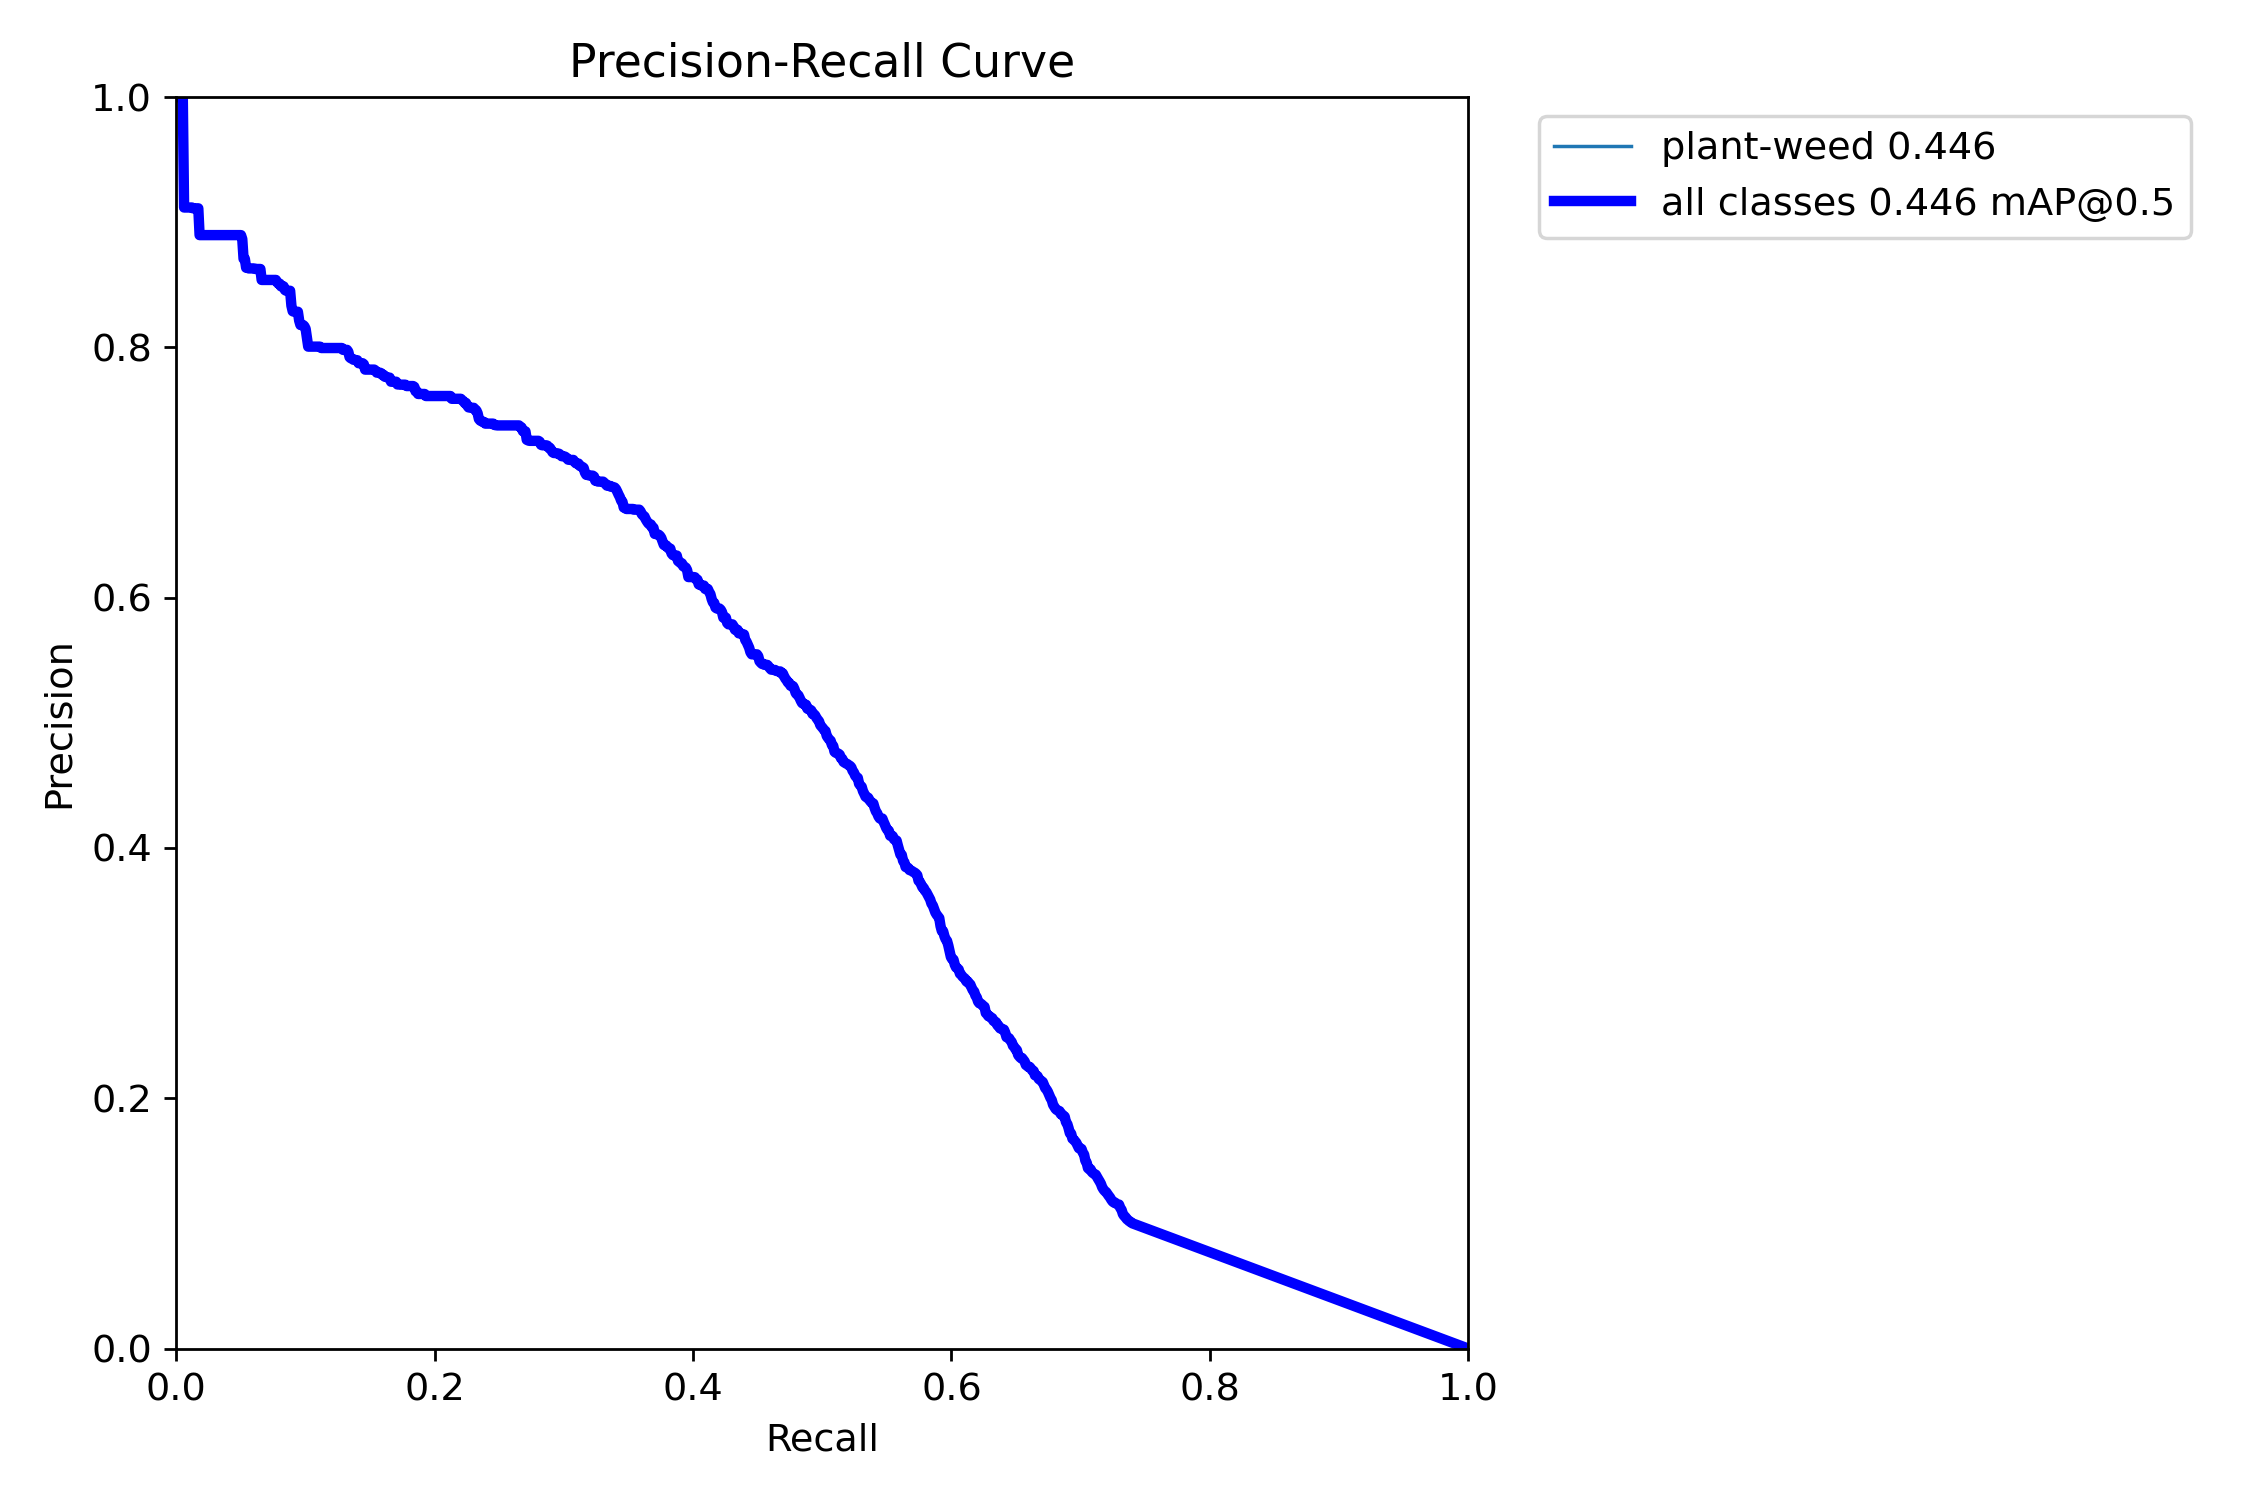

In [200]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

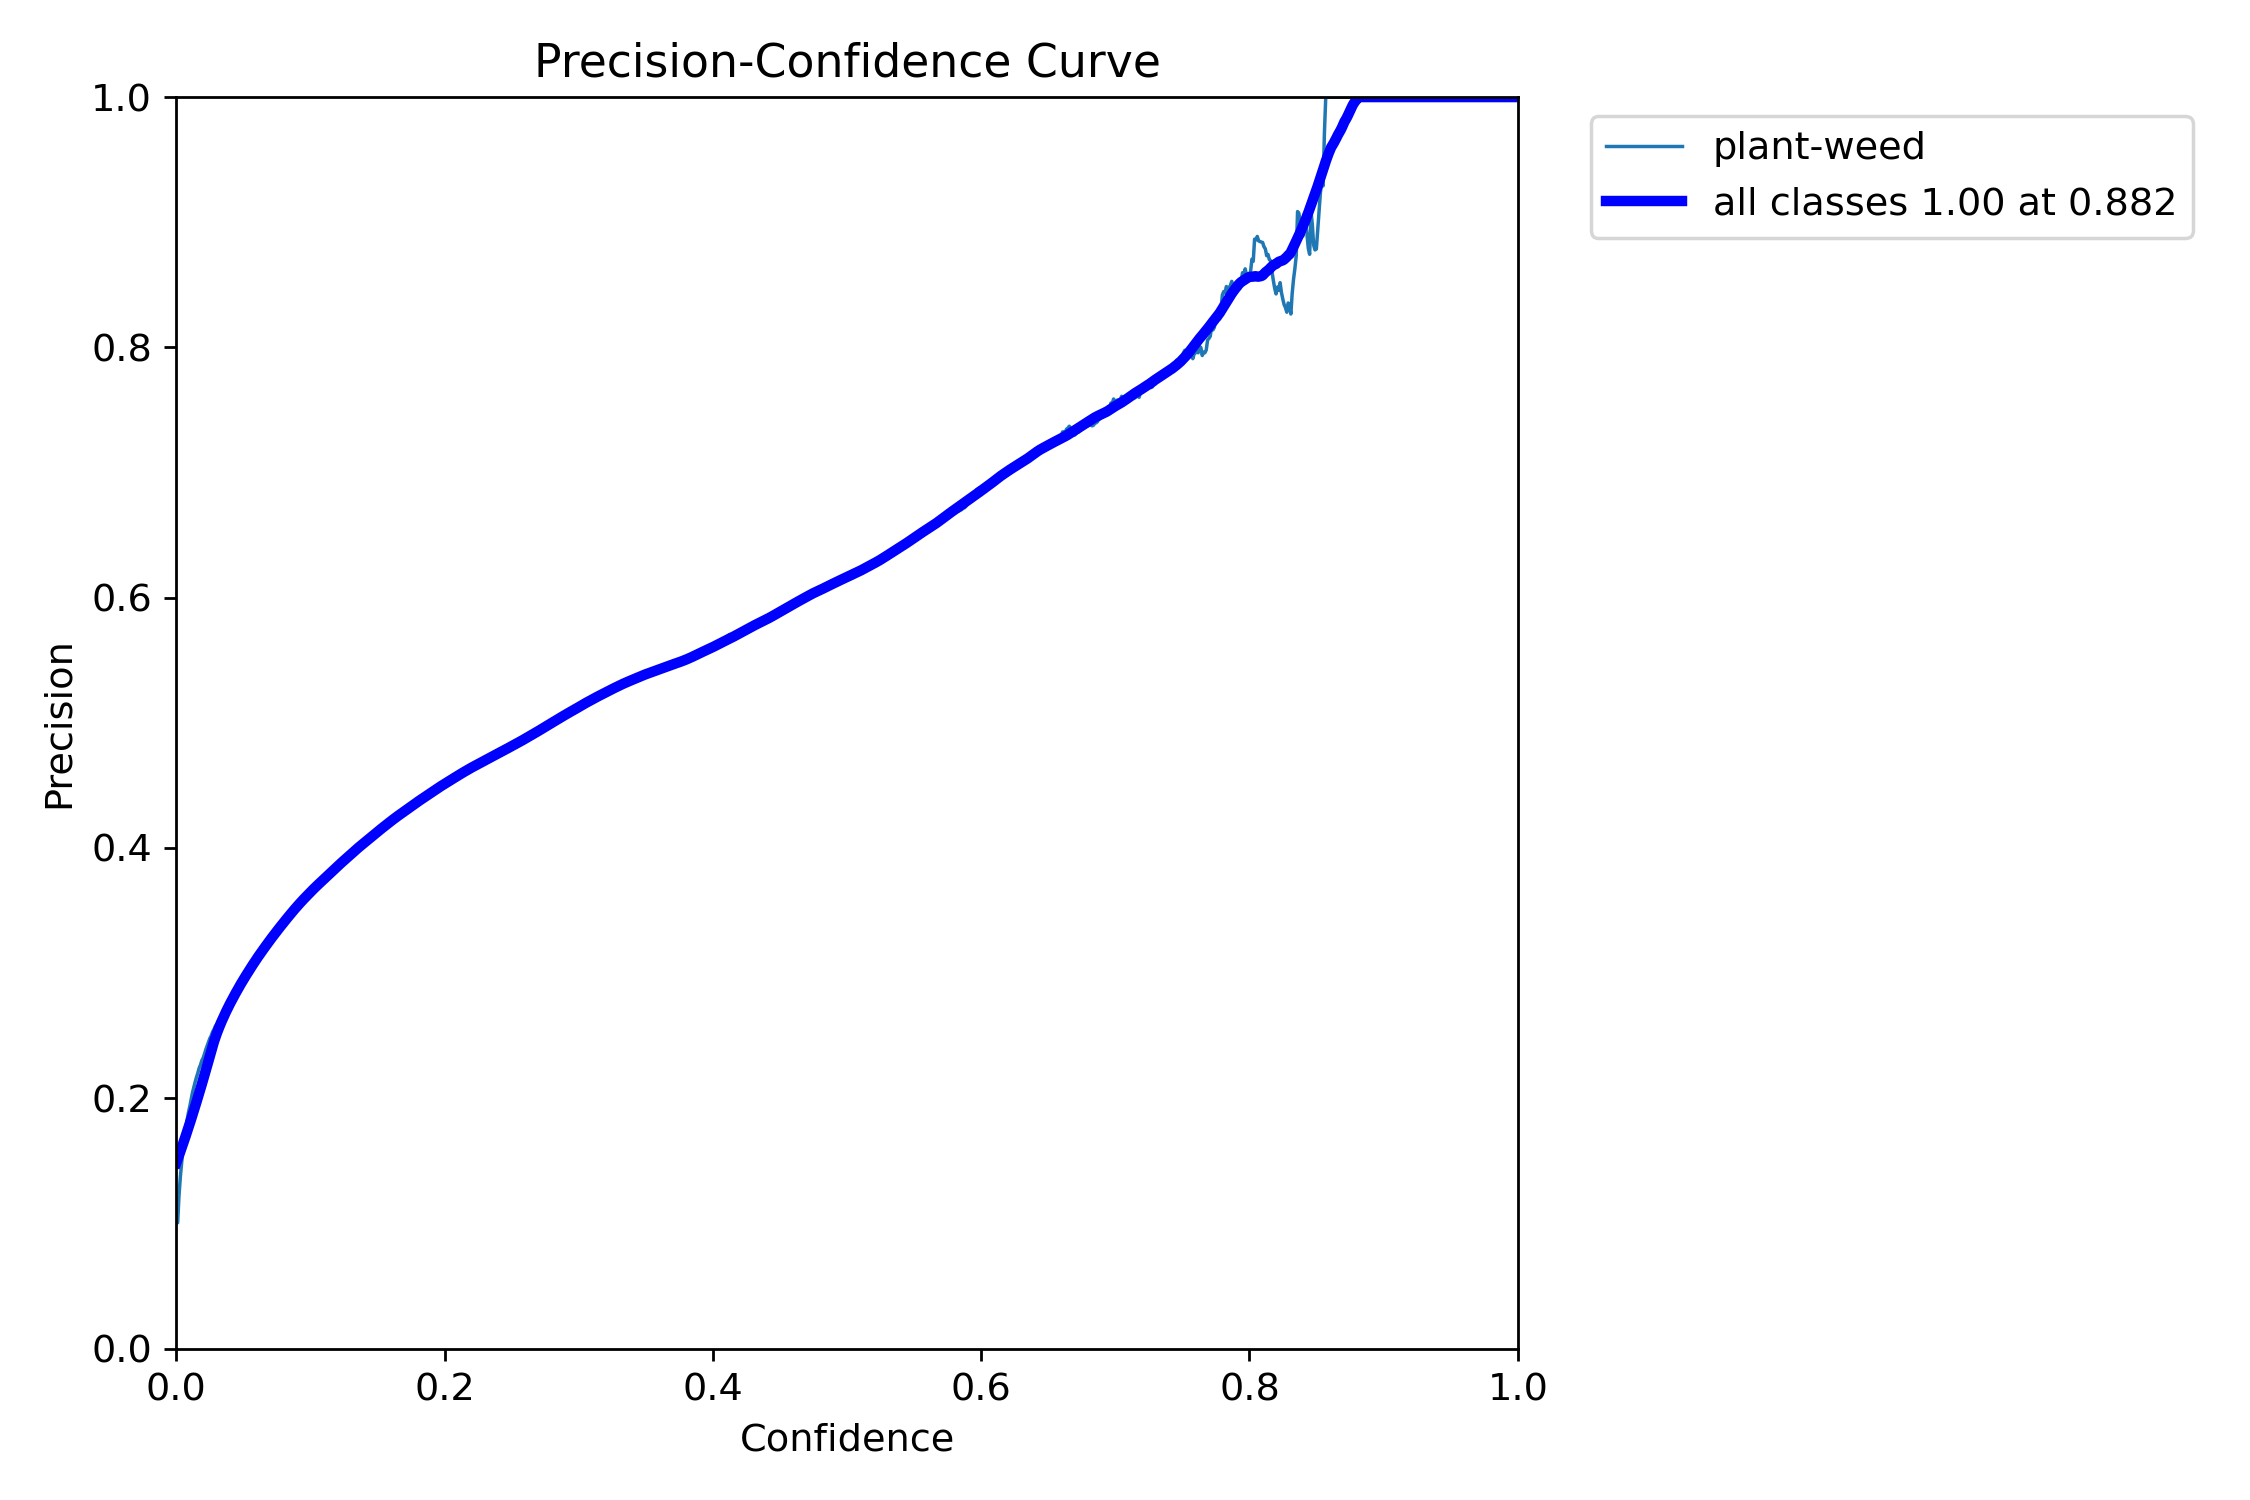

In [201]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

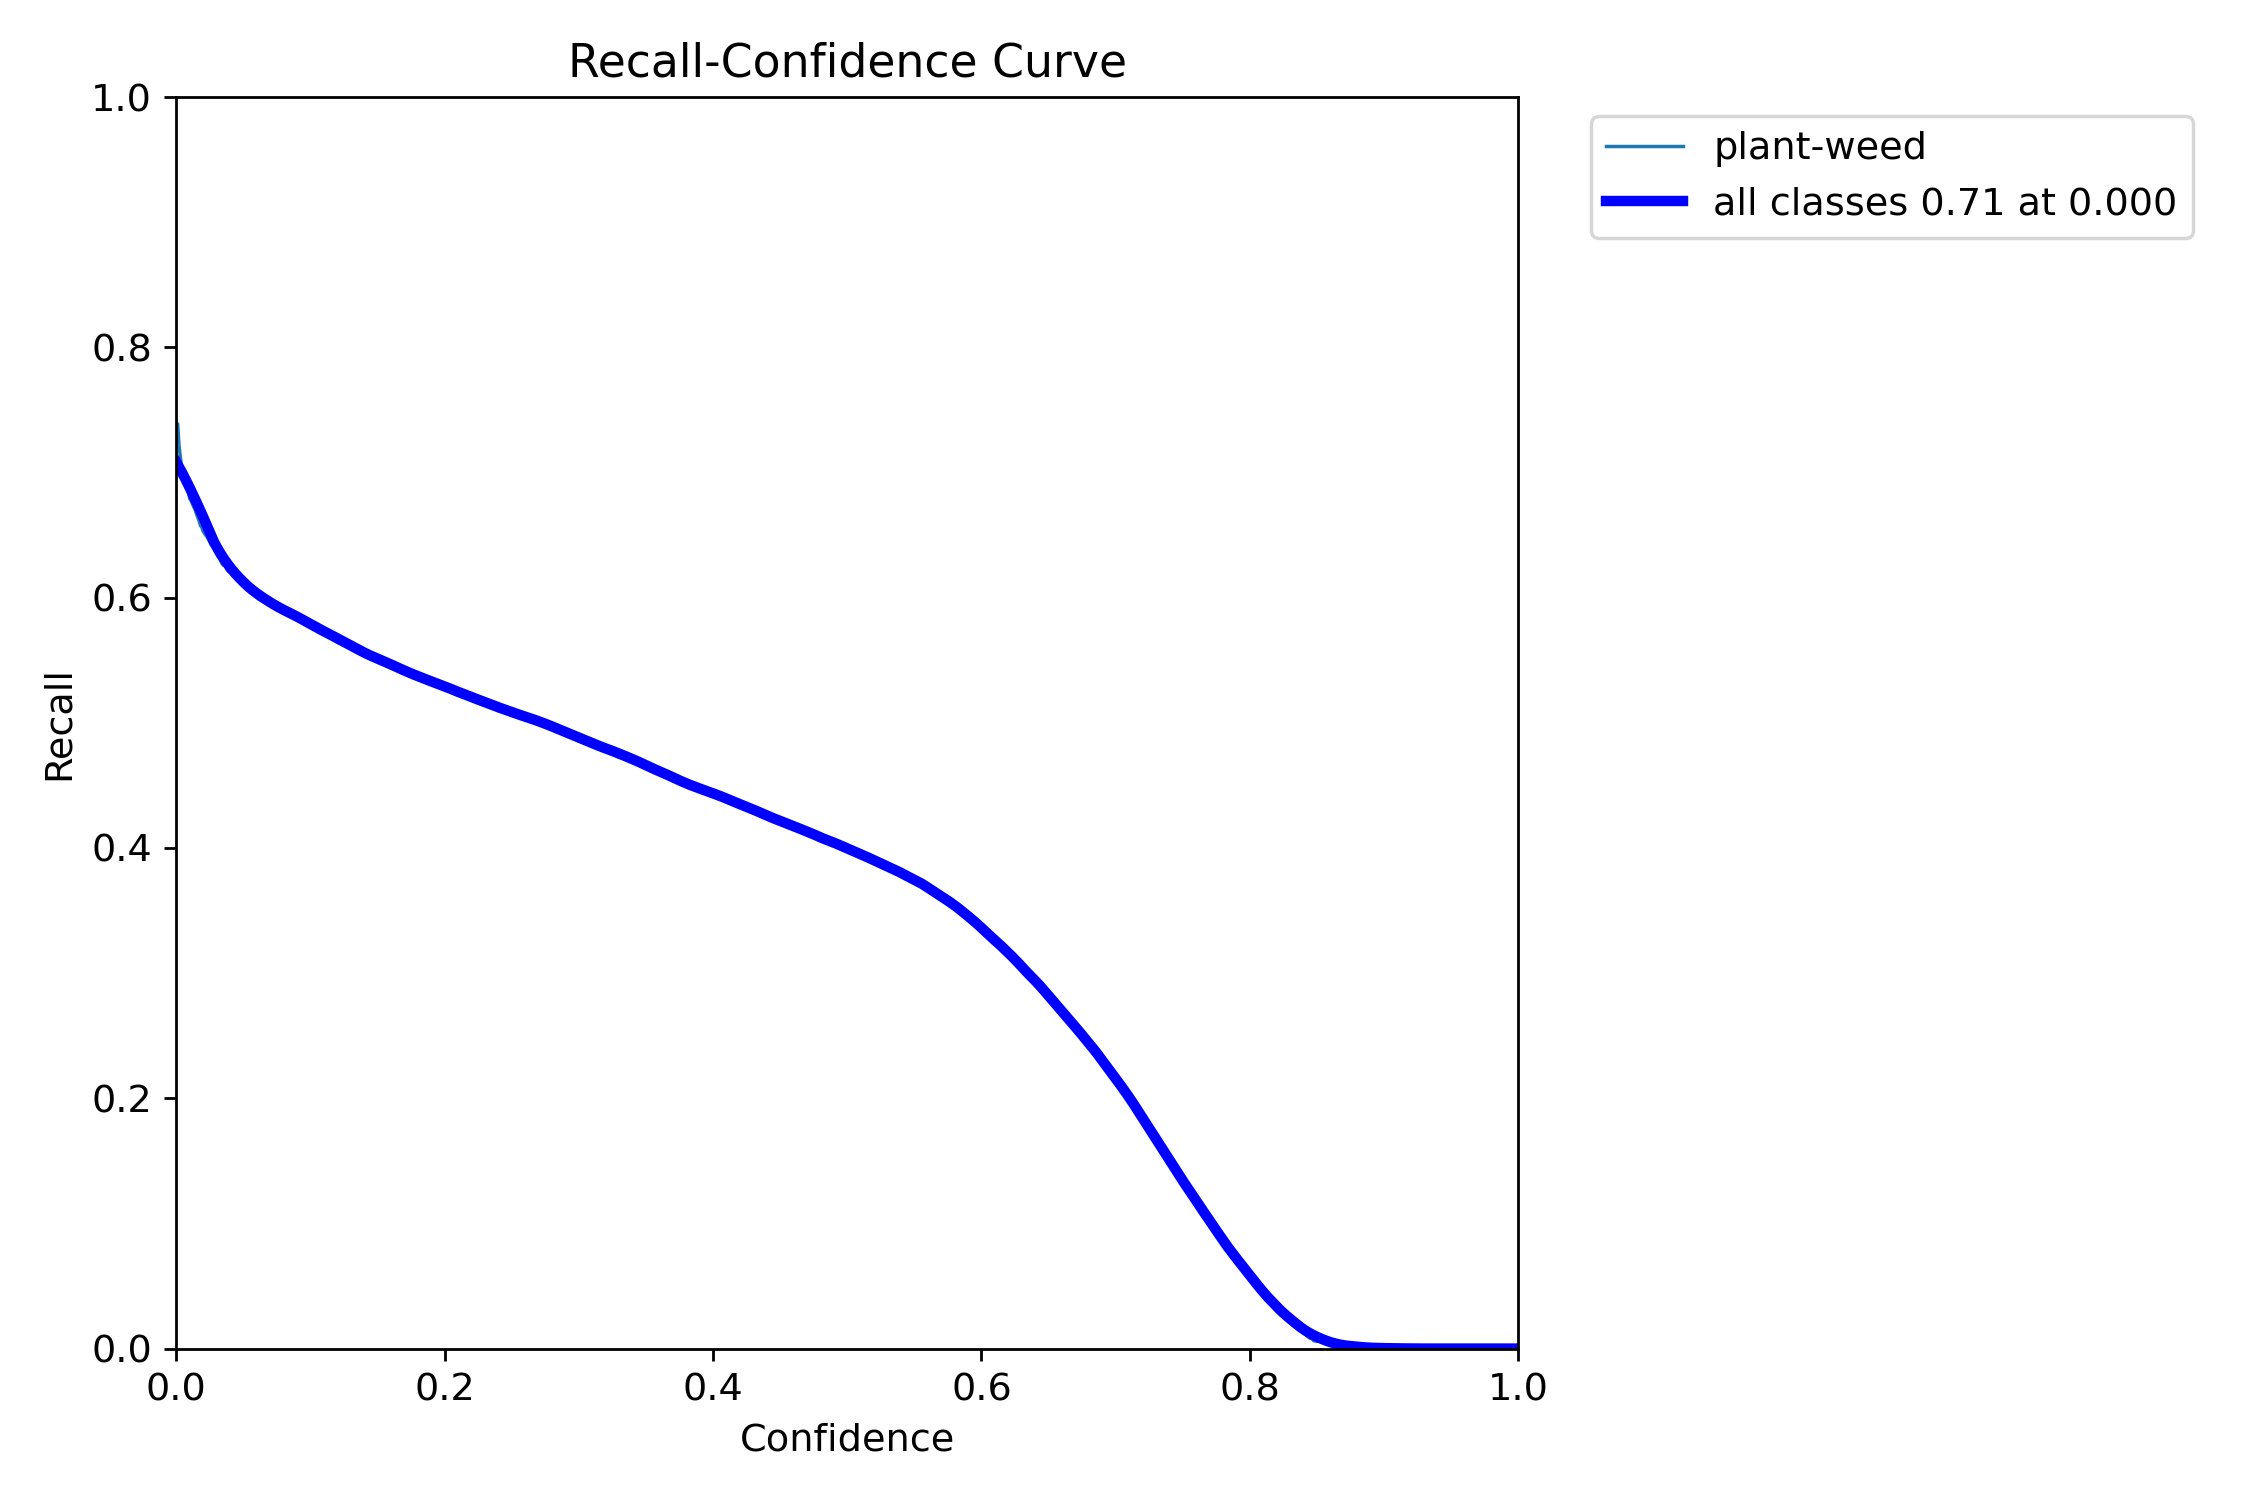

In [202]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

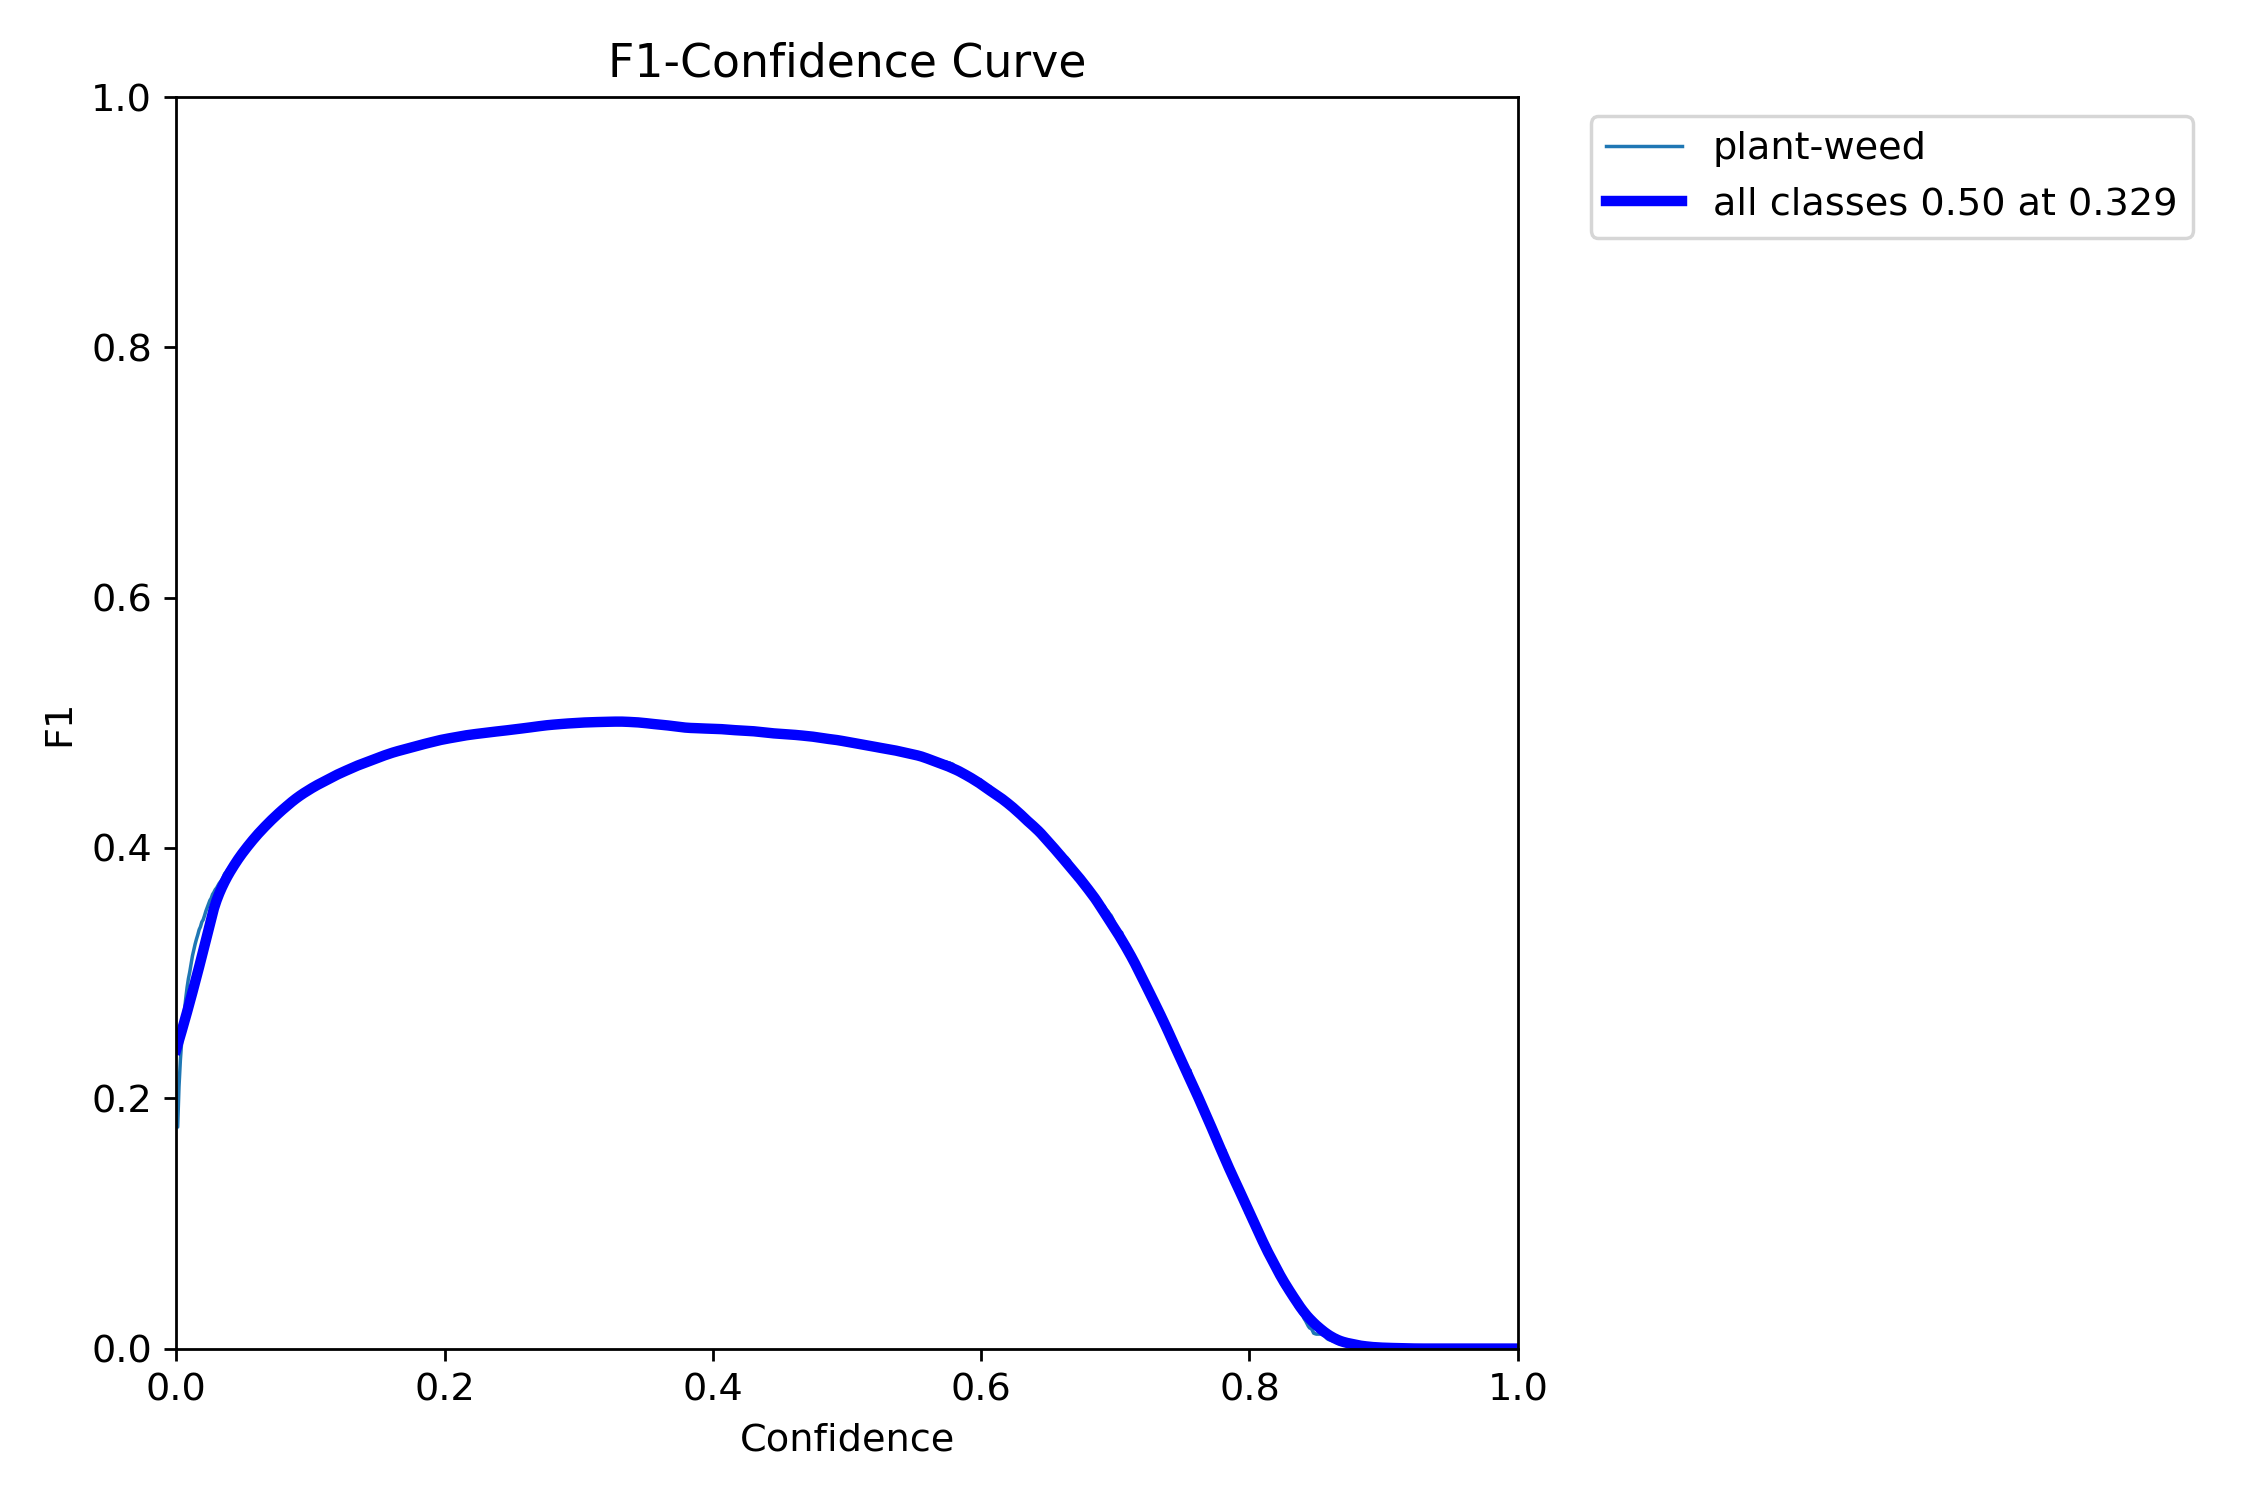

In [203]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

----

## Experiment 20
### *YOLO V9 | ~1000 epochs*

In [204]:
folder = "v9/detect/train/"

In [205]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df2 = pd.read_csv(file_path)
df = df2.copy()
df2.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
275,276,2652.57,1.36230,0.77043,1.13718,0.51962,0.48568,0.44688,0.14151,2.60532,1.35957,1.75478,0.001455,0.001455,0.001455
276,277,2661.96,1.41064,0.78704,1.15507,0.54486,0.47489,0.45059,0.14392,2.58367,1.37286,1.75135,0.001454,0.001454,0.001454
277,278,2671.36,1.37741,0.78361,1.16482,0.53568,0.48226,0.45002,0.14208,2.55998,1.39303,1.73647,0.001452,0.001452,0.001452
278,279,2681.01,1.40532,0.77978,1.16012,0.51915,0.48443,0.43785,0.13899,2.56374,1.45537,1.73497,0.001450,0.001450,0.001450
279,280,2690.19,1.42537,0.80560,1.19271,0.53269,0.47613,0.44176,0.14284,2.56922,1.37045,1.73670,0.001448,0.001448,0.001448


In [206]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 44.837 min


In [207]:
df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
179,180,1745.52,1.57606,0.91356,1.24885,0.54504,0.48734,0.46271,0.15455,2.50628,1.3525,1.67852,0.001646,0.001646,0.001646


#### Best epoch

In [208]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
179,180,1745.52,1.57606,0.91356,1.24885,0.54504,0.48734,0.46271,0.15455,2.50628,1.3525,1.67852,0.001646,0.001646,0.001646,44.8365


In [209]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 180 con mAP50 de 0.463


In [210]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [211]:
TP = 1467
FP = 1490
FN = 942
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 3899


In [212]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.3762503205950244, 0.38214926904334445, 0.24160041036163118)

### Graphs

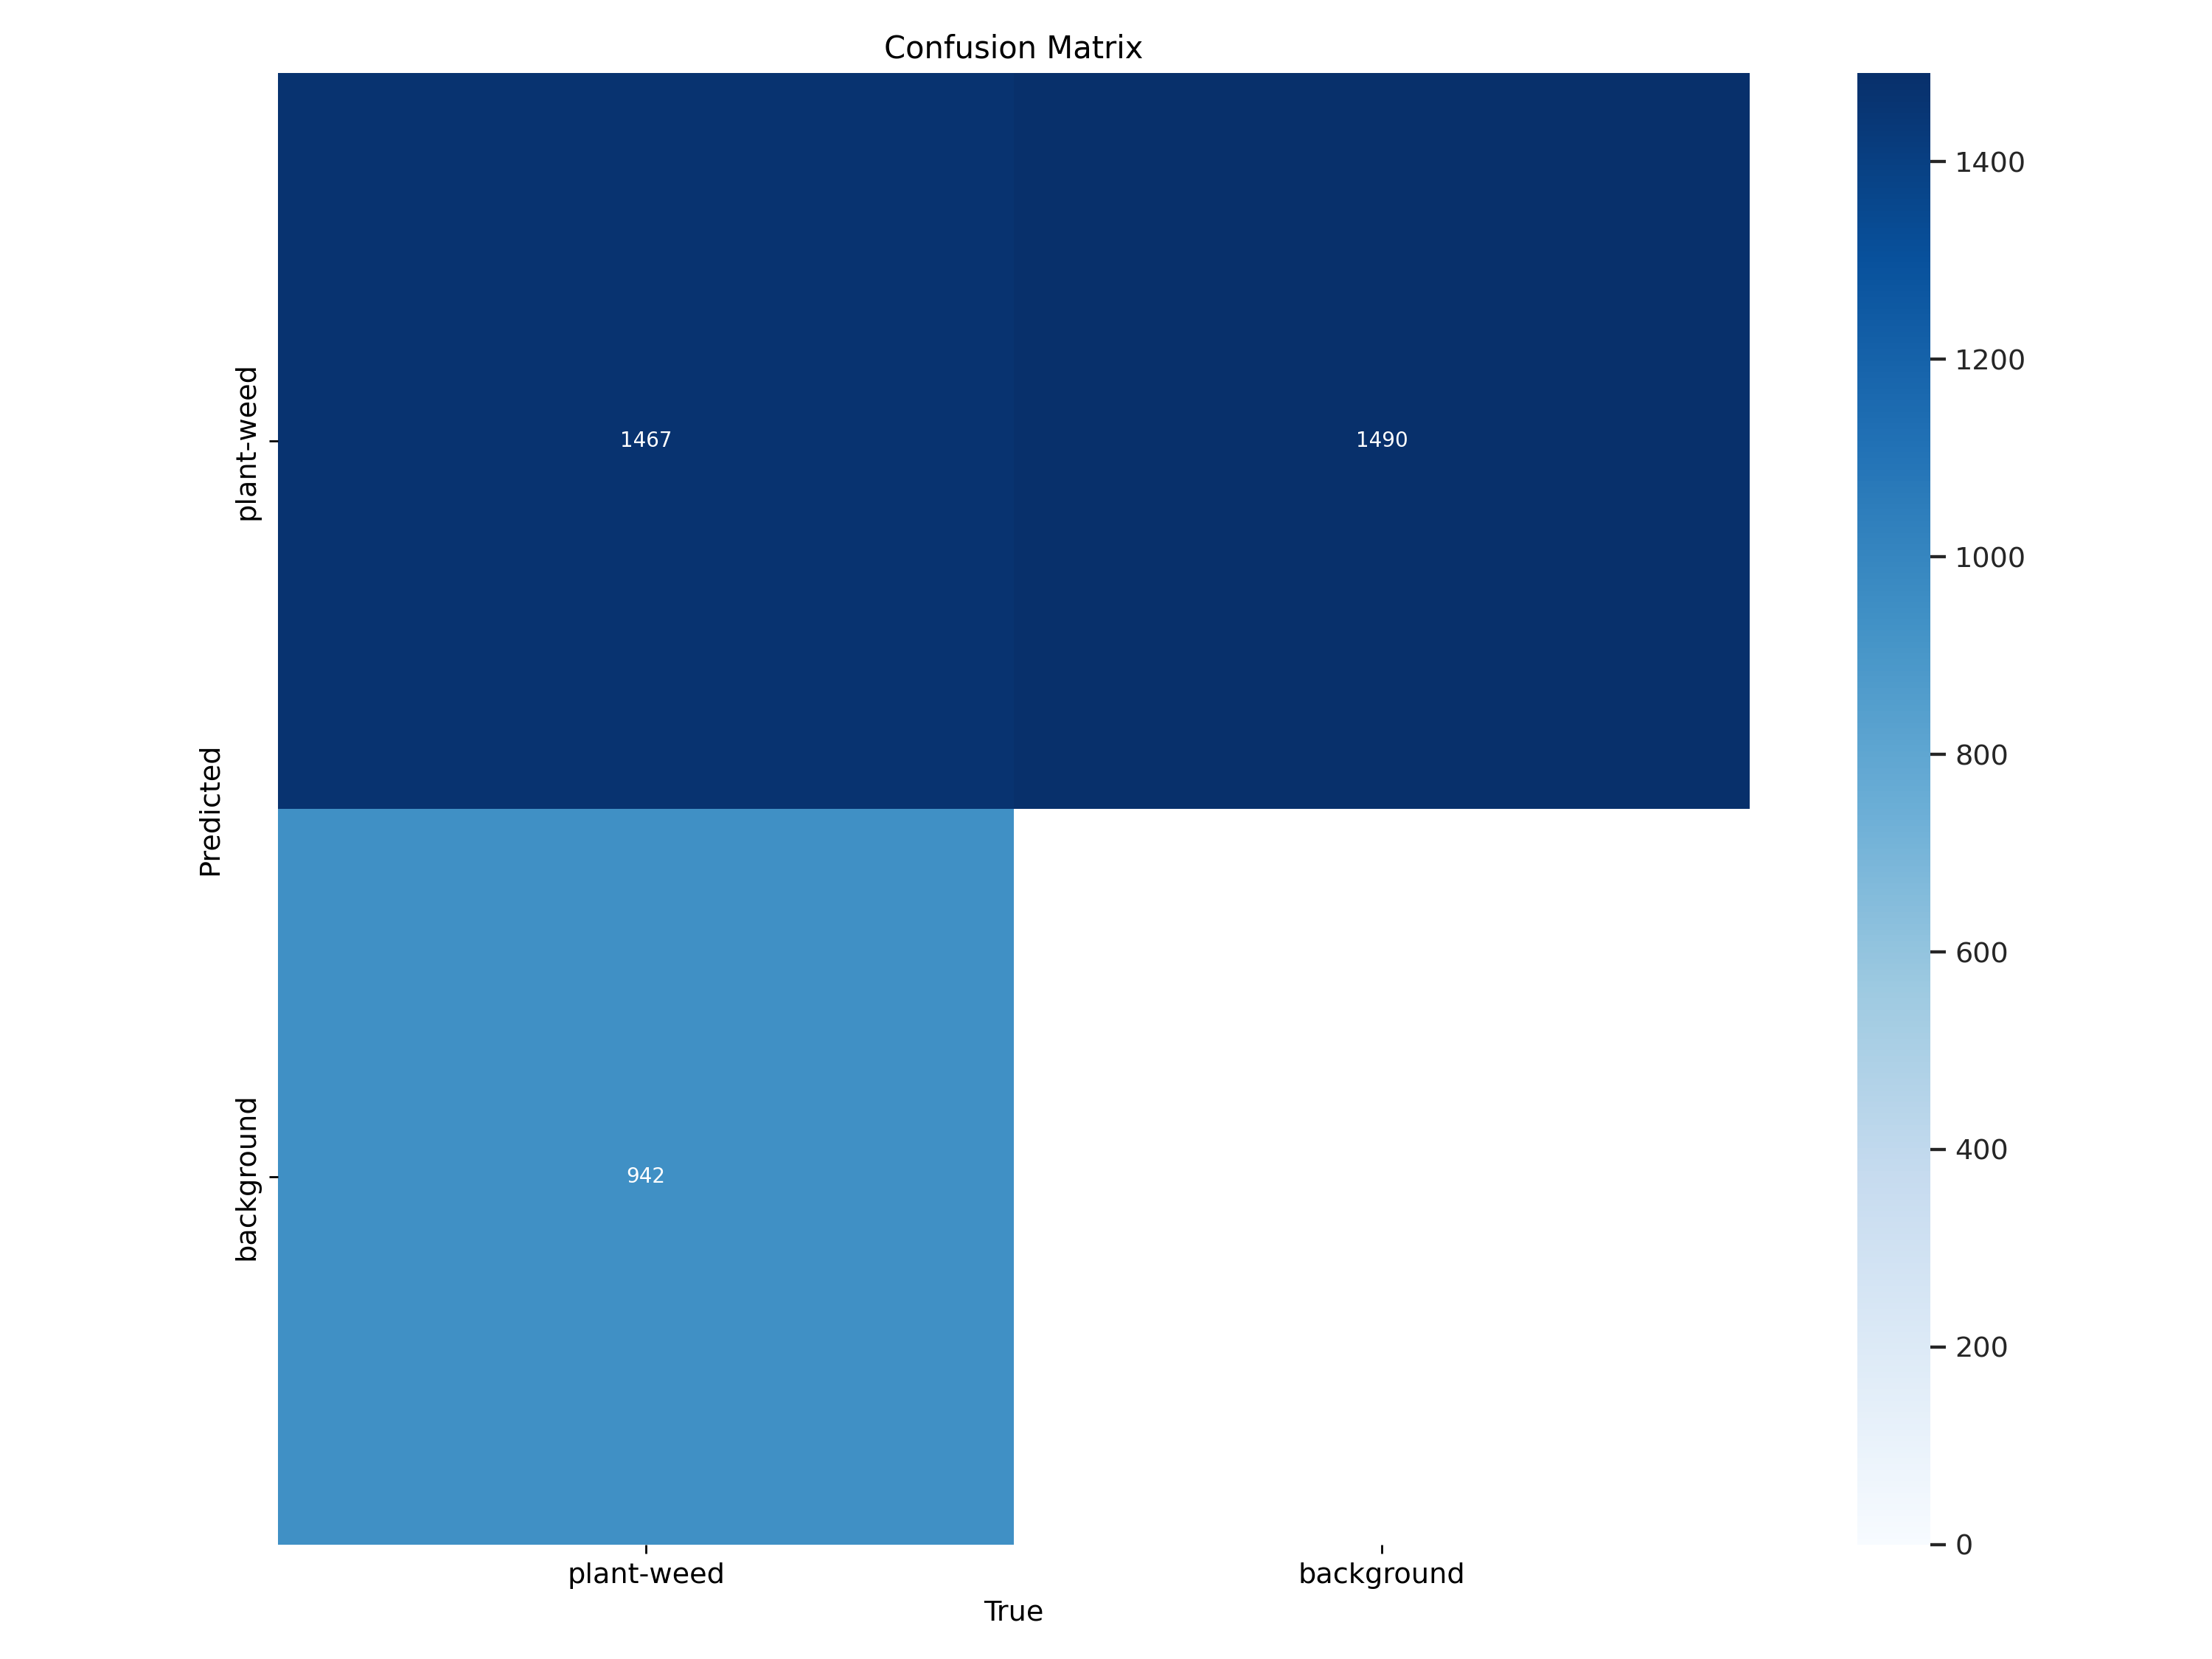

In [213]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

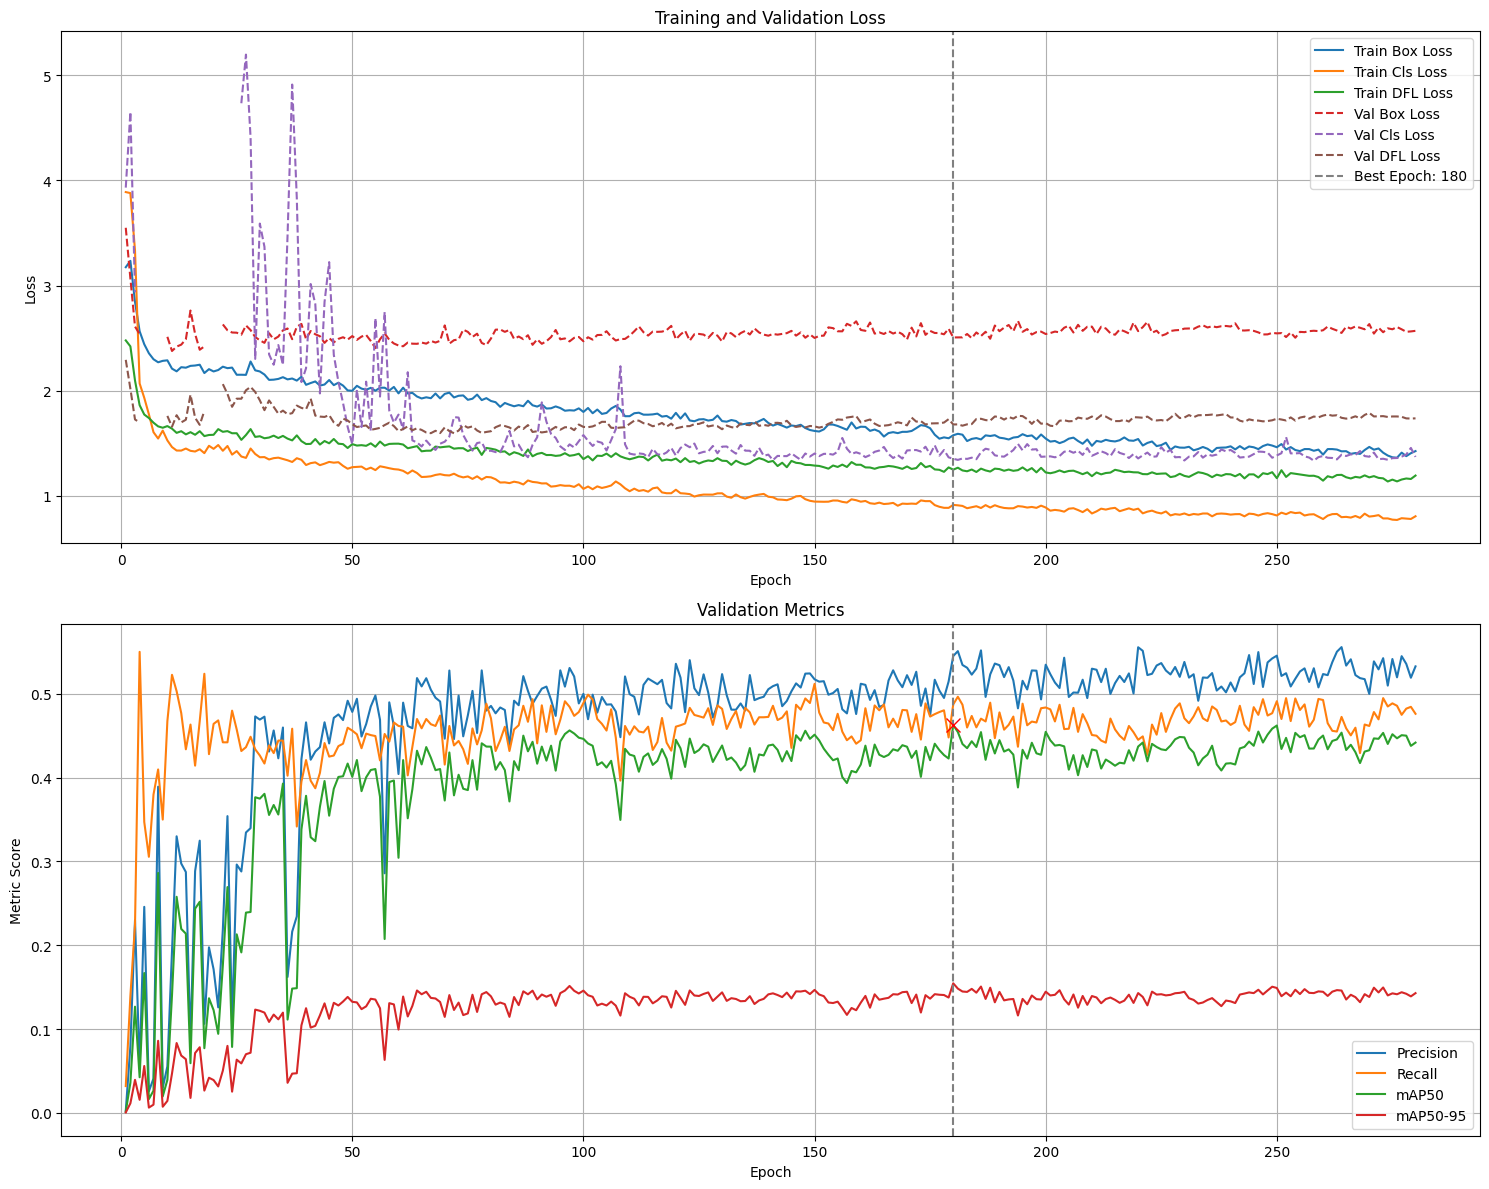

In [214]:
graph_training_metrics(df2, epoch, graph="full")


_**NOTA:** `patience`=100 para EarlyStop_

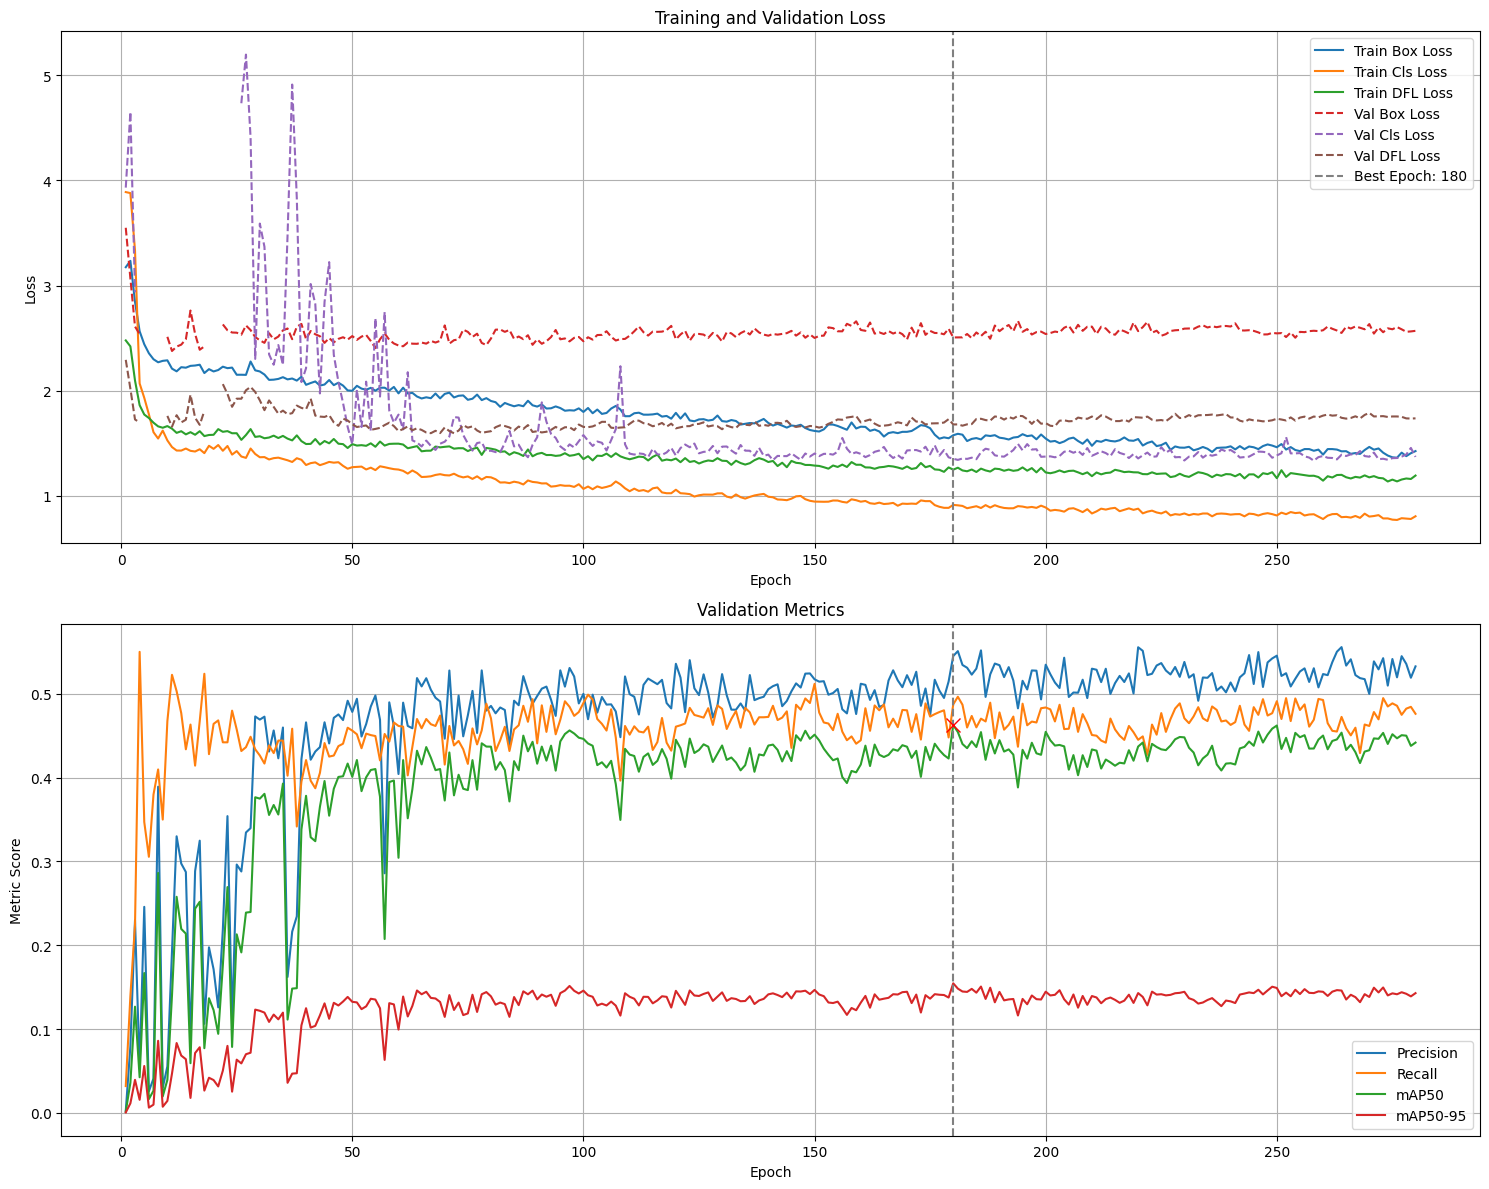

In [ ]:
graph_training_metrics(df2, epoch, graph="full")

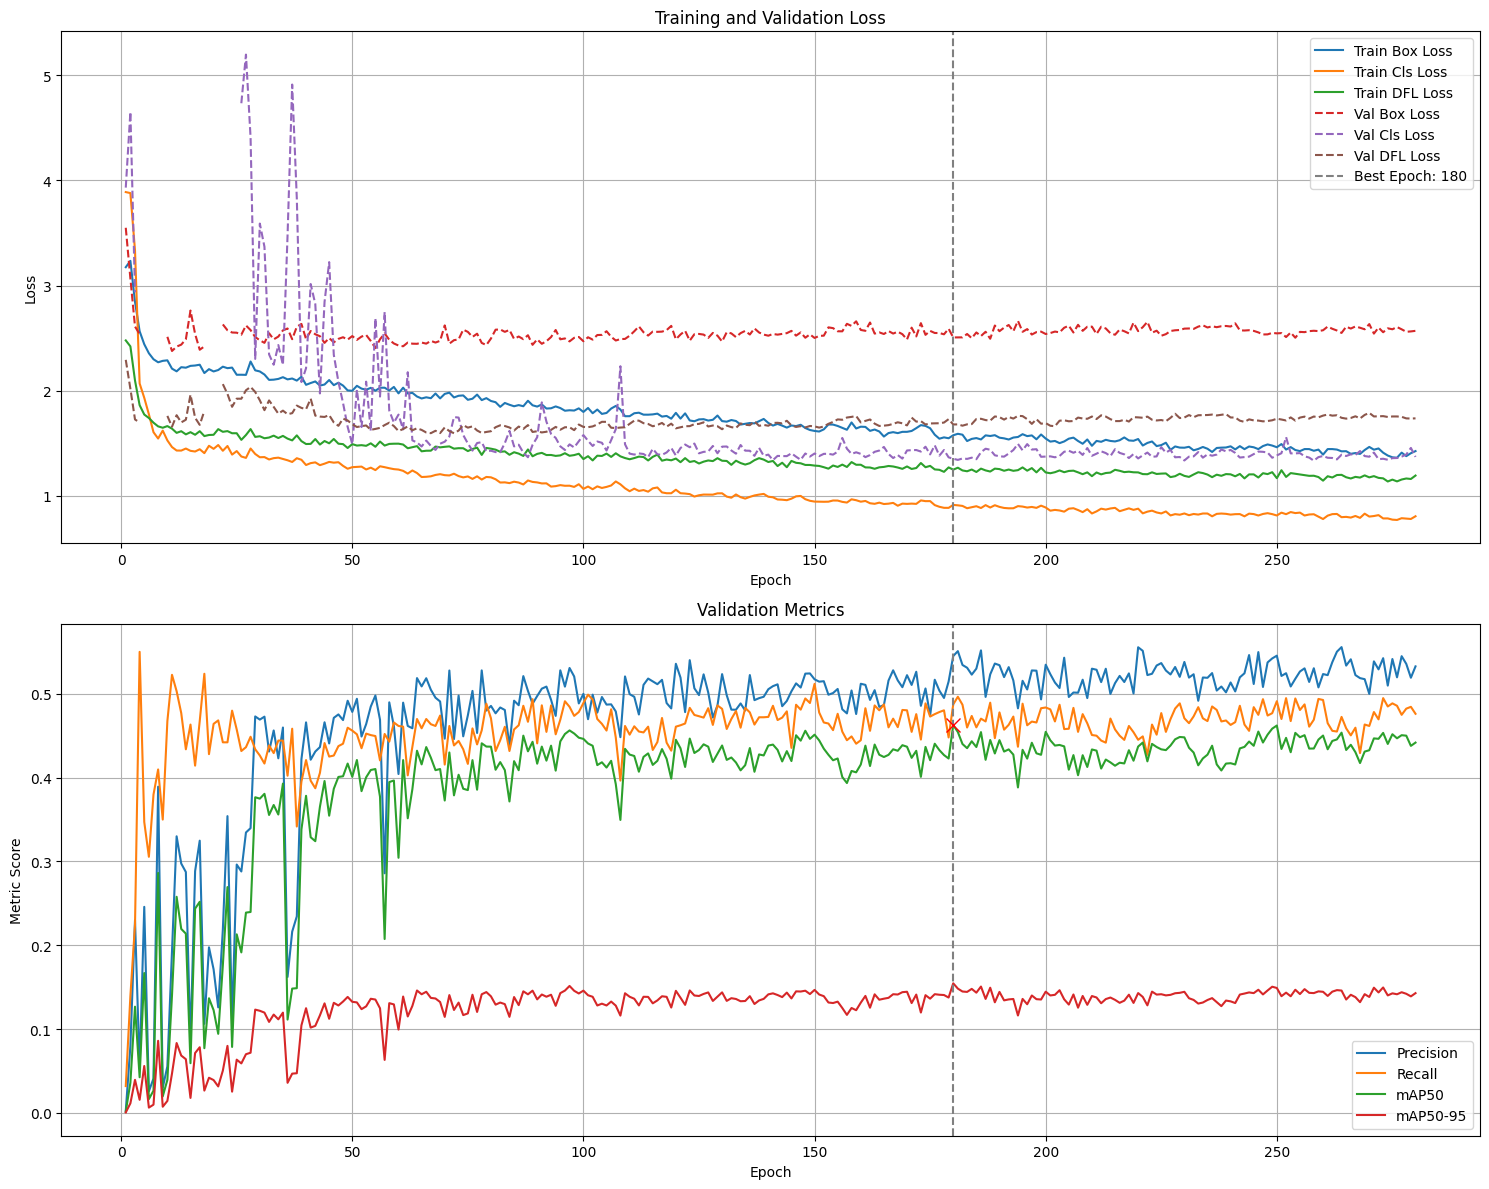

In [ ]:
graph_training_metrics(df2, epoch, graph="full")

In [215]:
graph_LrLoss_3D(df2)

Validation set


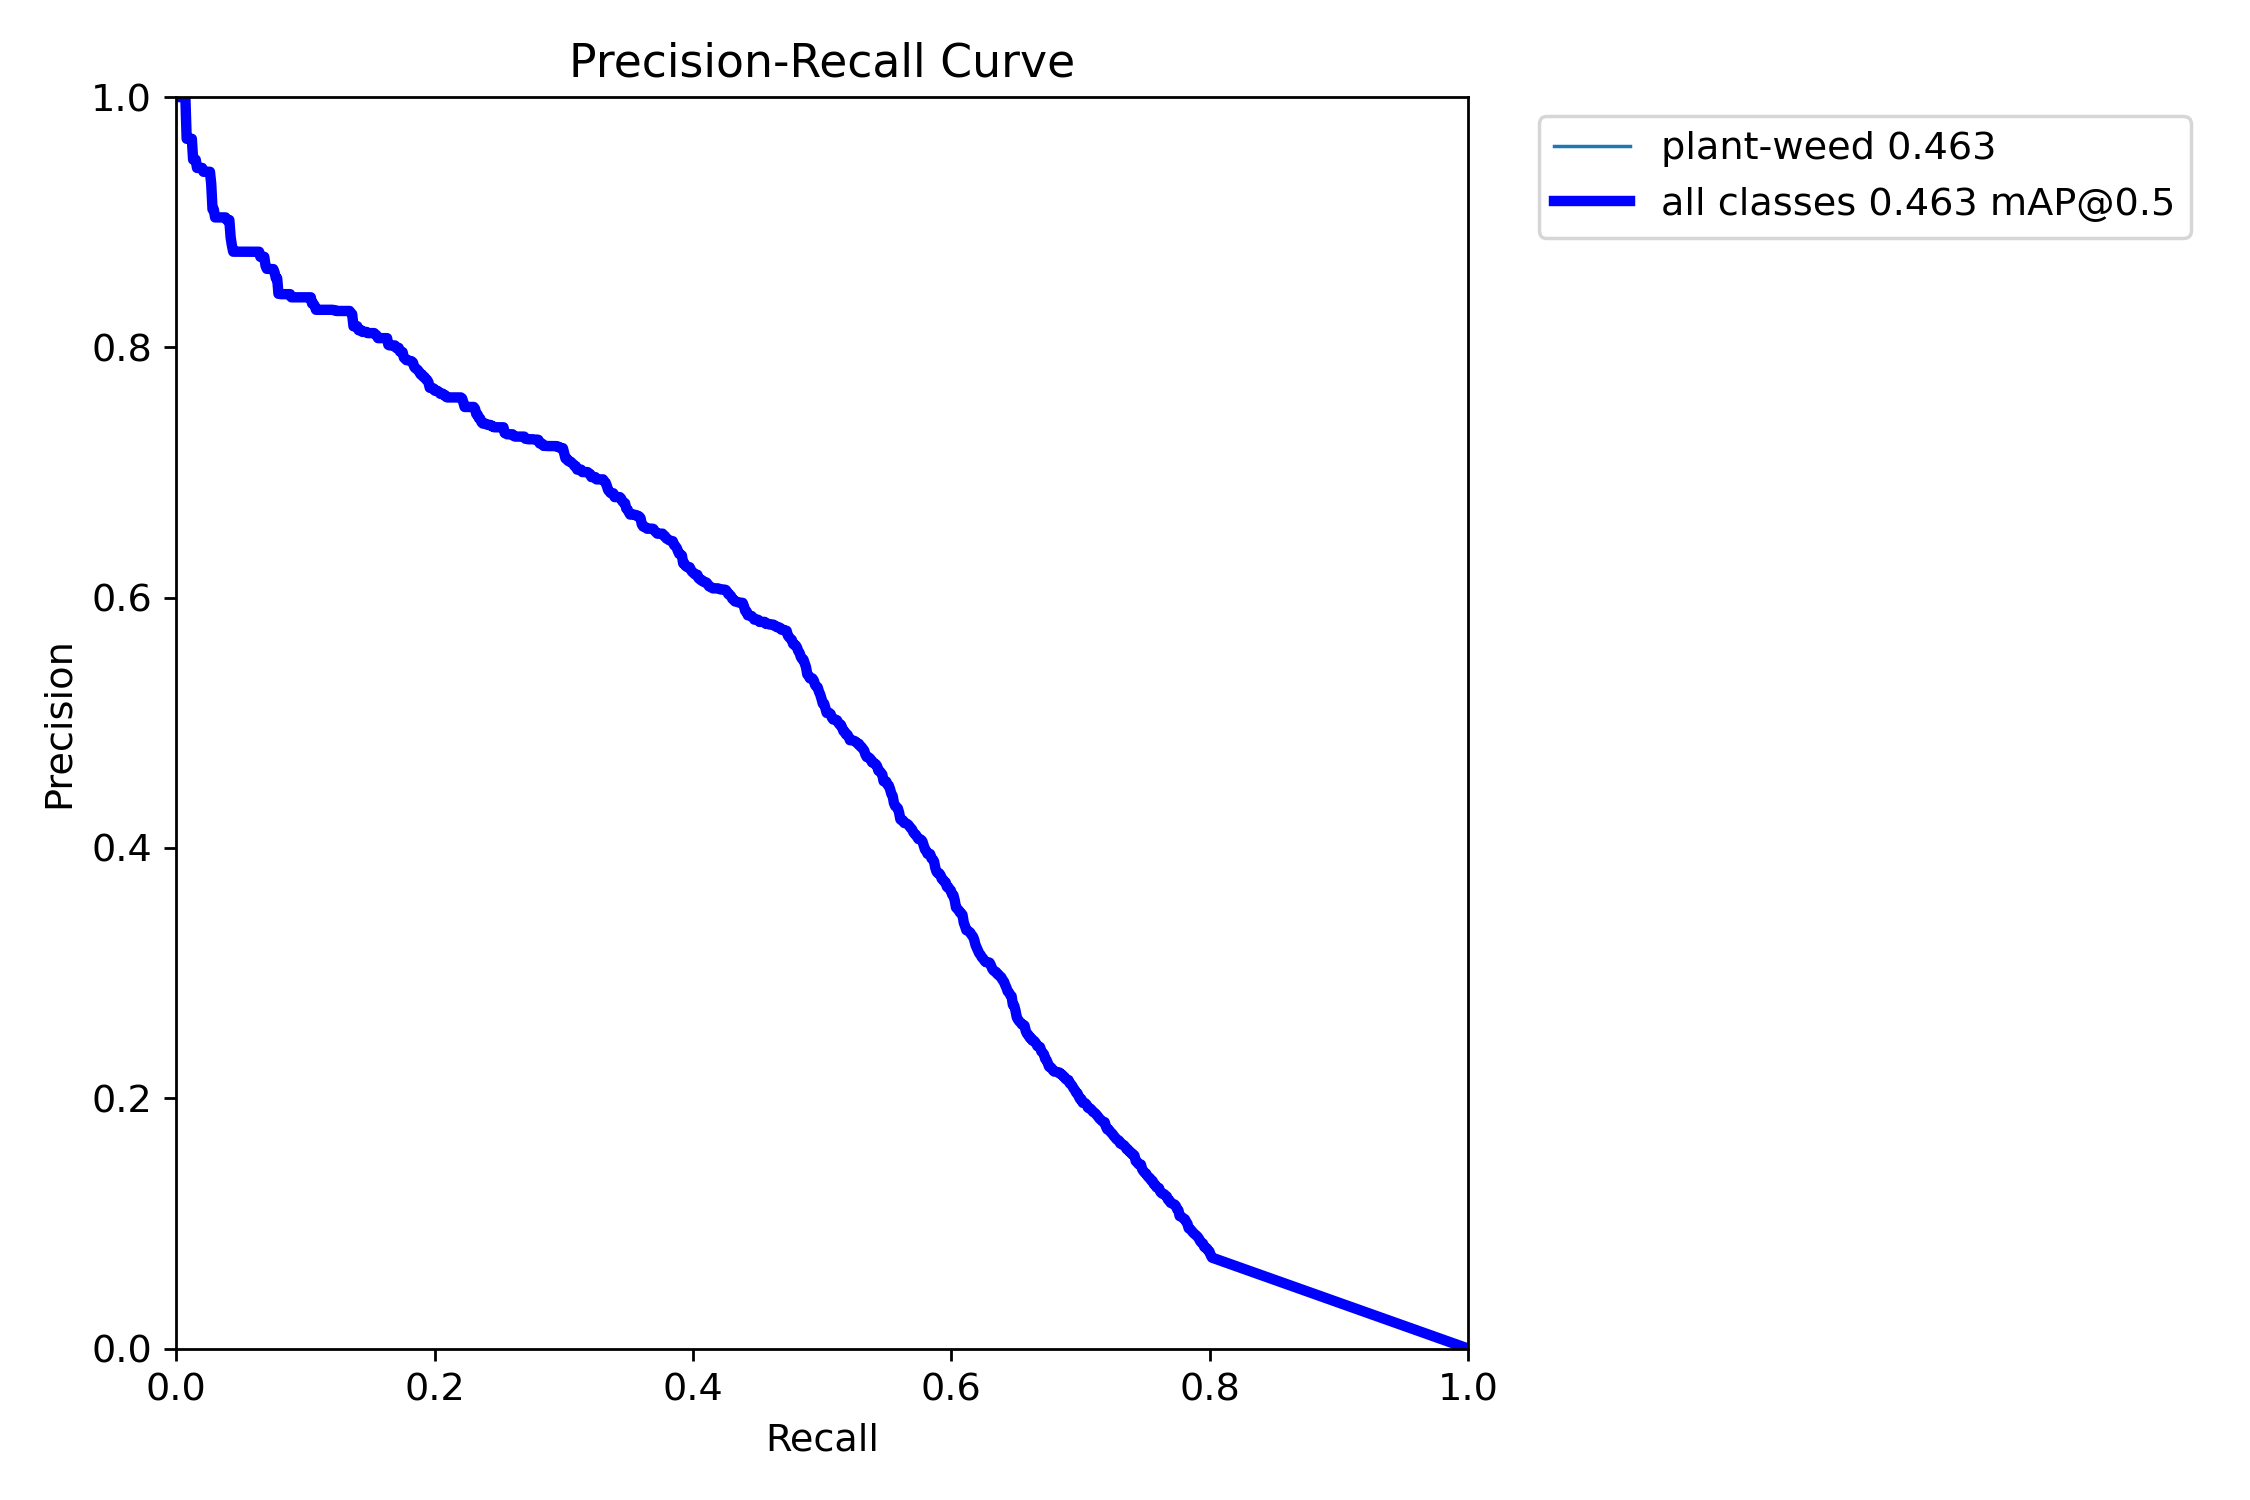

In [216]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

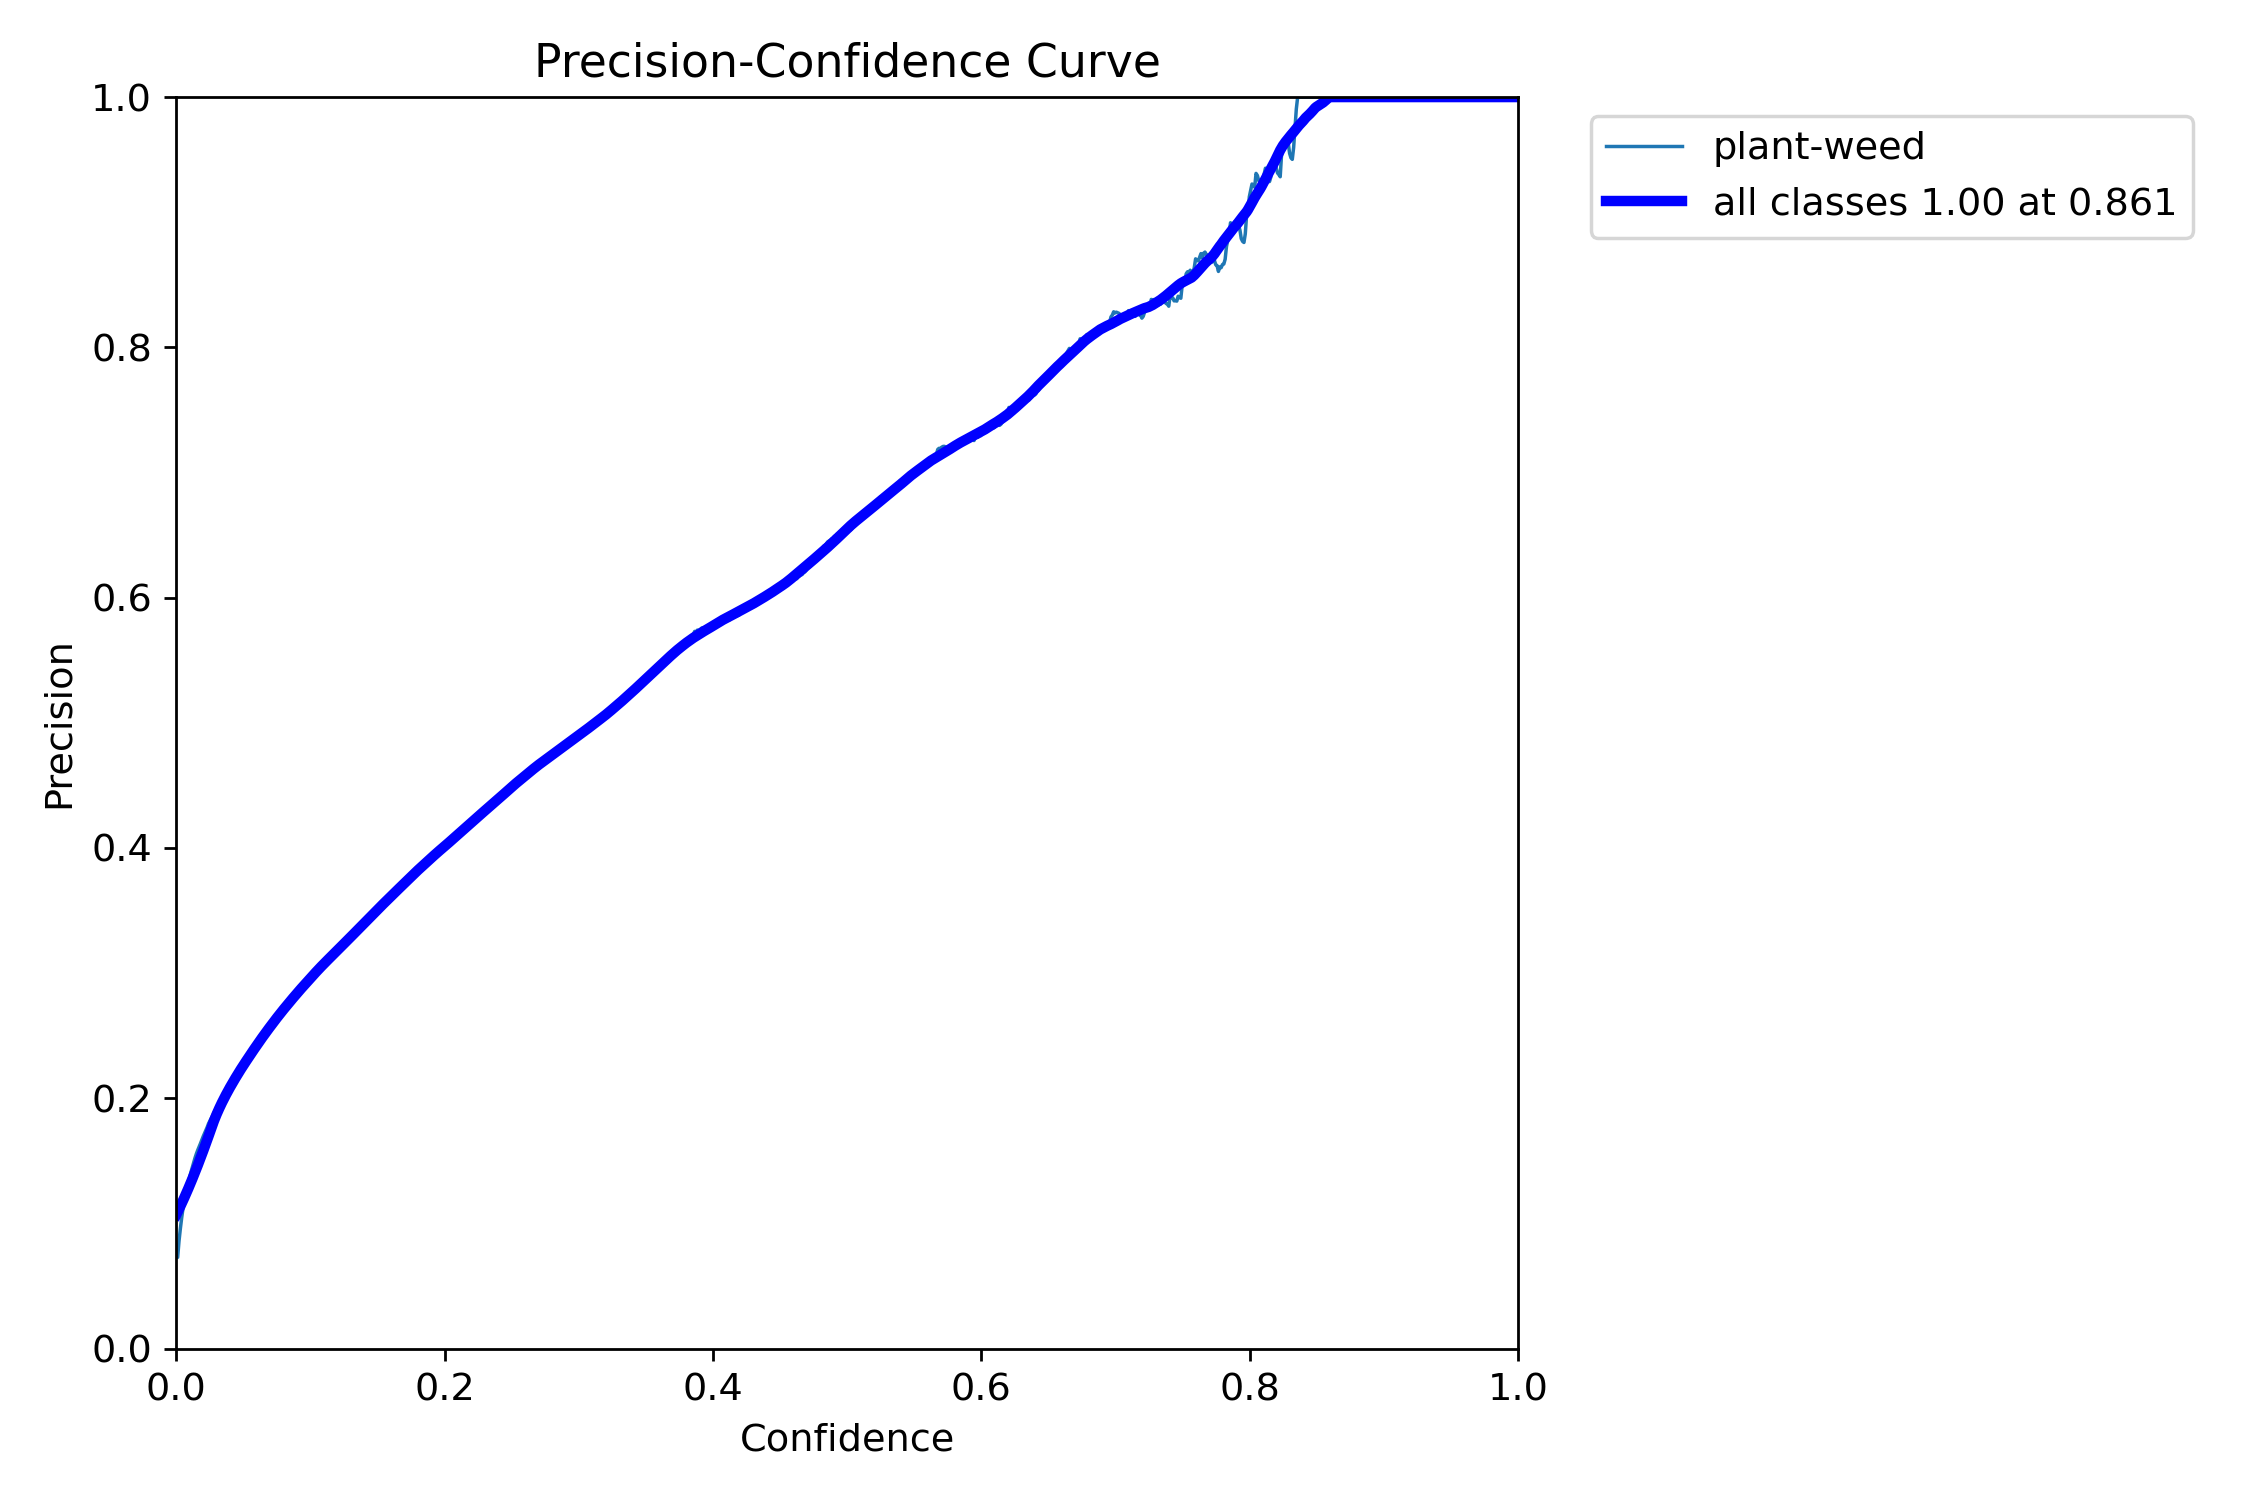

In [217]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

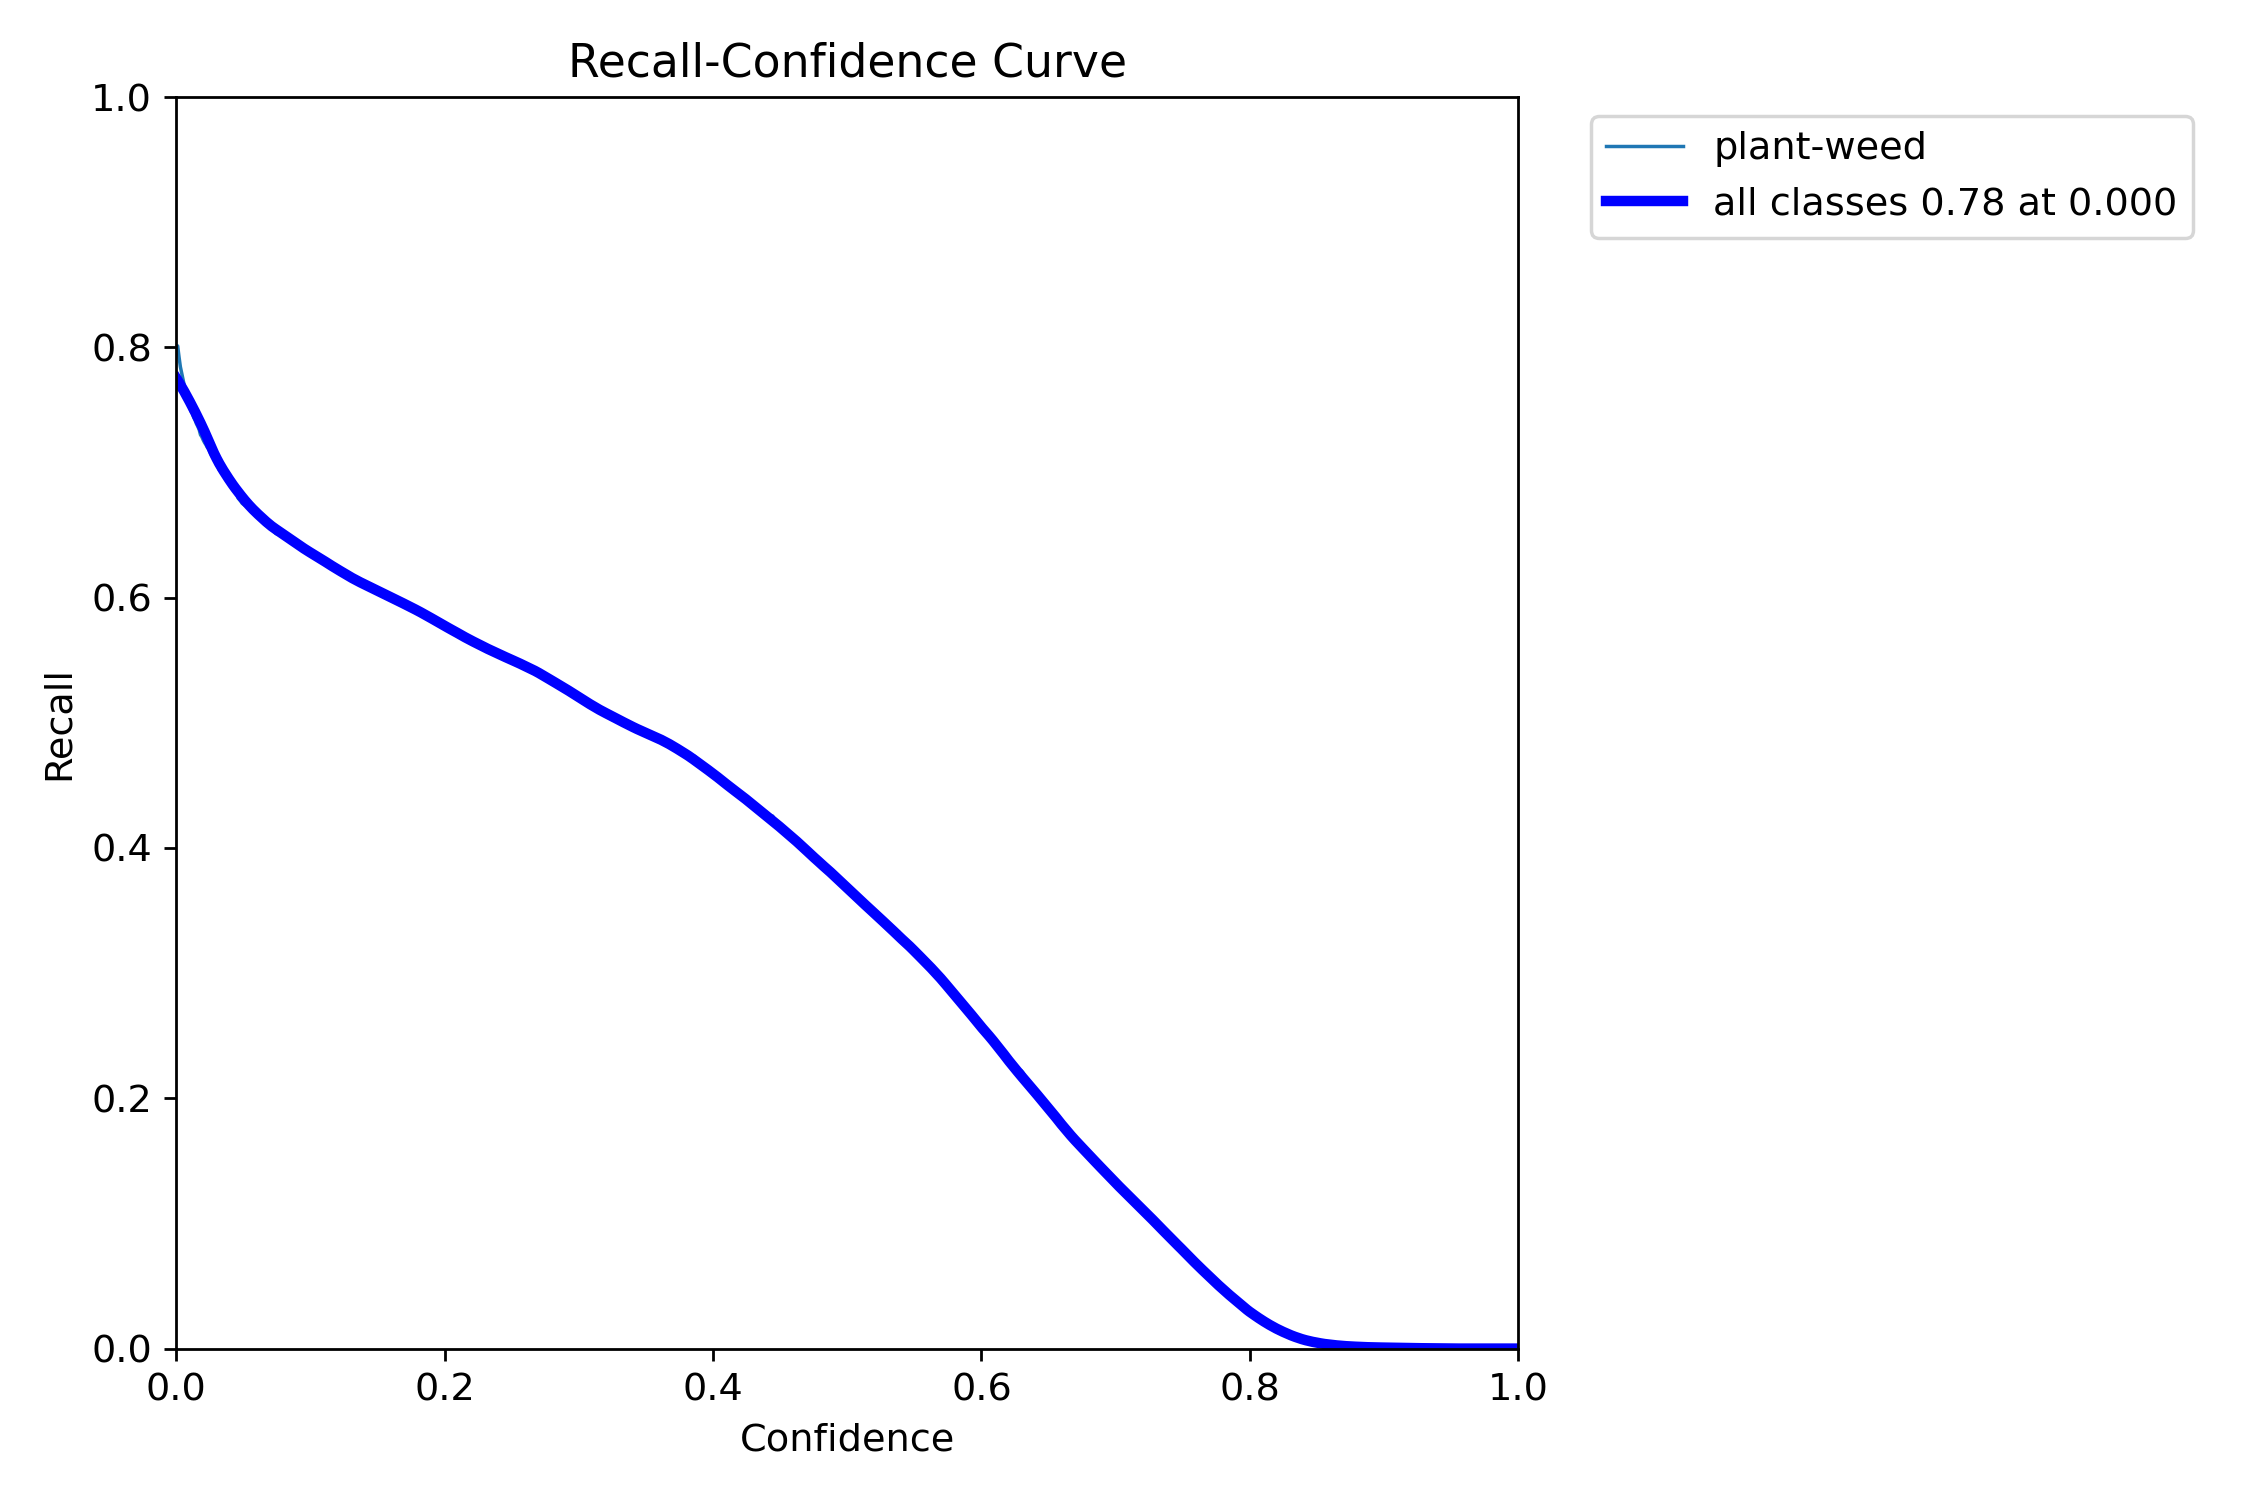

In [218]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

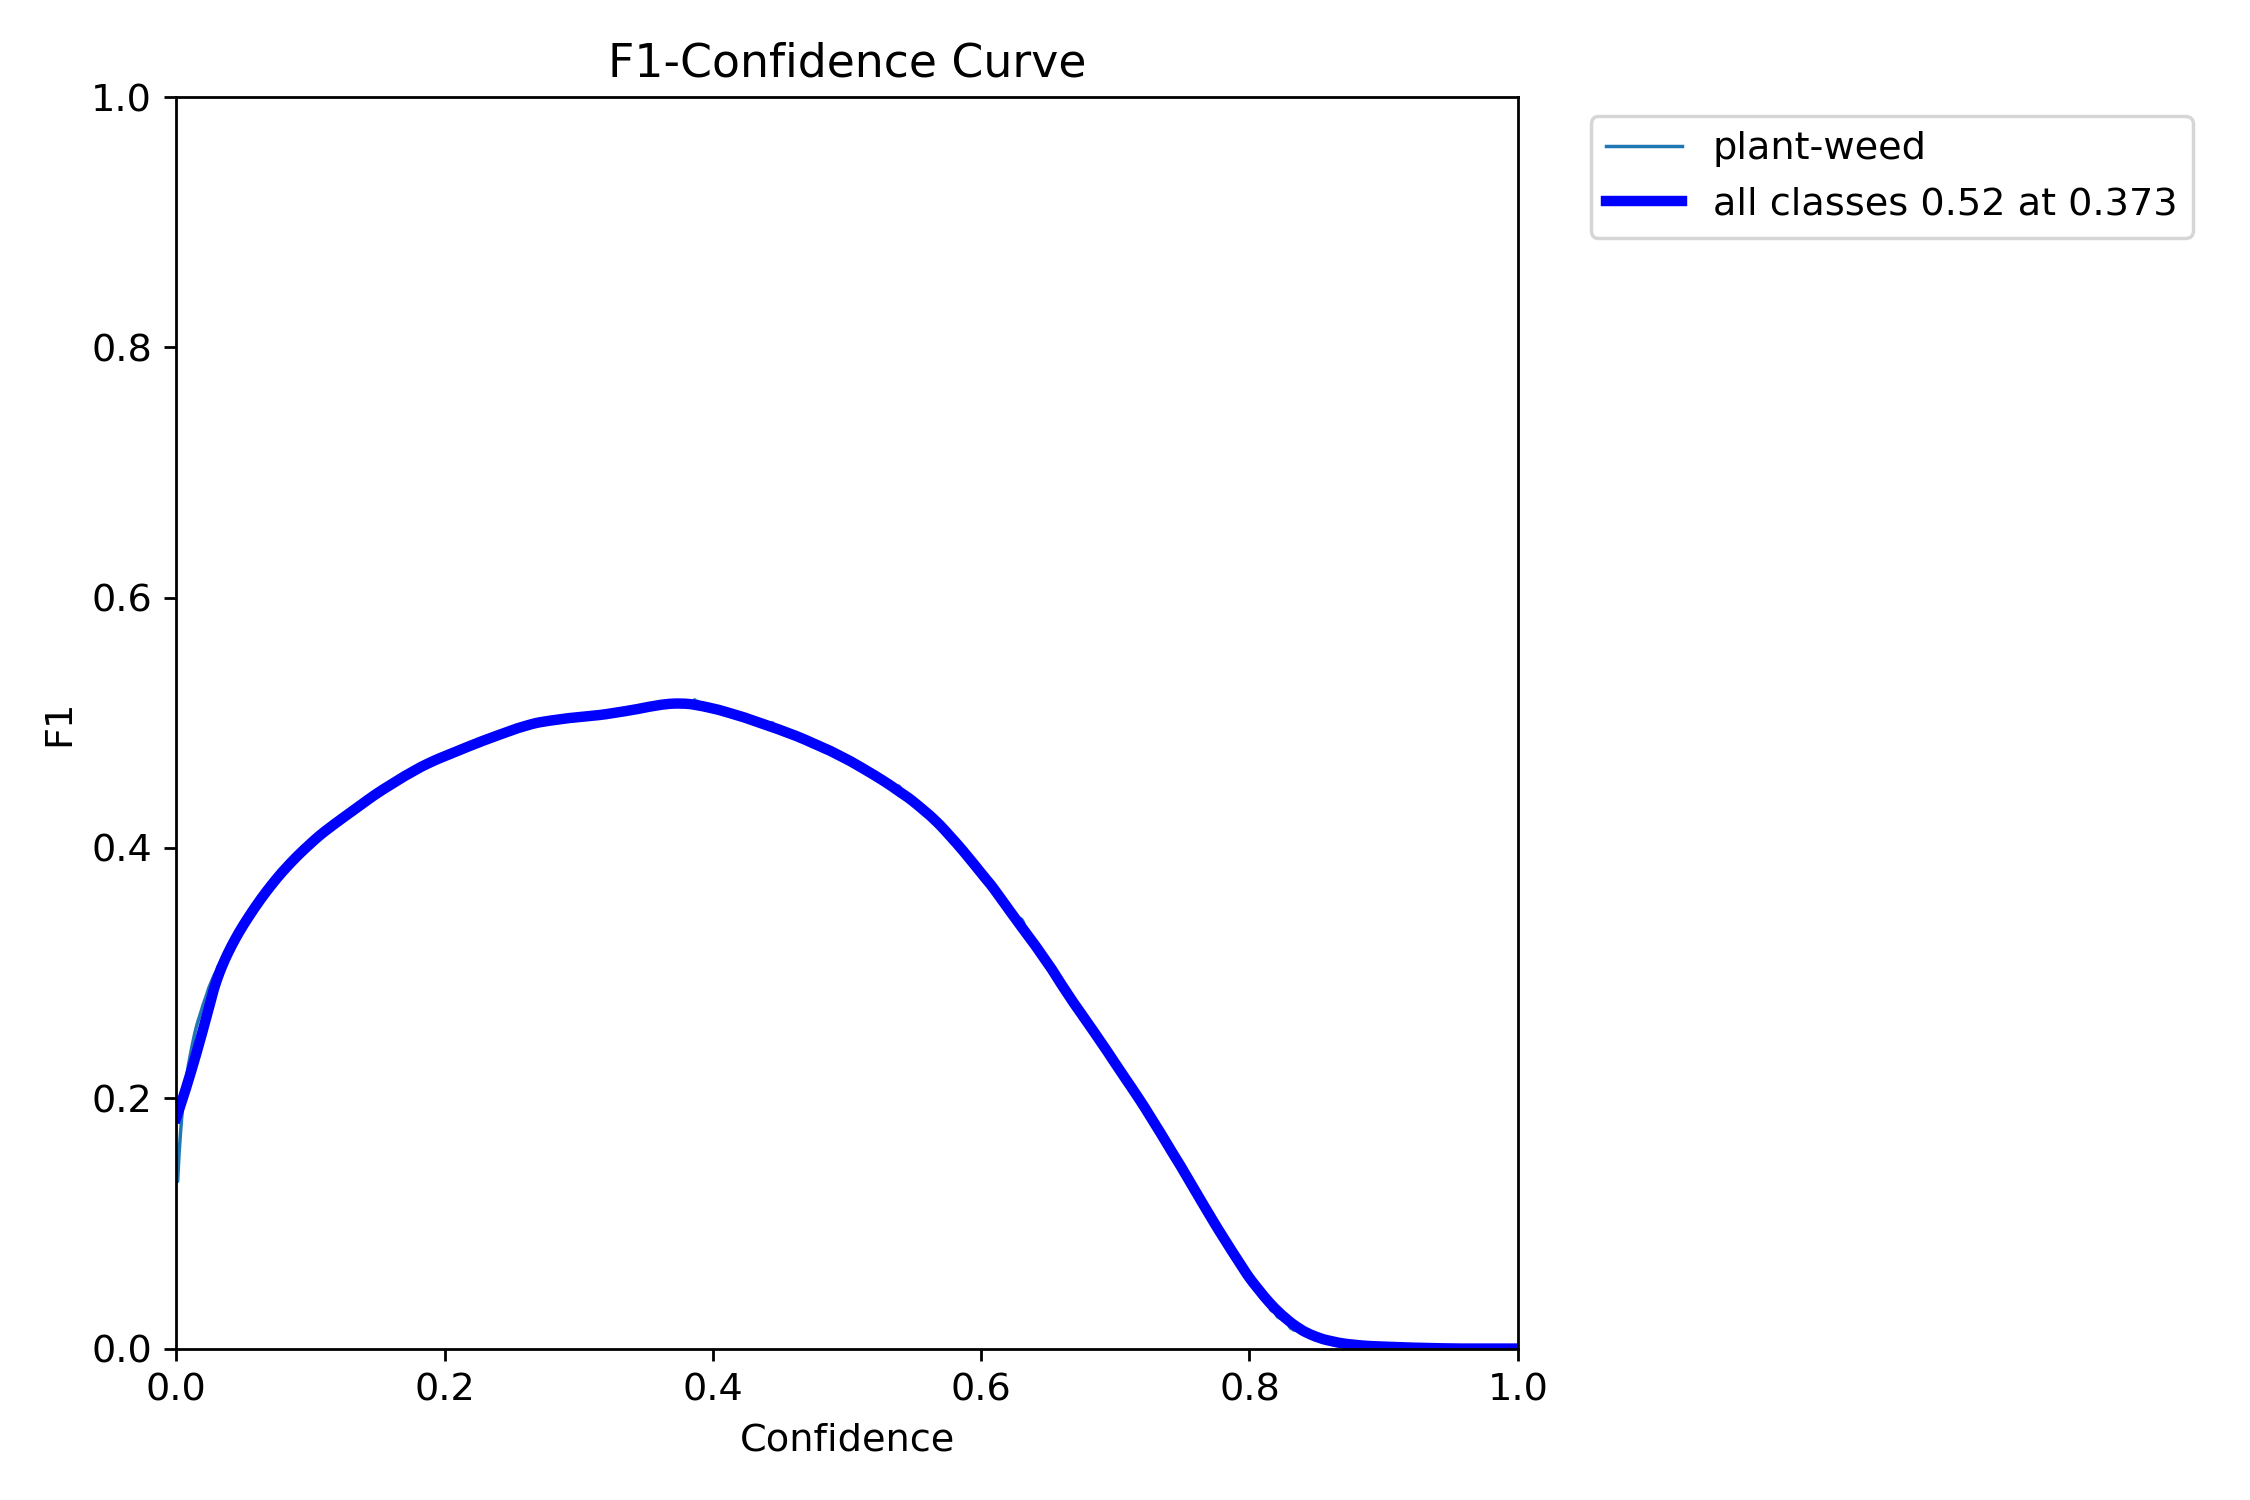

In [219]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

----

## Experiment 21
### *YOLO V11 | ~1000 epochs*

In [220]:
folder = "v11/detect/train/"

In [221]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df3 = pd.read_csv(file_path)
df = df3.copy()
df3.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
174,175,1490.19,1.51101,0.87359,1.15193,0.48856,0.51681,0.44373,0.13994,2.55981,1.42757,1.62865,0.001655,0.001655,0.001655
175,176,1498.74,1.52474,0.87772,1.15712,0.50338,0.49398,0.45286,0.14484,2.60771,1.34410,1.65351,0.001654,0.001654,0.001654
176,177,1506.65,1.50277,0.87746,1.16702,0.48768,0.50184,0.44876,0.14498,2.59264,1.37950,1.67001,0.001652,0.001652,0.001652
177,178,1515.03,1.51557,0.87303,1.15136,0.54274,0.49149,0.46354,0.14866,2.53651,1.36784,1.62678,0.001650,0.001650,0.001650
178,179,1523.66,1.50475,0.86895,1.16737,0.53314,0.50011,0.46434,0.14323,2.56531,1.40423,1.61734,0.001648,0.001648,0.001648


In [222]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 25.394 min


#### Best epoch

In [223]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
131,132,1129.73,1.62771,0.96599,1.21858,0.55956,0.5056,0.47743,0.15135,2.48119,1.36224,1.58653,0.001741,0.001741,0.001741,25.394333


In [224]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print("Proceso de entrenamiento:")
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Proceso de entrenamiento:
Mejor época de entrenamiento 132 con mAP50 de 0.477


In [225]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [226]:
TP = 1671
FP = 2229
FN = 738
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 4638


In [227]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.3602846054333765, 0.48059508408796897, 0.1591203104786546)

### Graphs

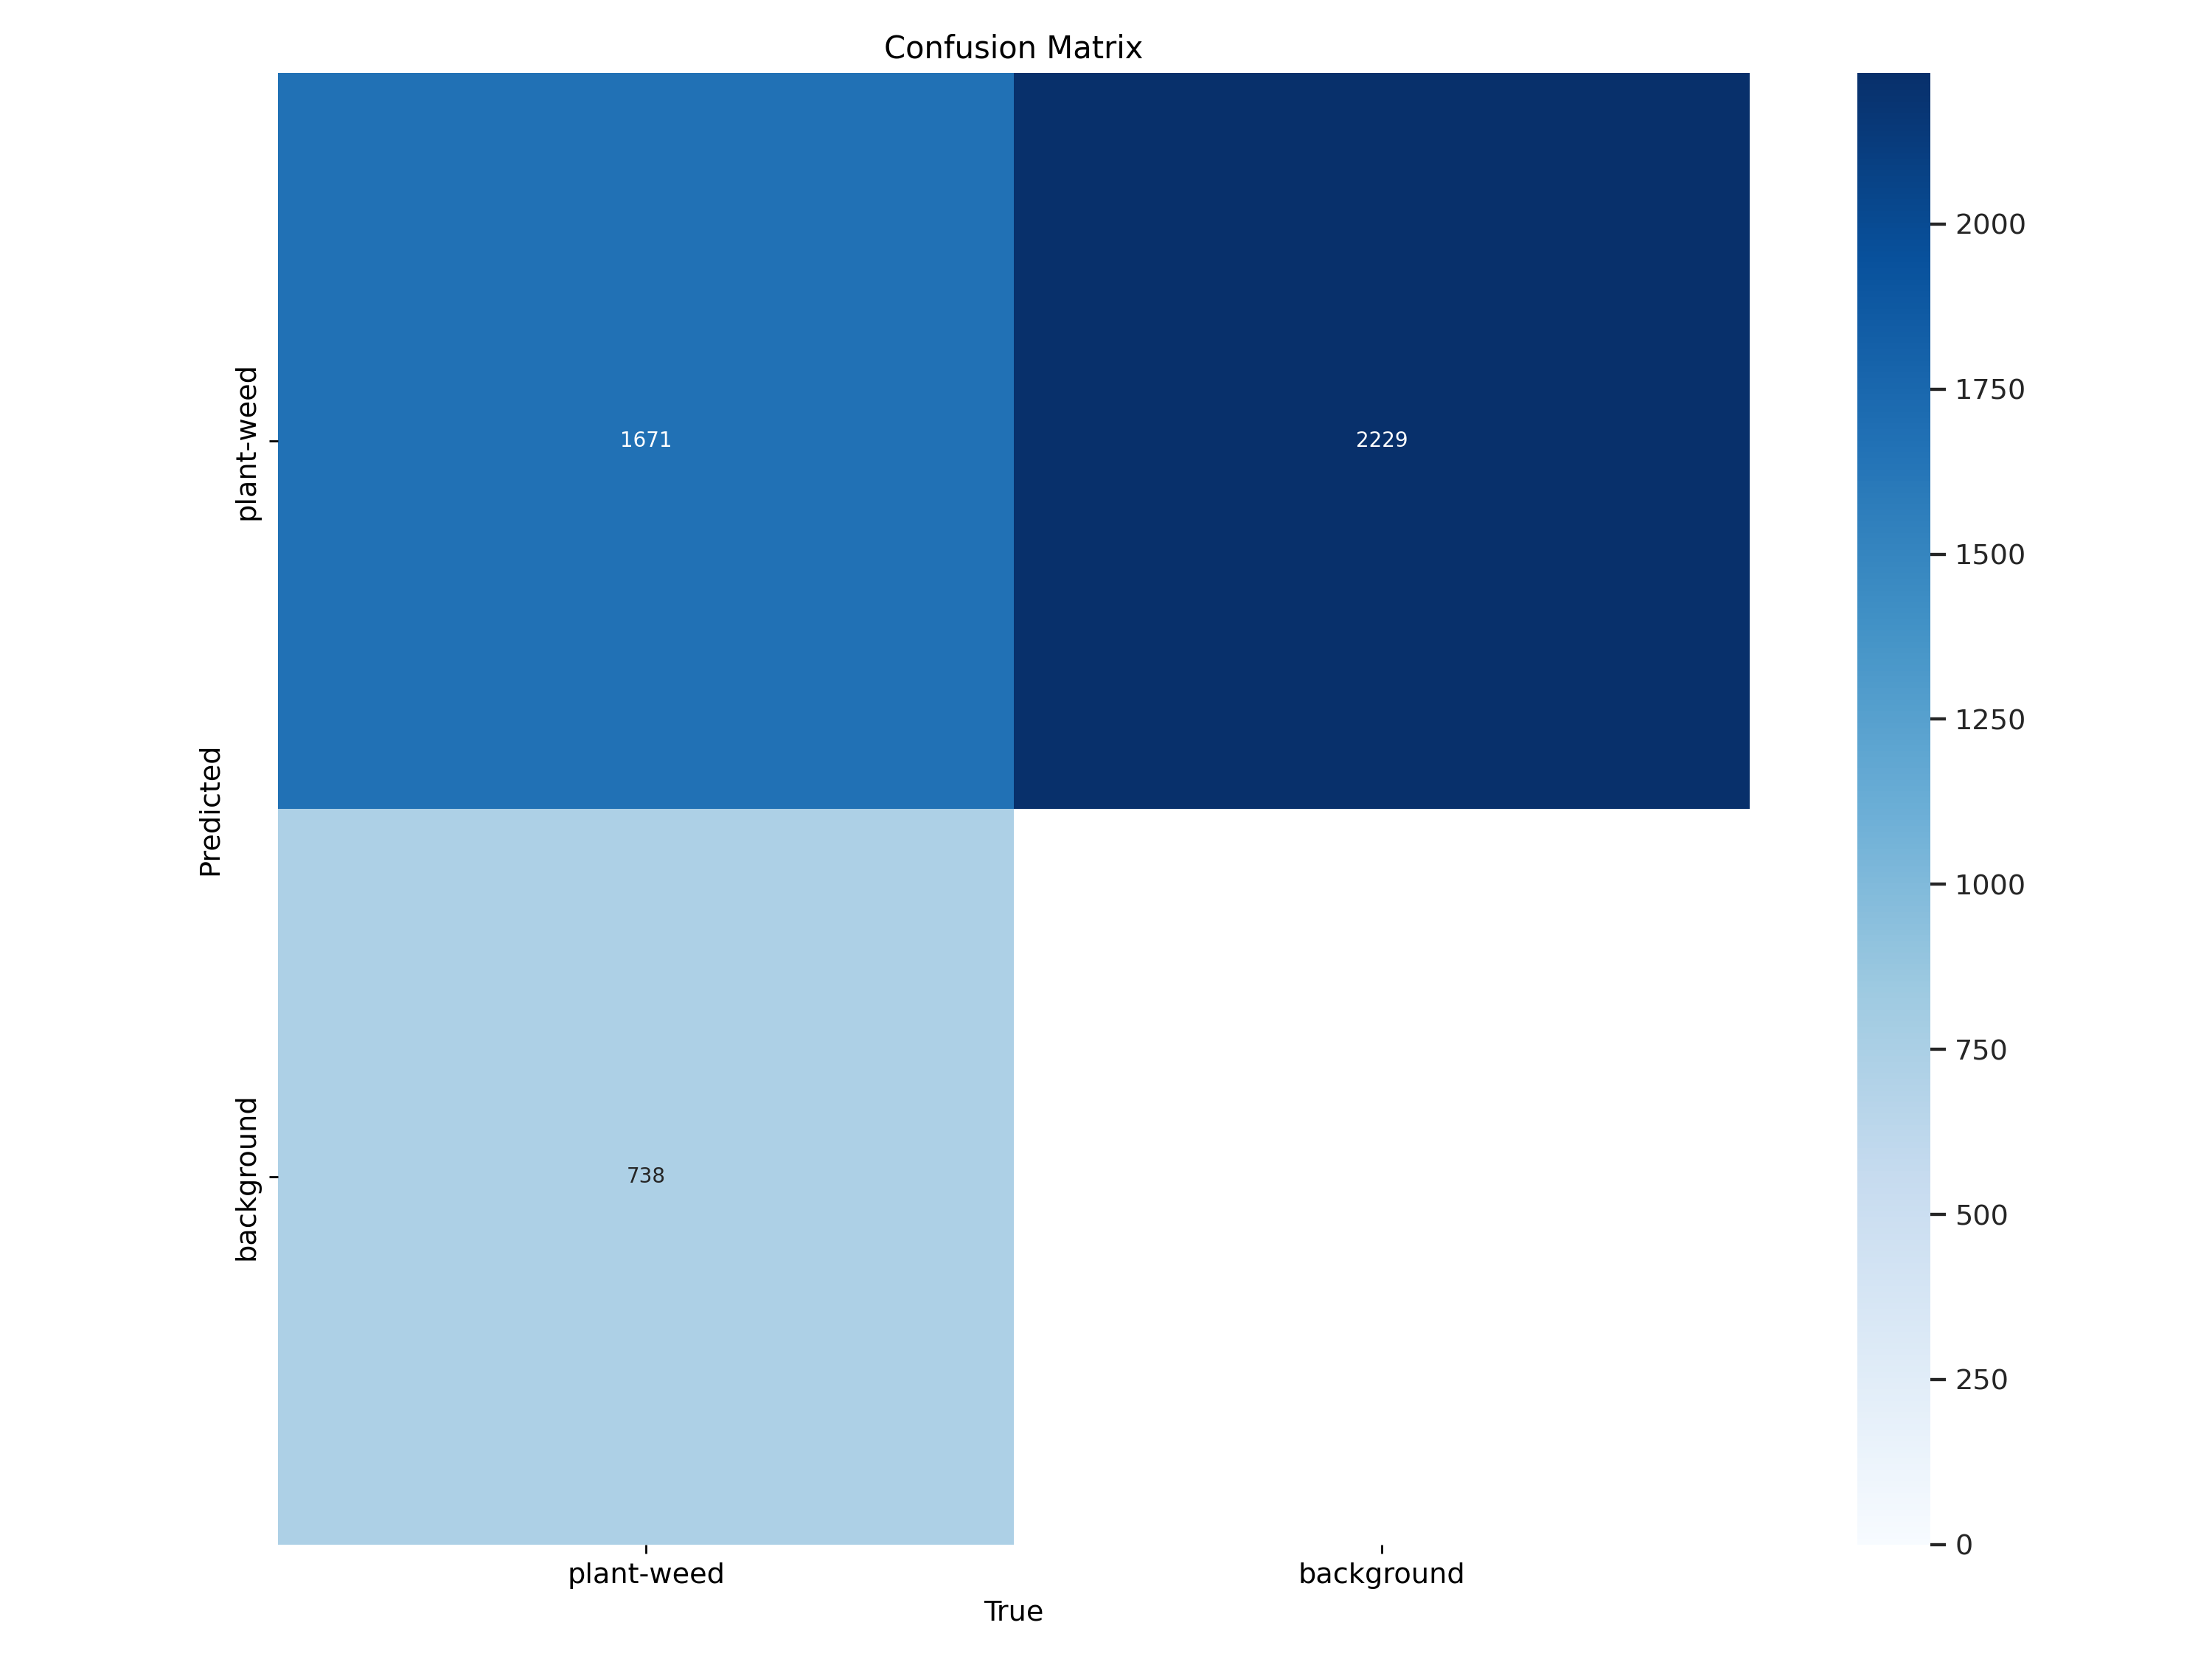

In [228]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

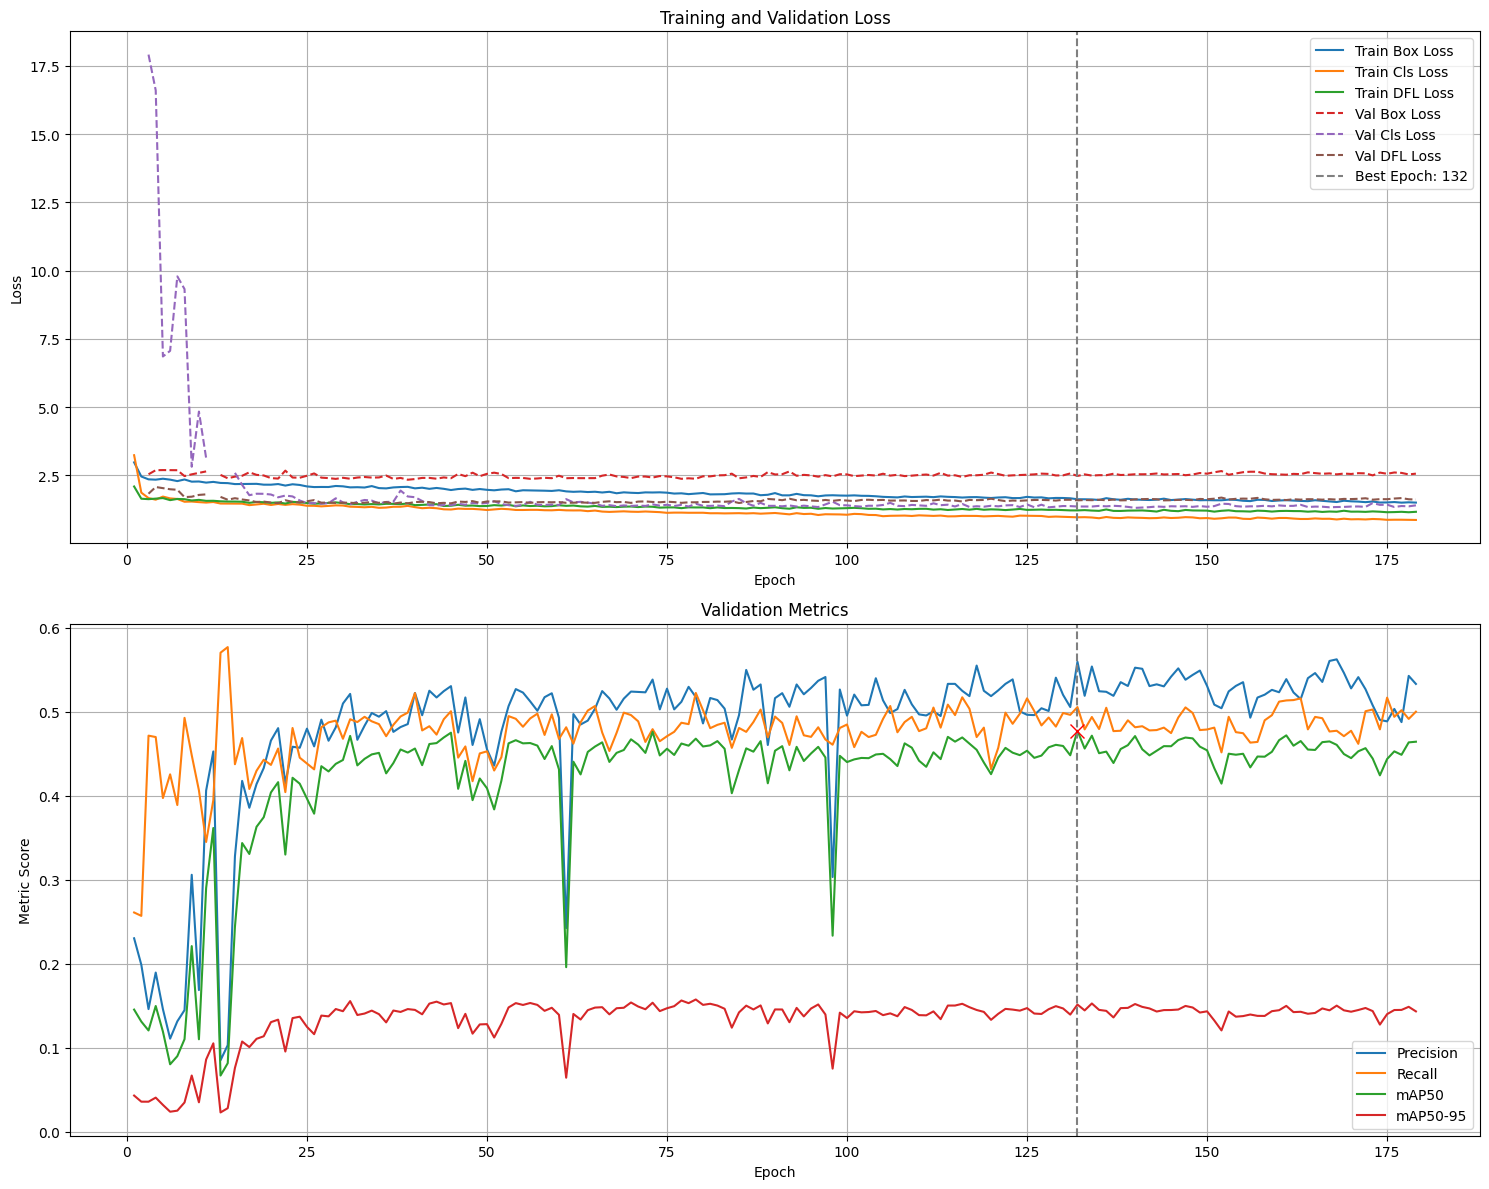

In [229]:
graph_training_metrics(df3, epoch, graph="full")


_**NOTA:** `patience`=100 para EarlyStop_

In [230]:
graph_LrLoss_3D(df3)

Validation set


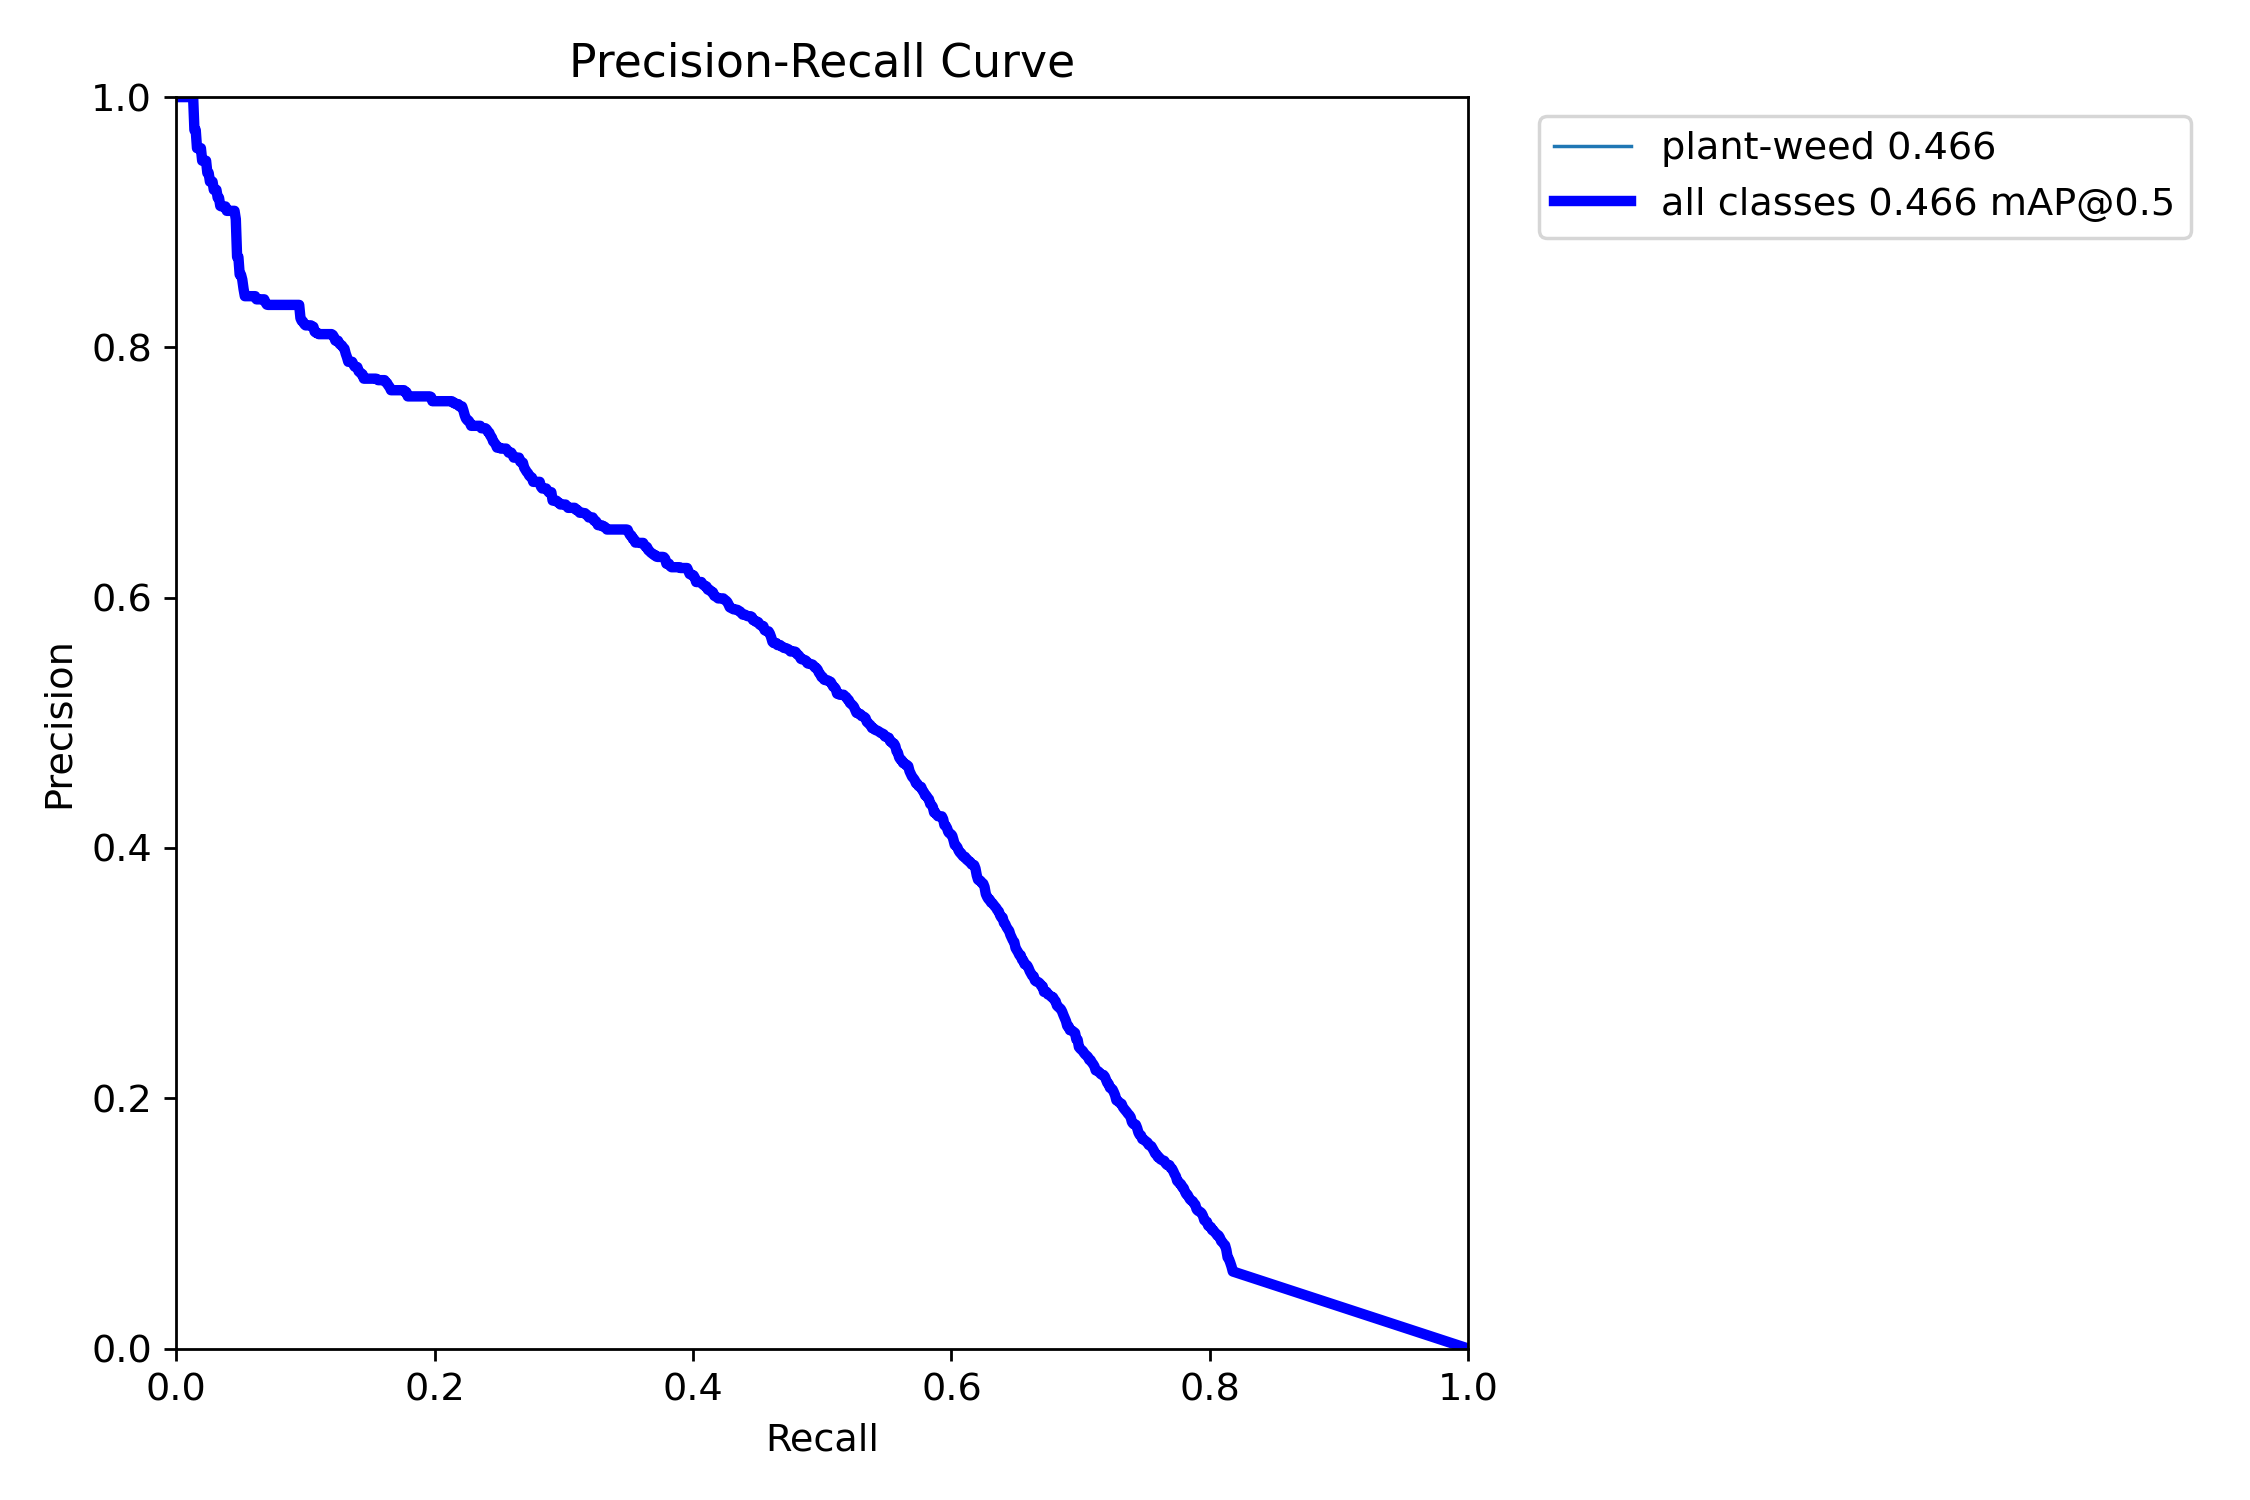

In [231]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

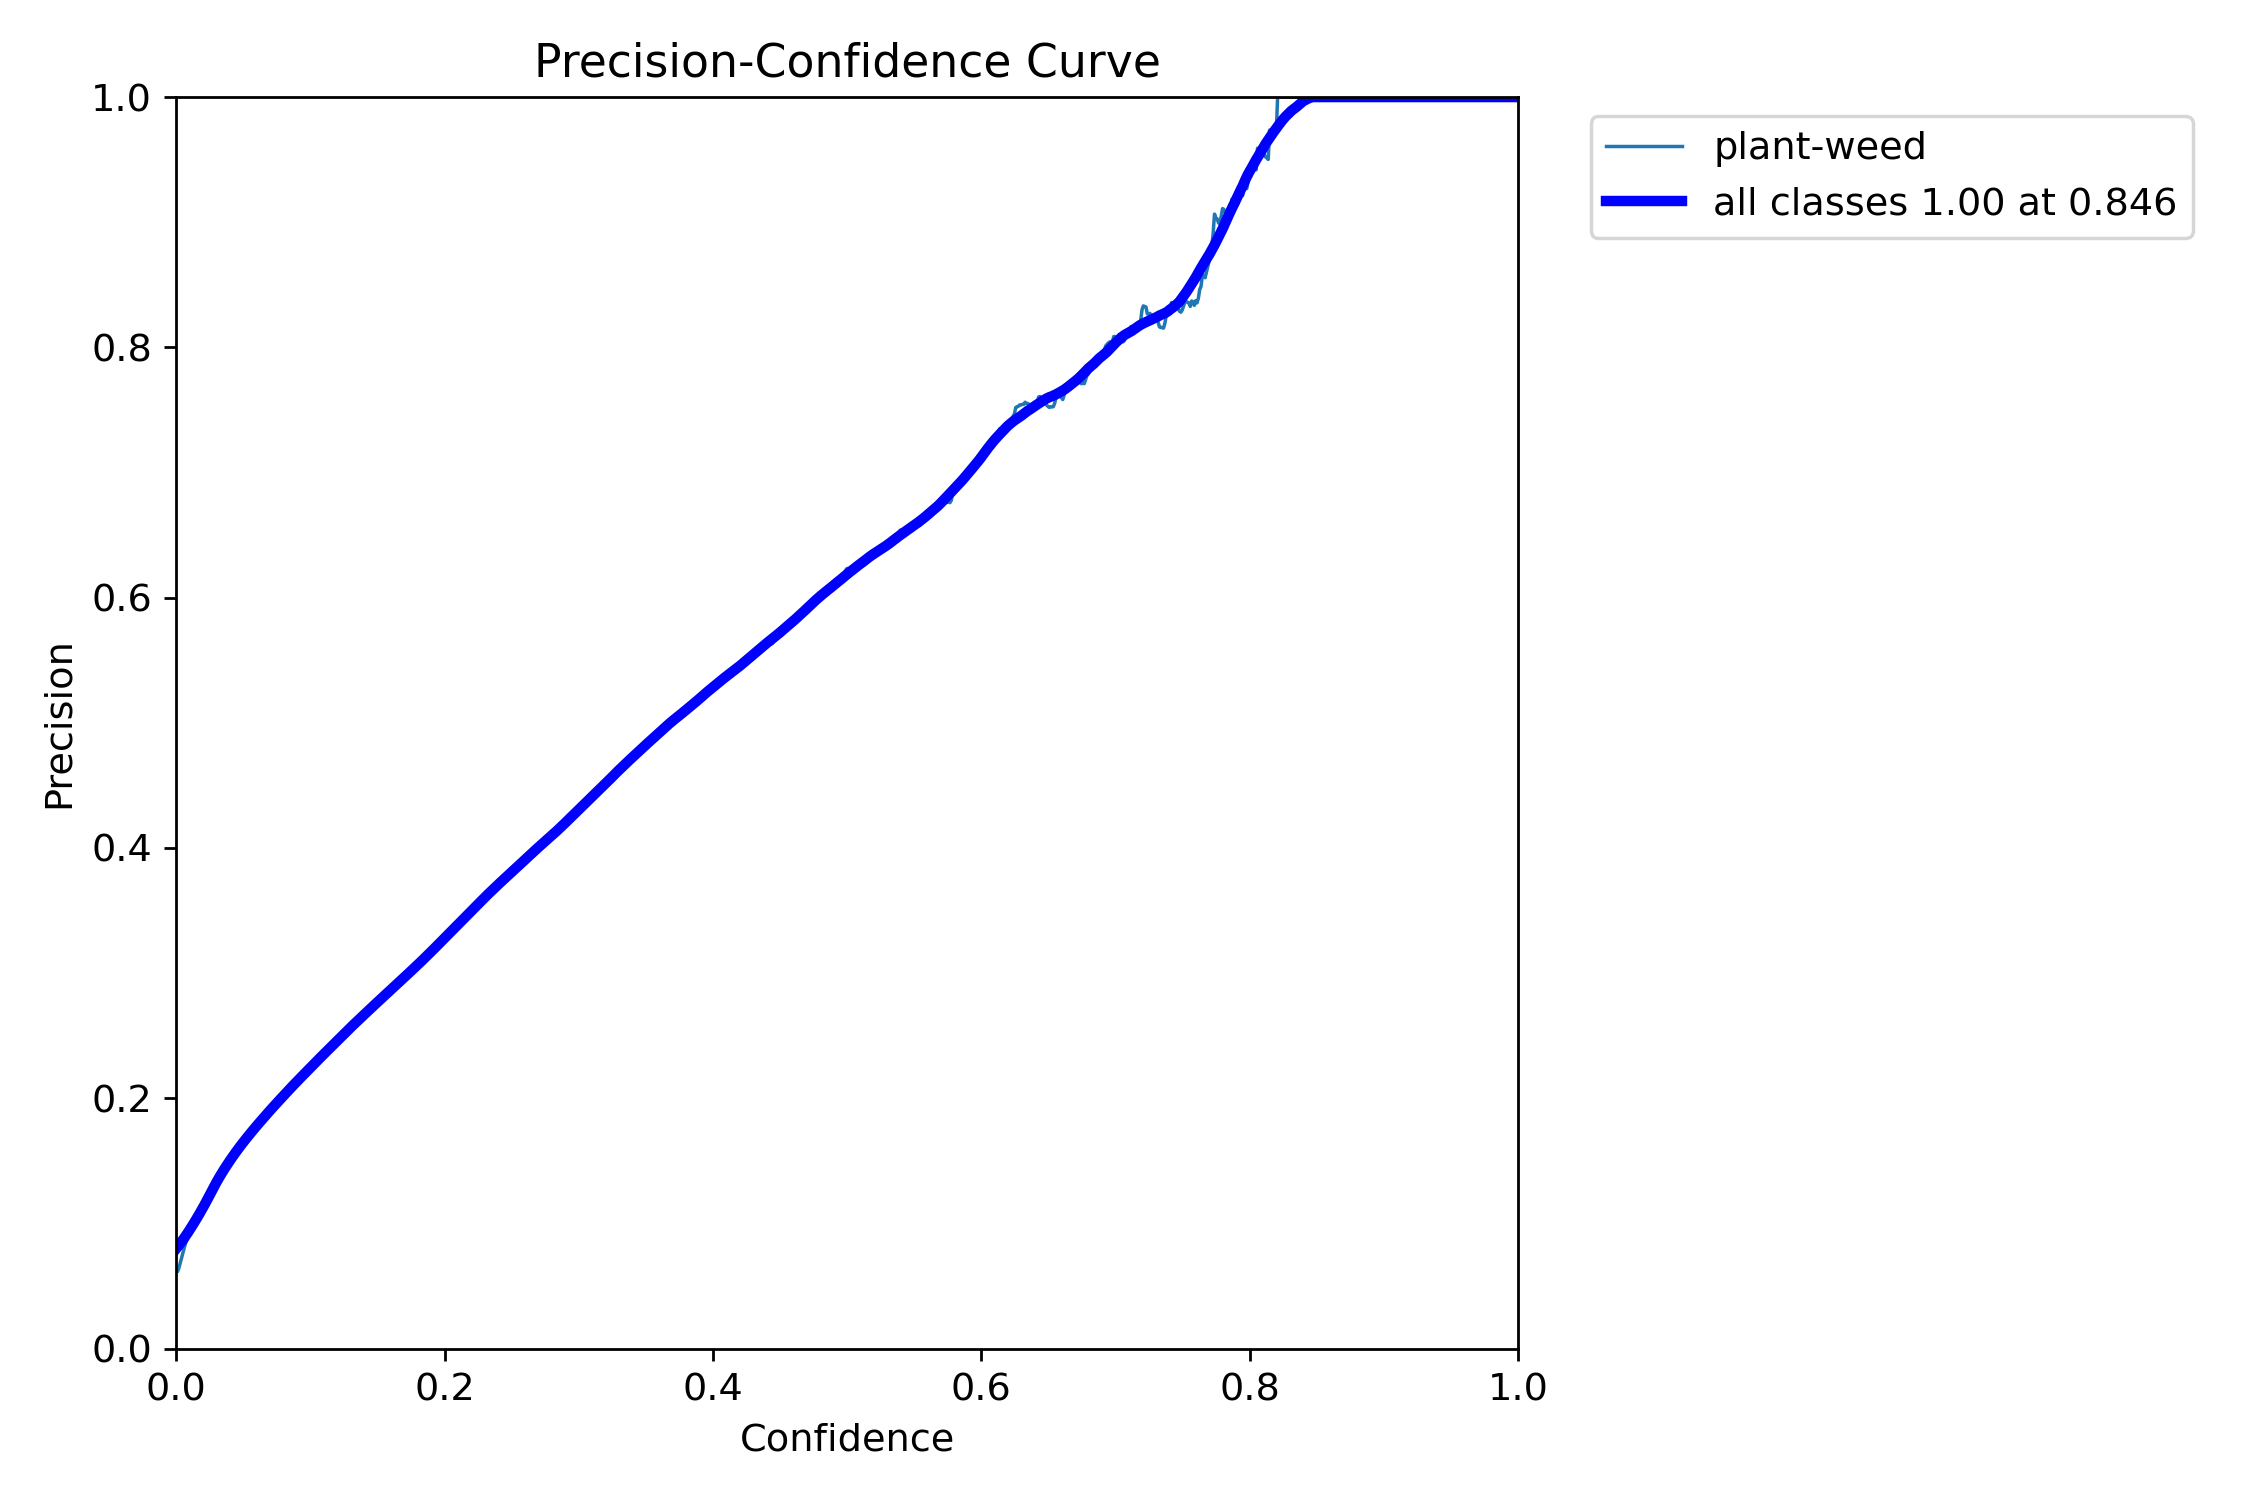

In [232]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

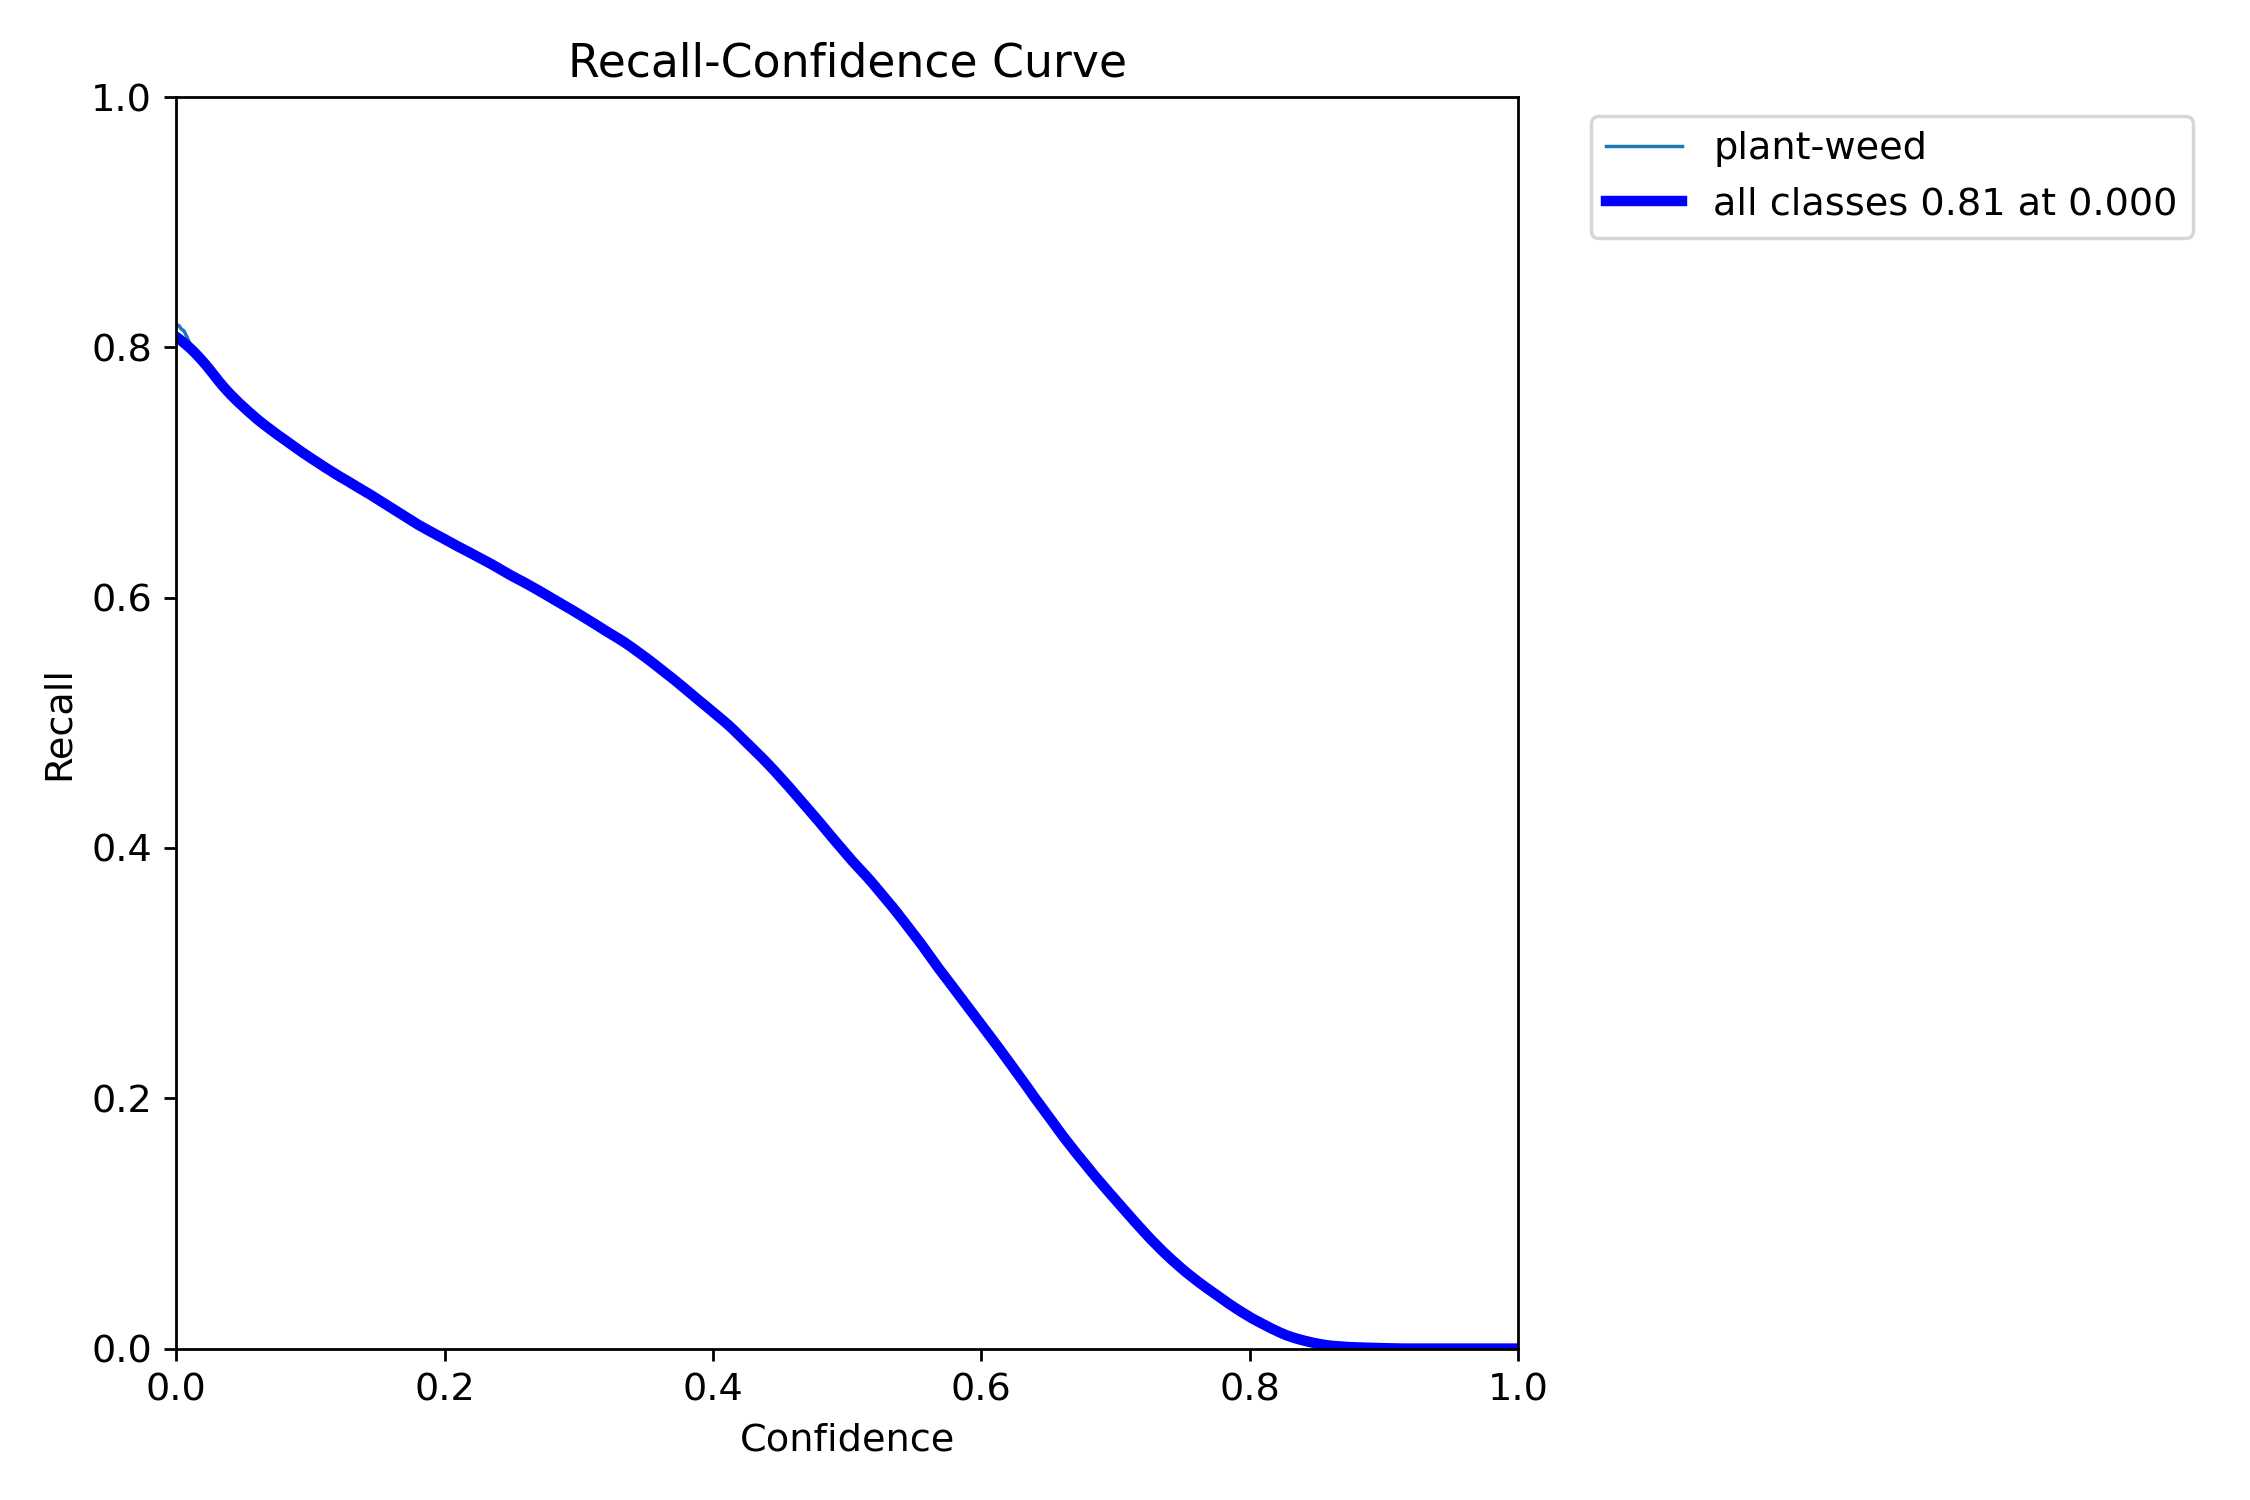

In [233]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

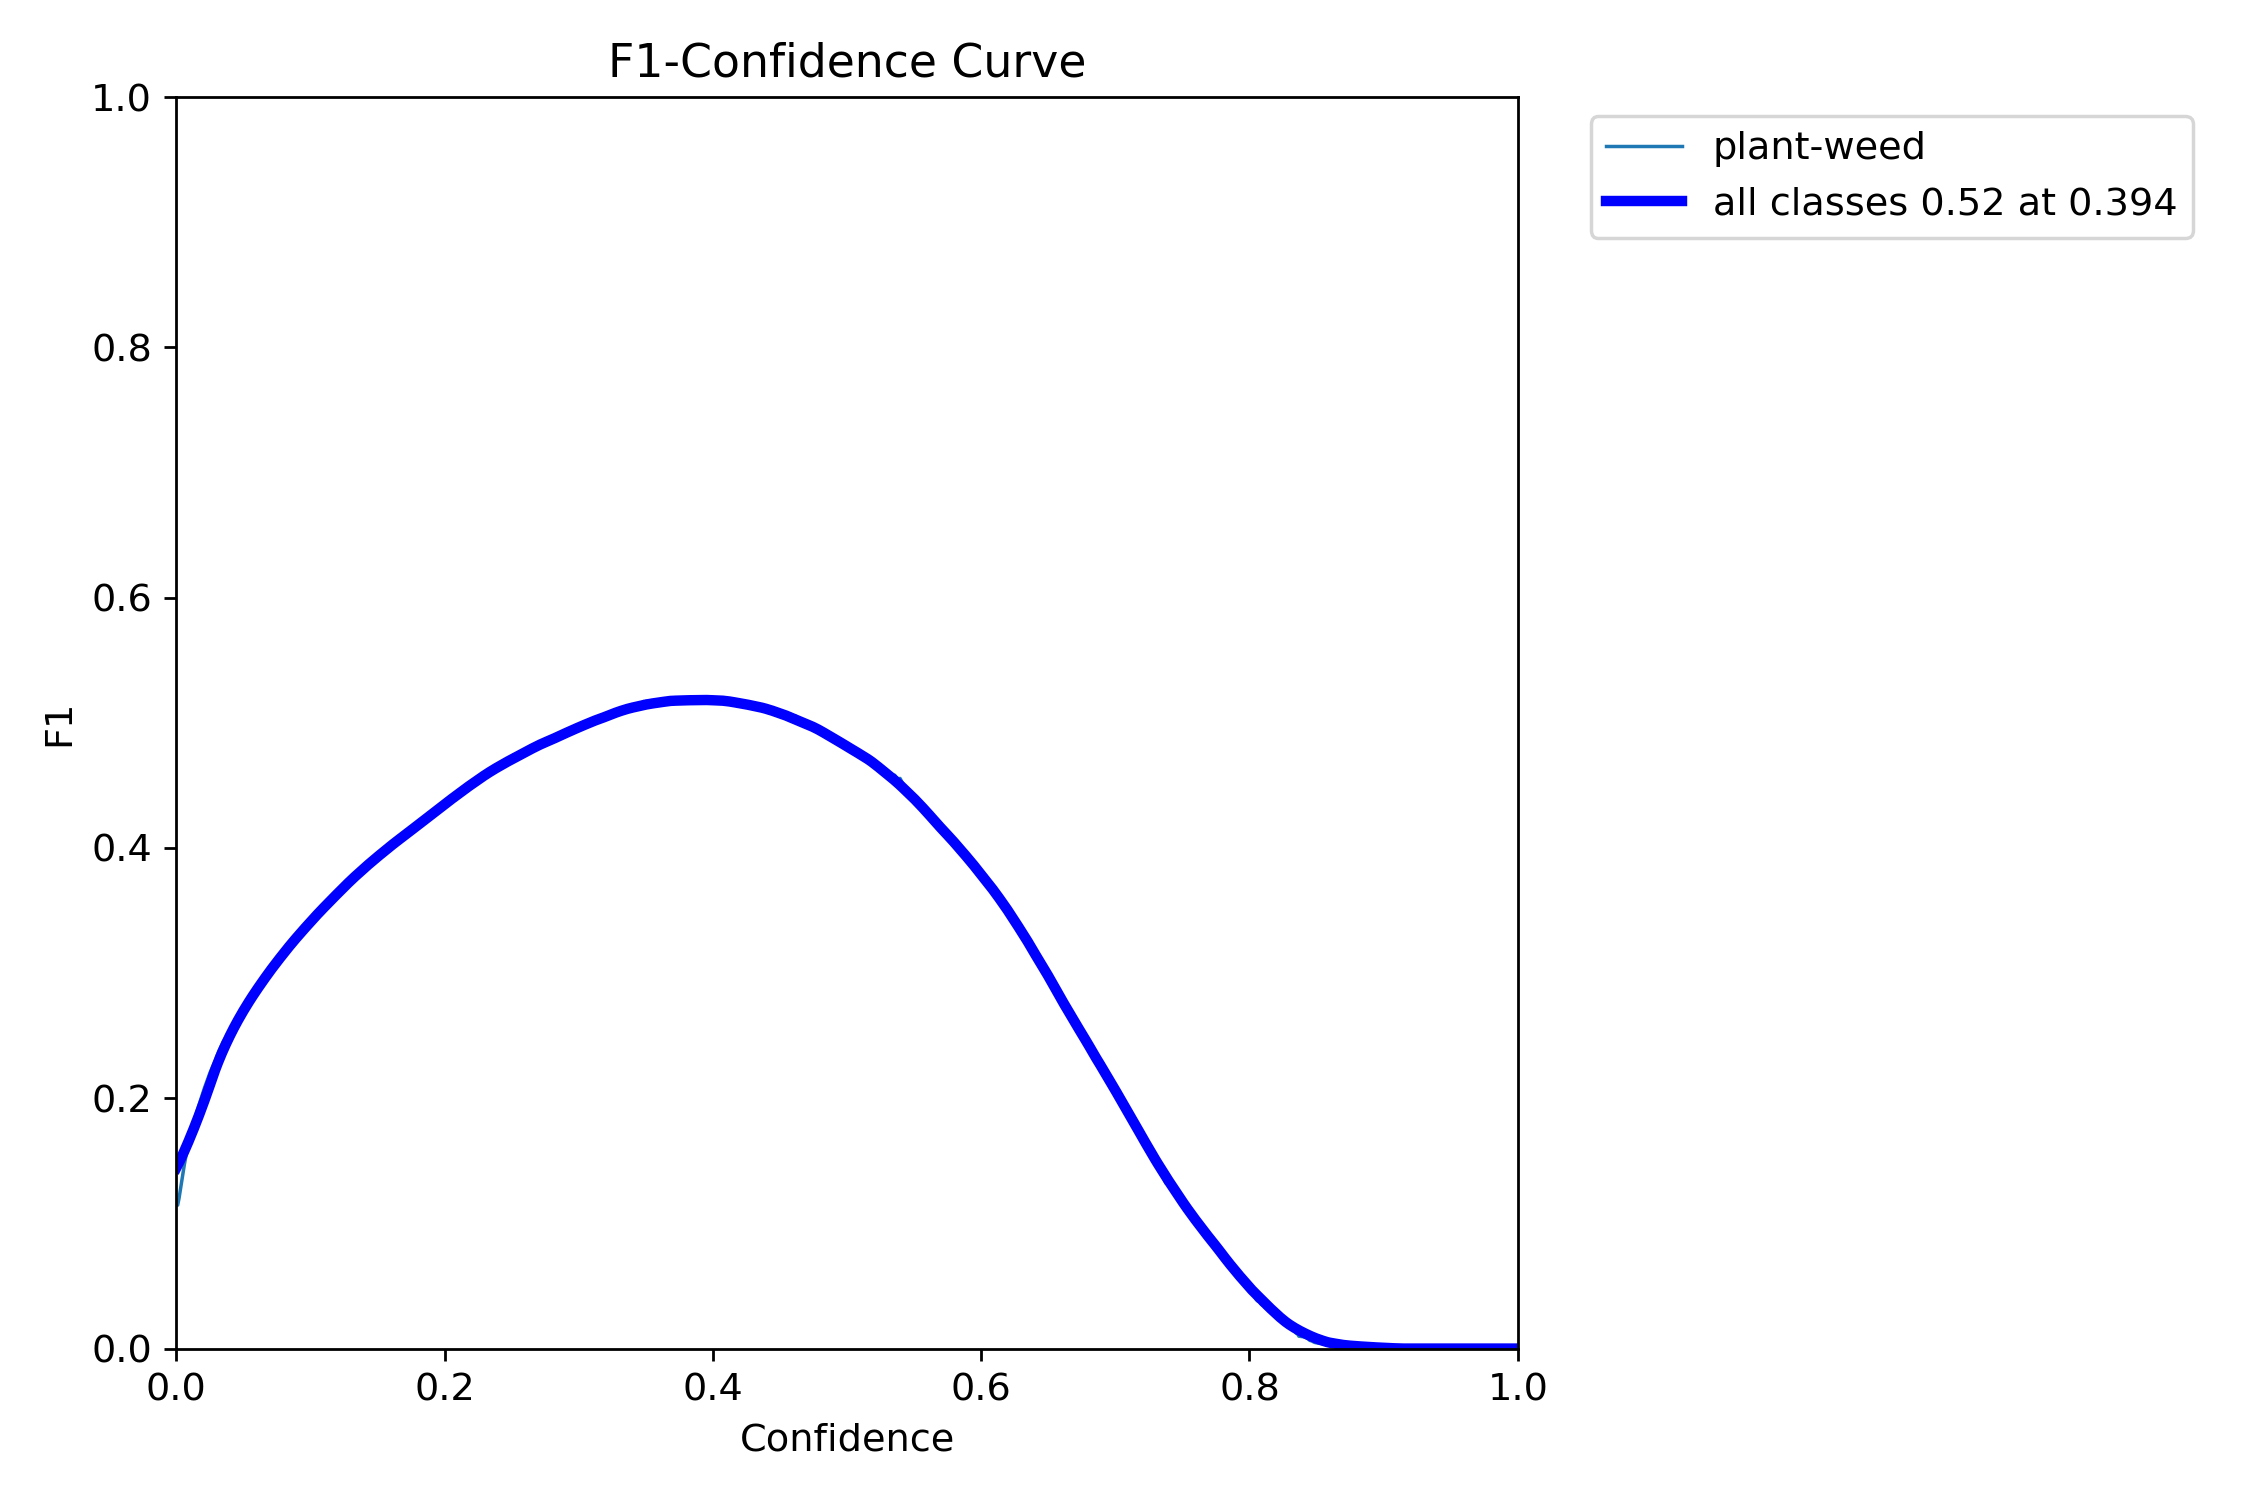

In [234]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

From the F1 curve, the confidence value that optimizes precision and recall is 0.231. In many cases a higher confidence value is desirable.

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

----

## Experiment 22
### *YOLO V12 | ~1000 epochs*

In [235]:
folder = "v12/detect/train/"

In [236]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df4 = pd.read_csv(file_path)
df = df4.copy()
df4.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
193,194,1986.54,1.74282,1.06154,1.26103,0.50579,0.47708,0.45336,0.15019,2.47118,1.38499,1.55464,0.001618,0.001618,0.001618
194,195,1996.25,1.73807,1.05445,1.27429,0.53101,0.51512,0.47690,0.16097,2.45240,1.37174,1.55156,0.001616,0.001616,0.001616
195,196,2006.49,1.72928,1.03796,1.25840,0.53878,0.50311,0.47618,0.15936,2.47634,1.36013,1.57927,0.001614,0.001614,0.001614
196,197,2017.38,1.72826,1.04547,1.28383,0.55145,0.48028,0.46935,0.14802,2.53713,1.39401,1.58601,0.001612,0.001612,0.001612
197,198,2027.03,1.74443,1.03752,1.25750,0.52715,0.48277,0.46304,0.15341,2.48289,1.38310,1.56281,0.001610,0.001610,0.001610


In [237]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 33.784 min


#### Best epoch

In [238]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
97,98,997.231,1.94758,1.23569,1.40749,0.51662,0.52553,0.48711,0.1672,2.3452,1.67652,1.52583,0.001808,0.001808,0.001808,33.783833


In [239]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print("Proceso de entrenamiento:")
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Proceso de entrenamiento:
Mejor época de entrenamiento 98 con mAP50 de 0.487


In [240]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [241]:
TP = 1774
FP = 3374
FN = 635
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 5783


In [242]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.3067611966107557, 0.5834342037005015, 0.10980459968874287)

### Graphs

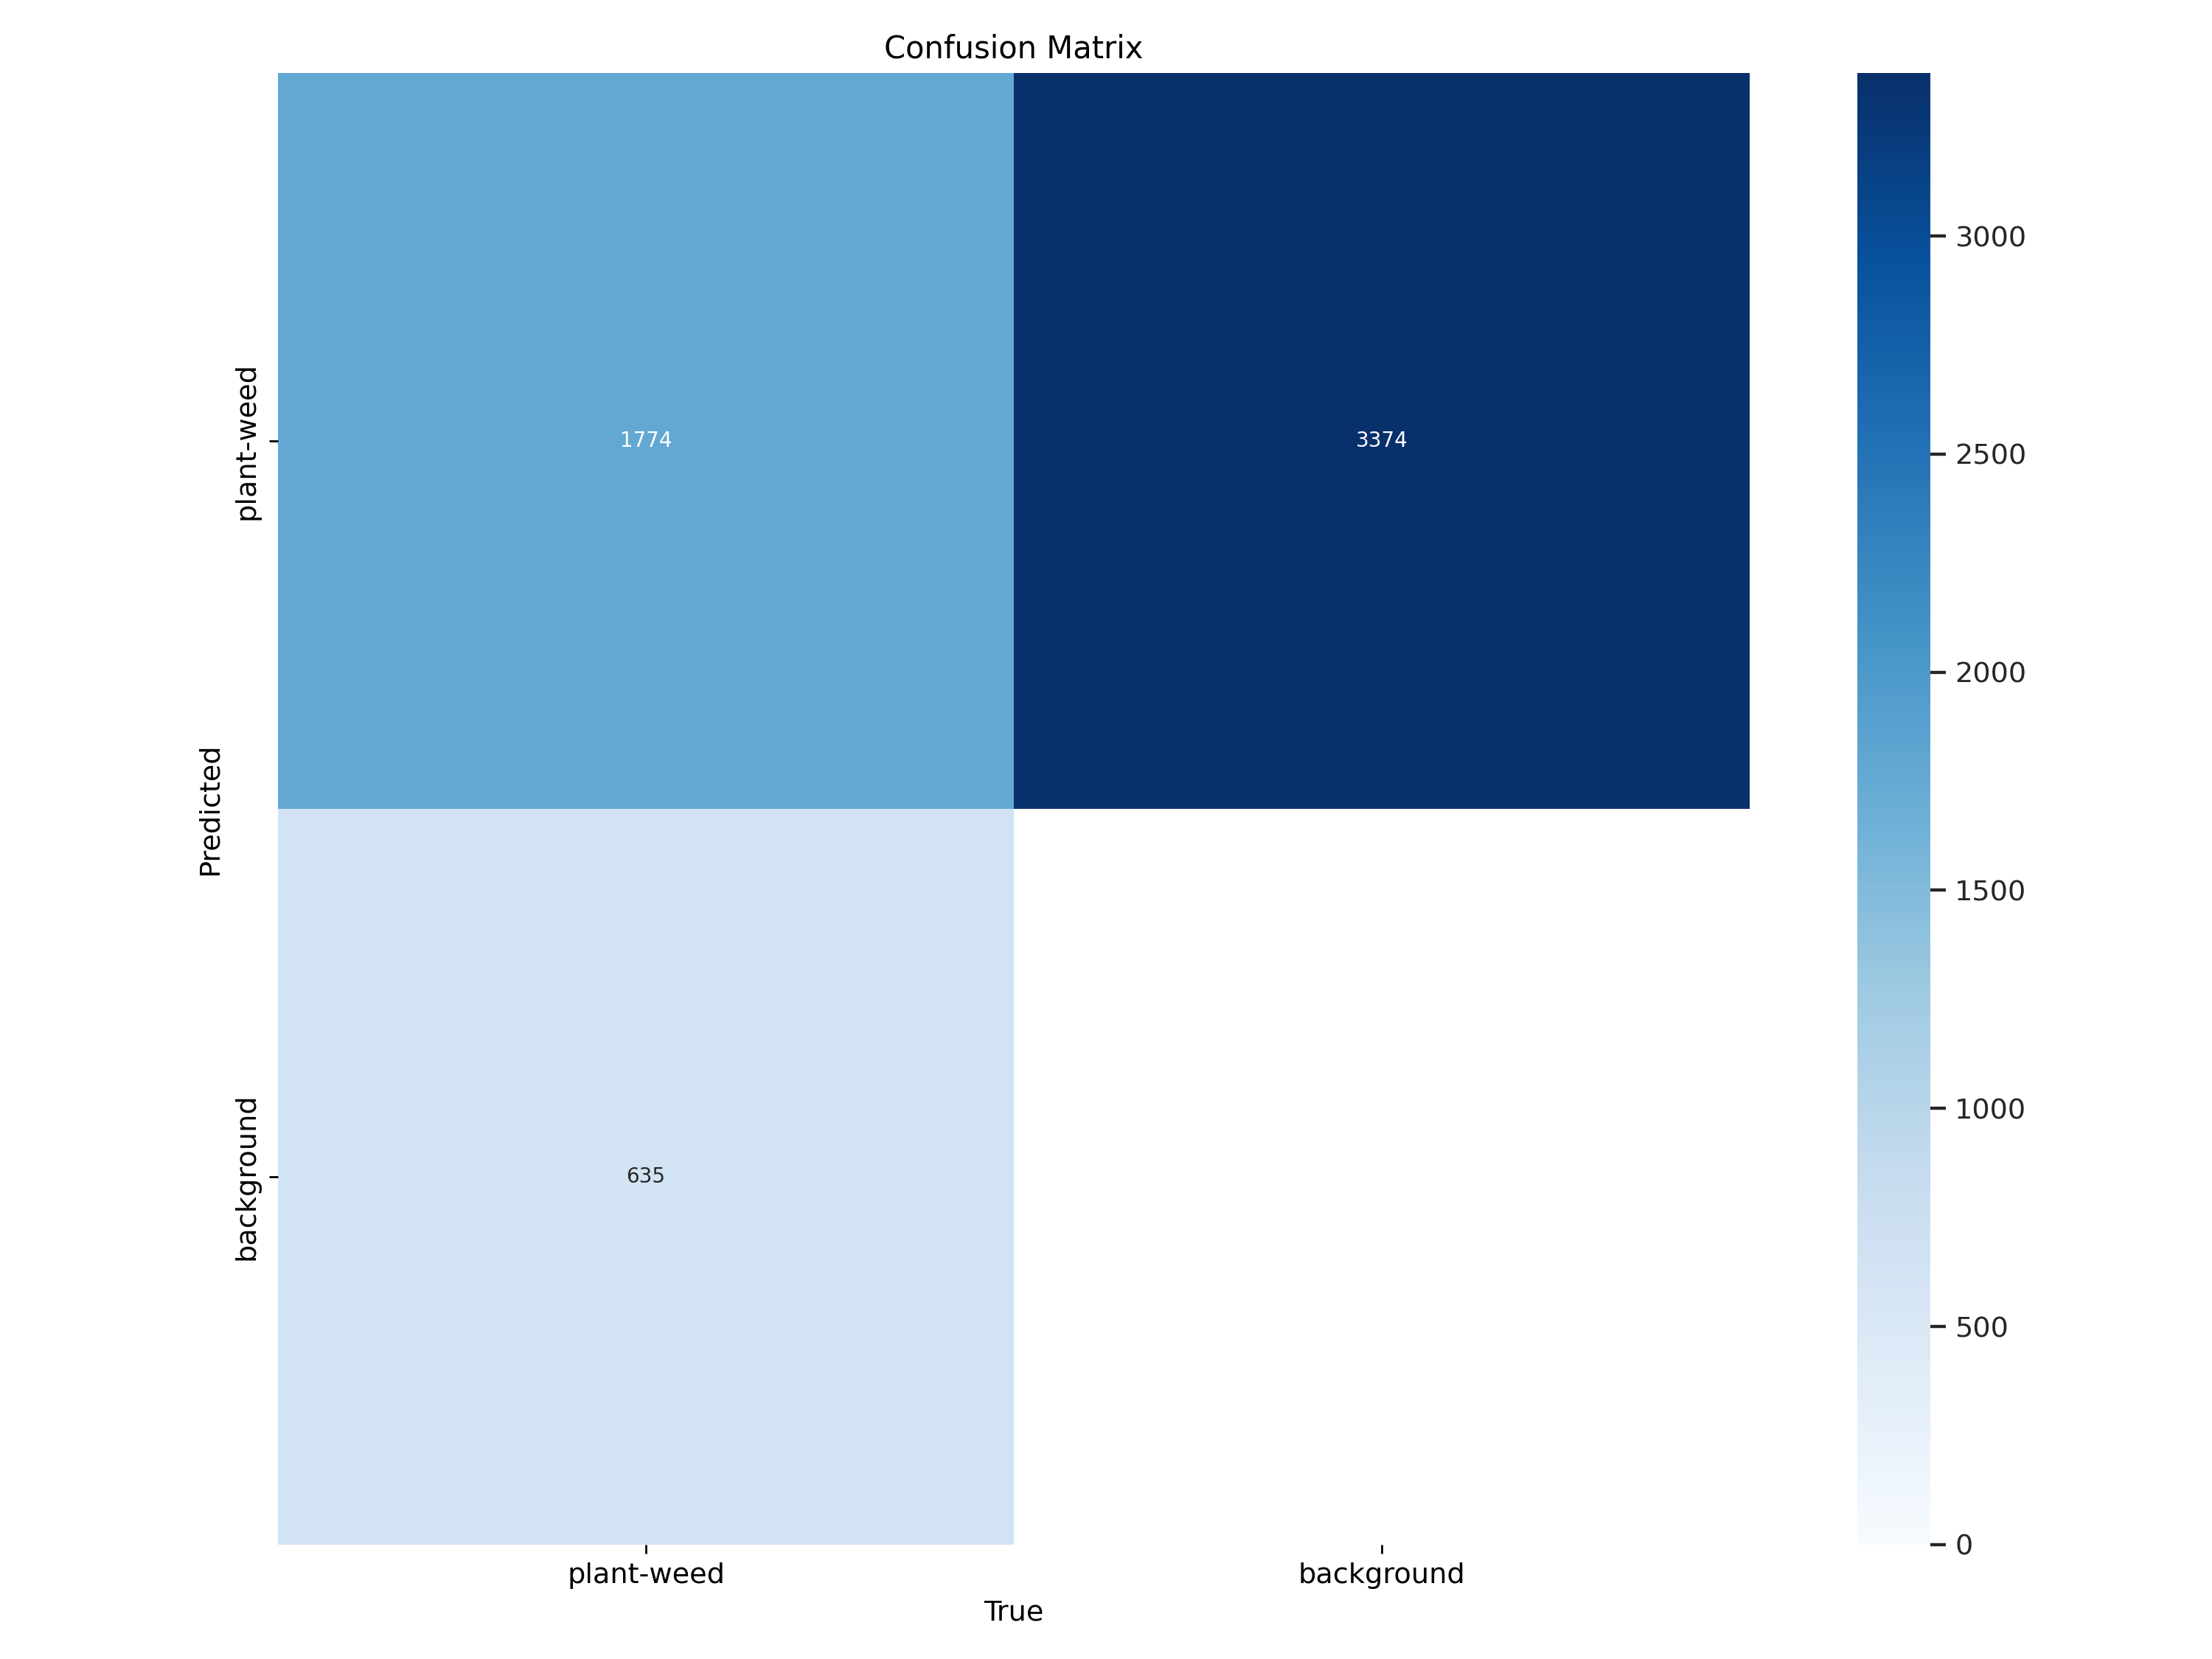

In [243]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

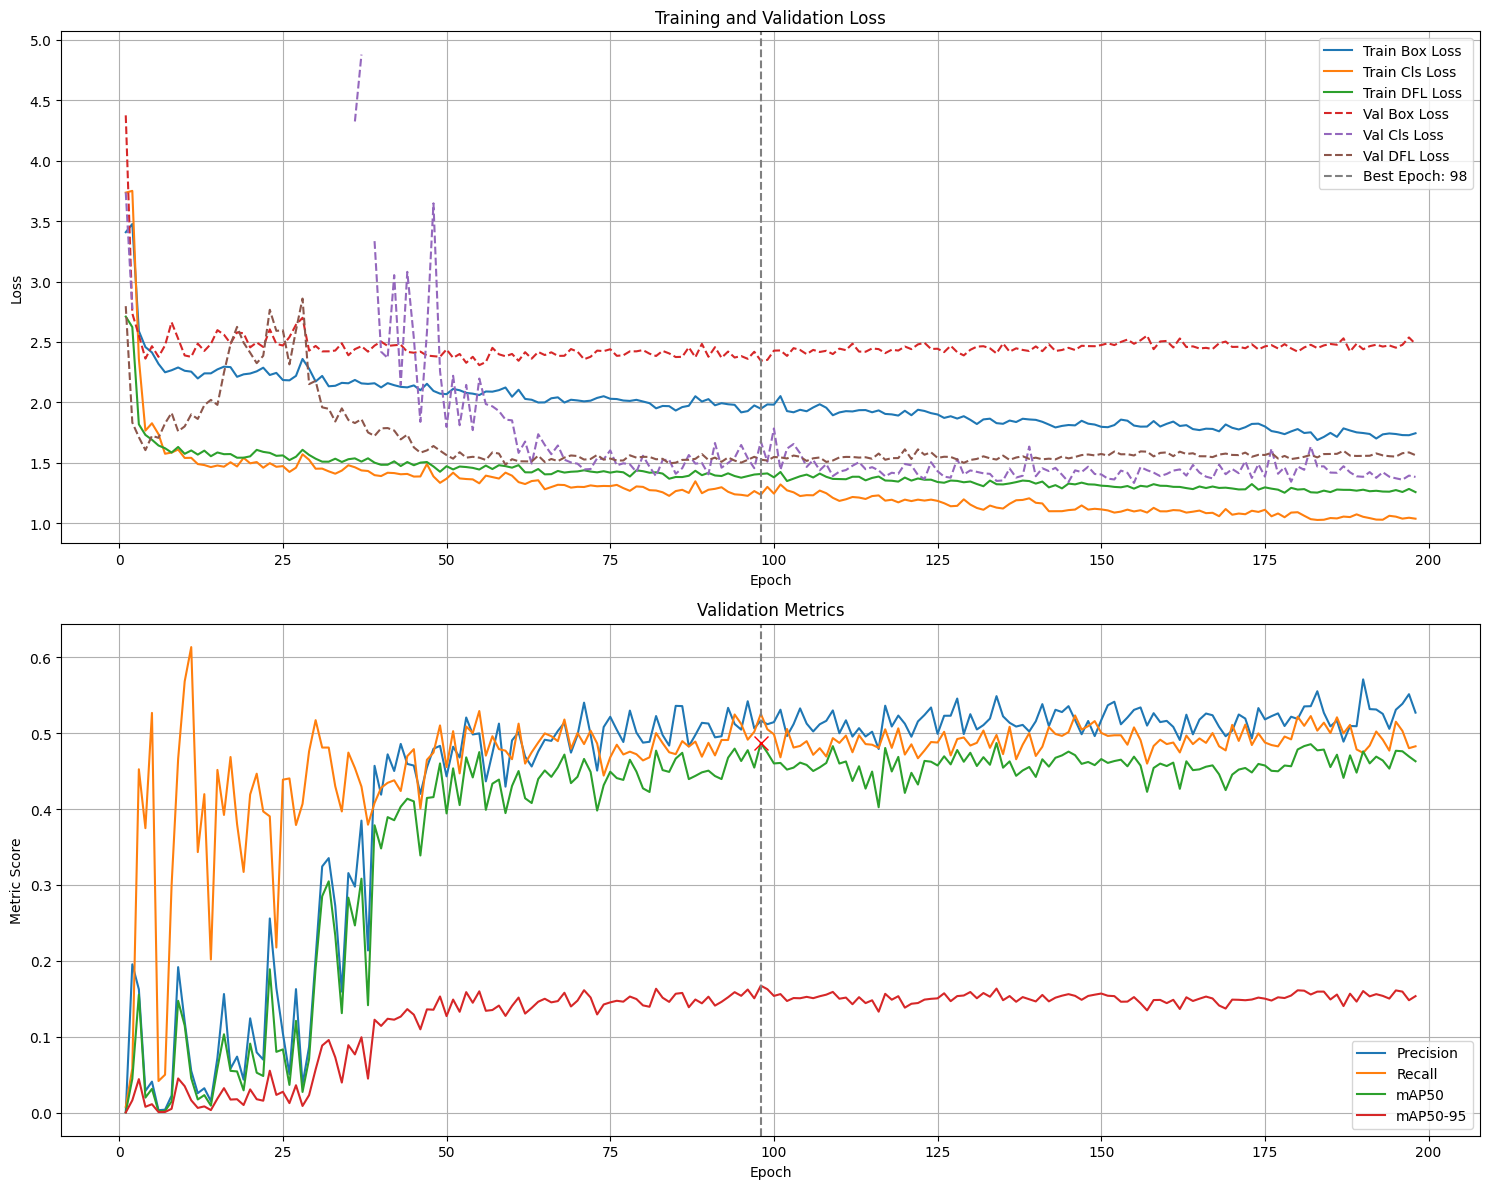

In [244]:
graph_training_metrics(df4, epoch, graph="full")


_**NOTA:** `patience`=100 para EarlyStop_

In [245]:
graph_LrLoss_3D(df4)

Validation set


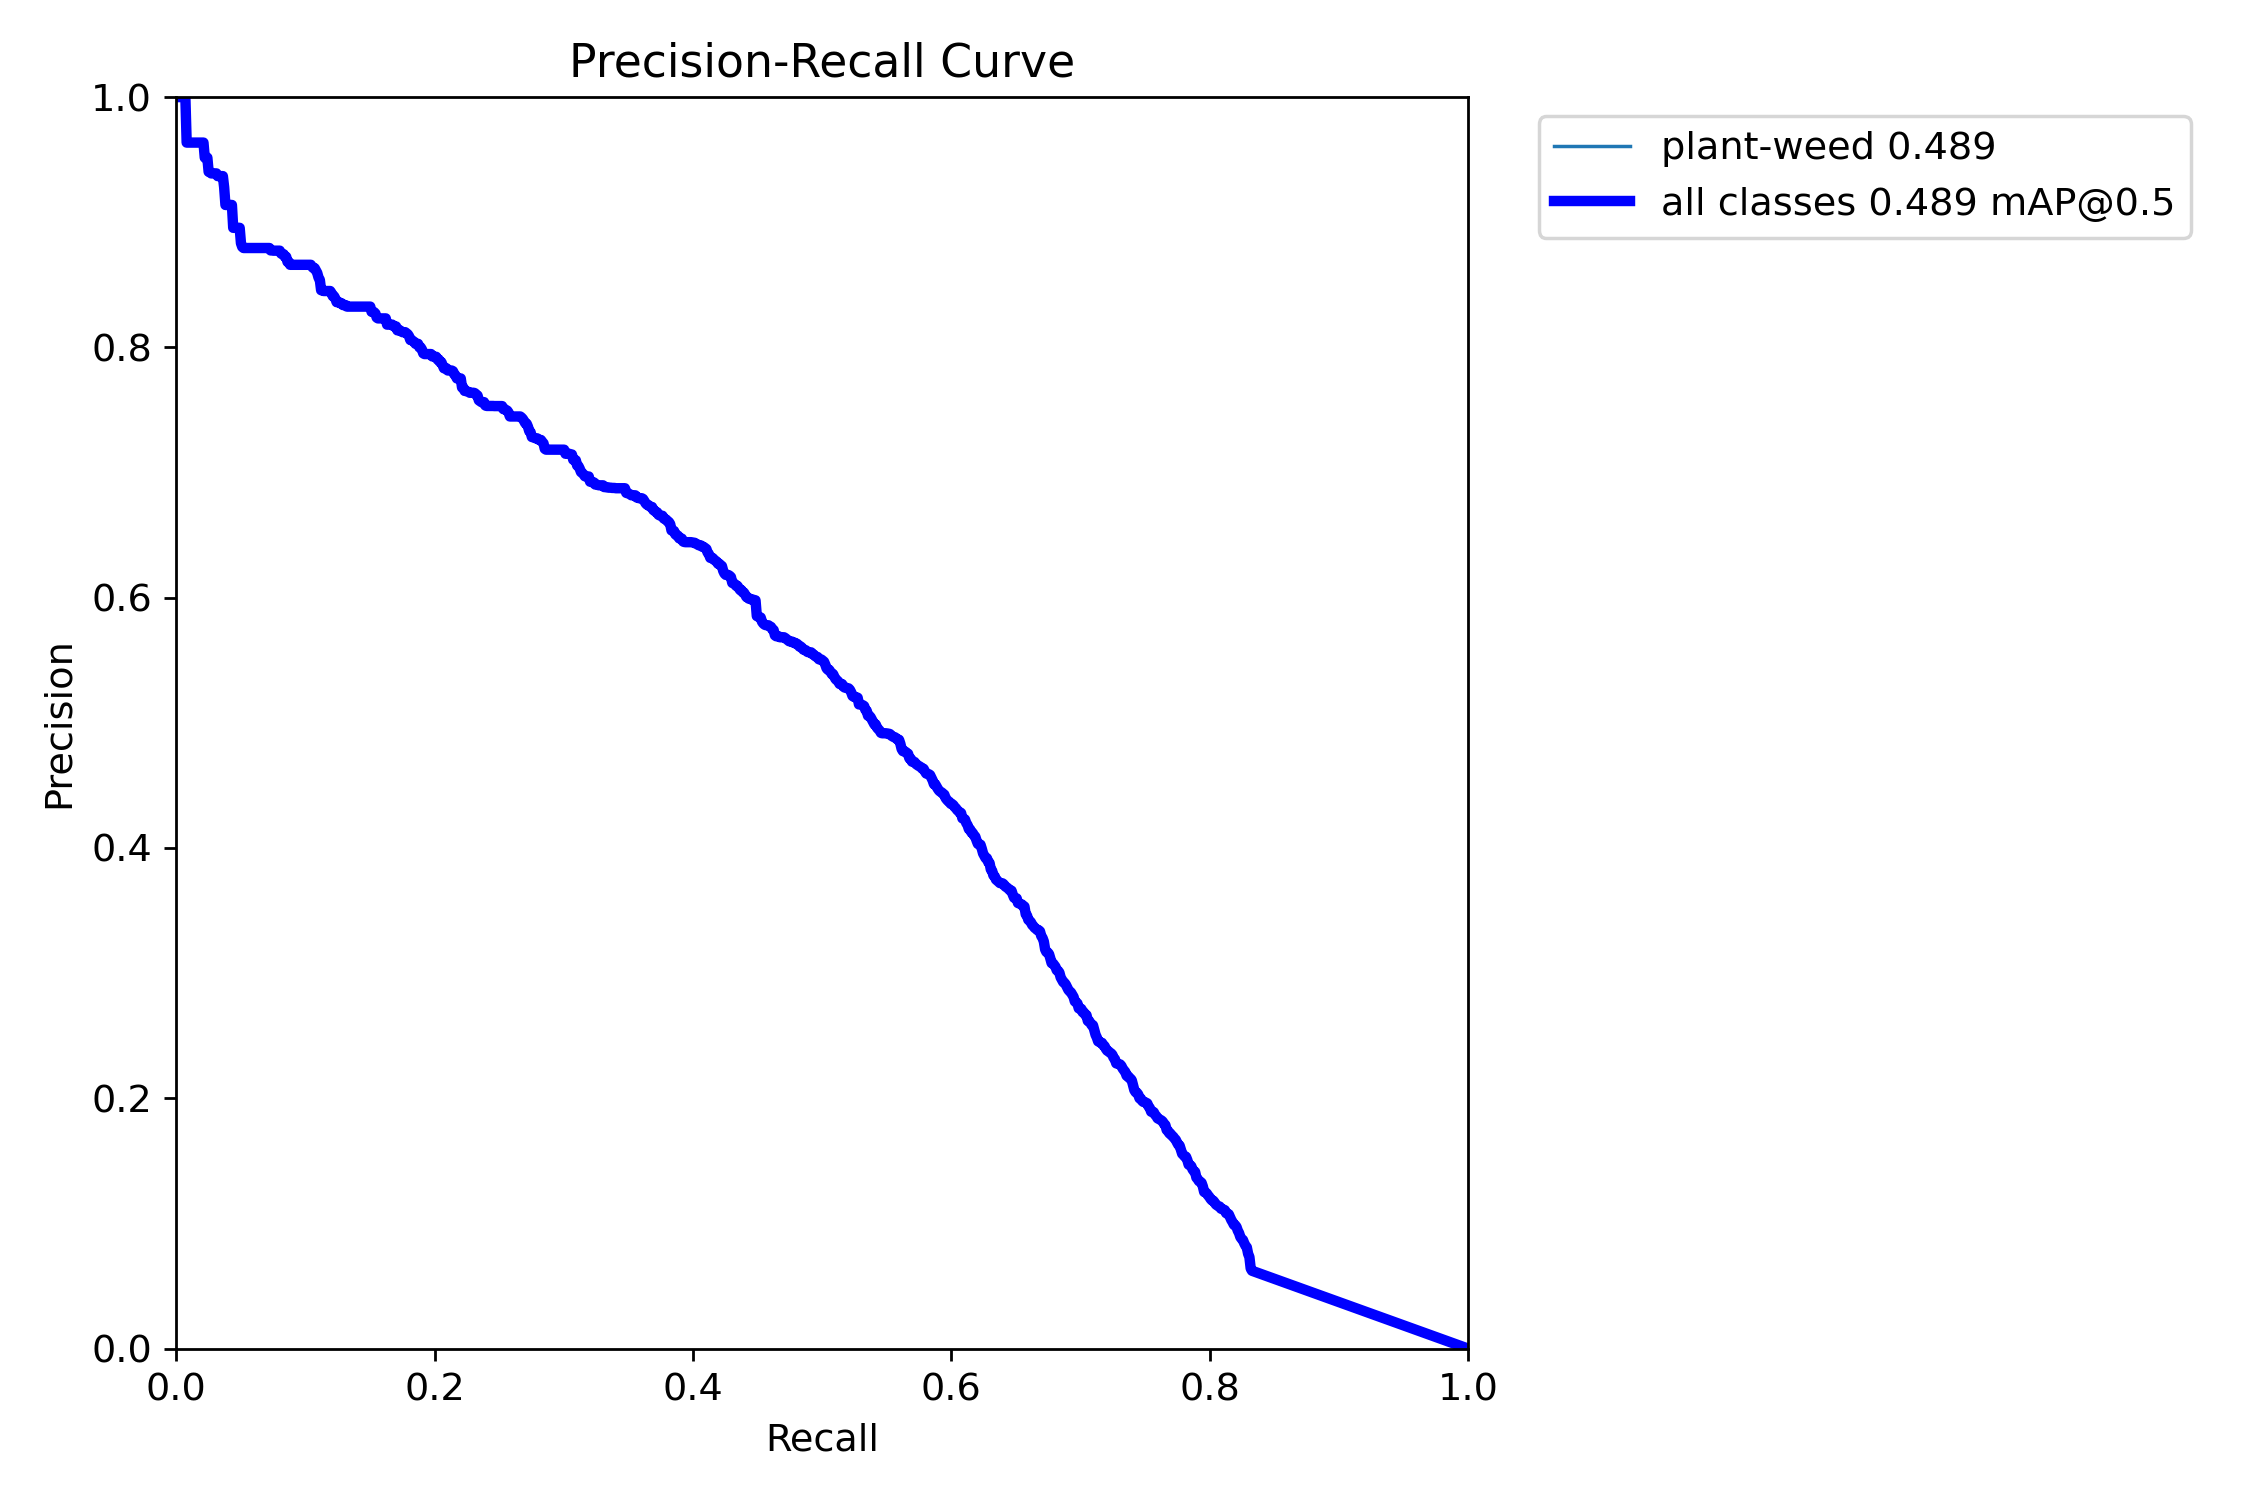

In [246]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

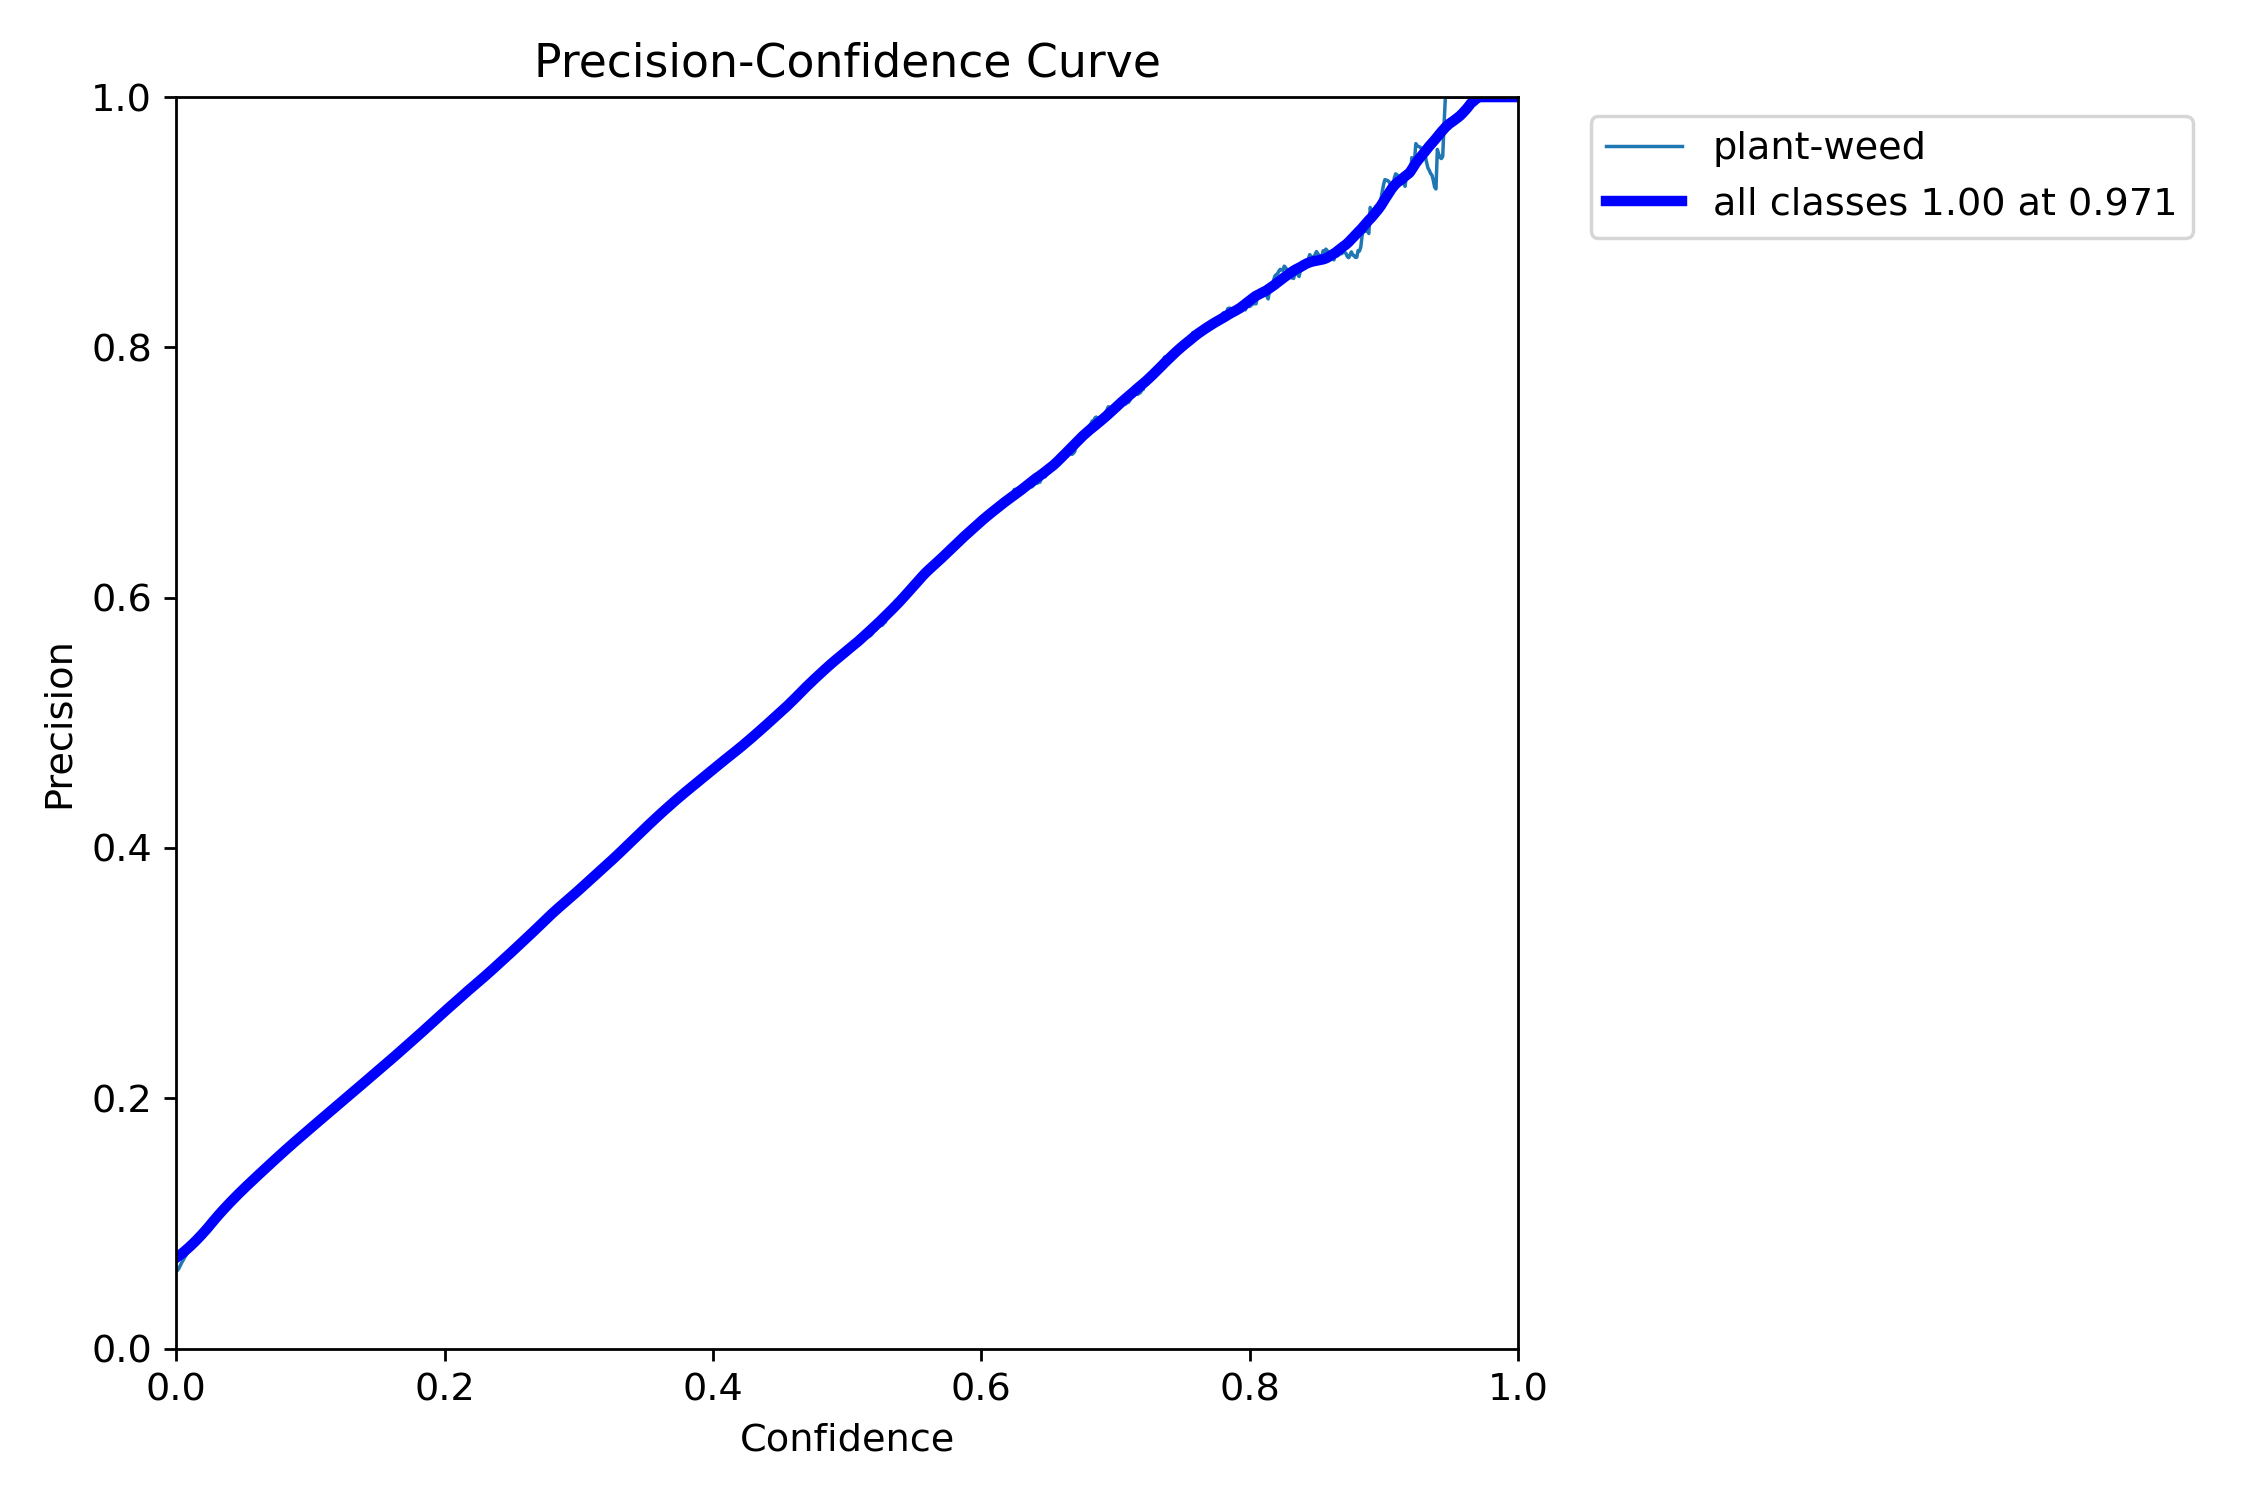

In [247]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

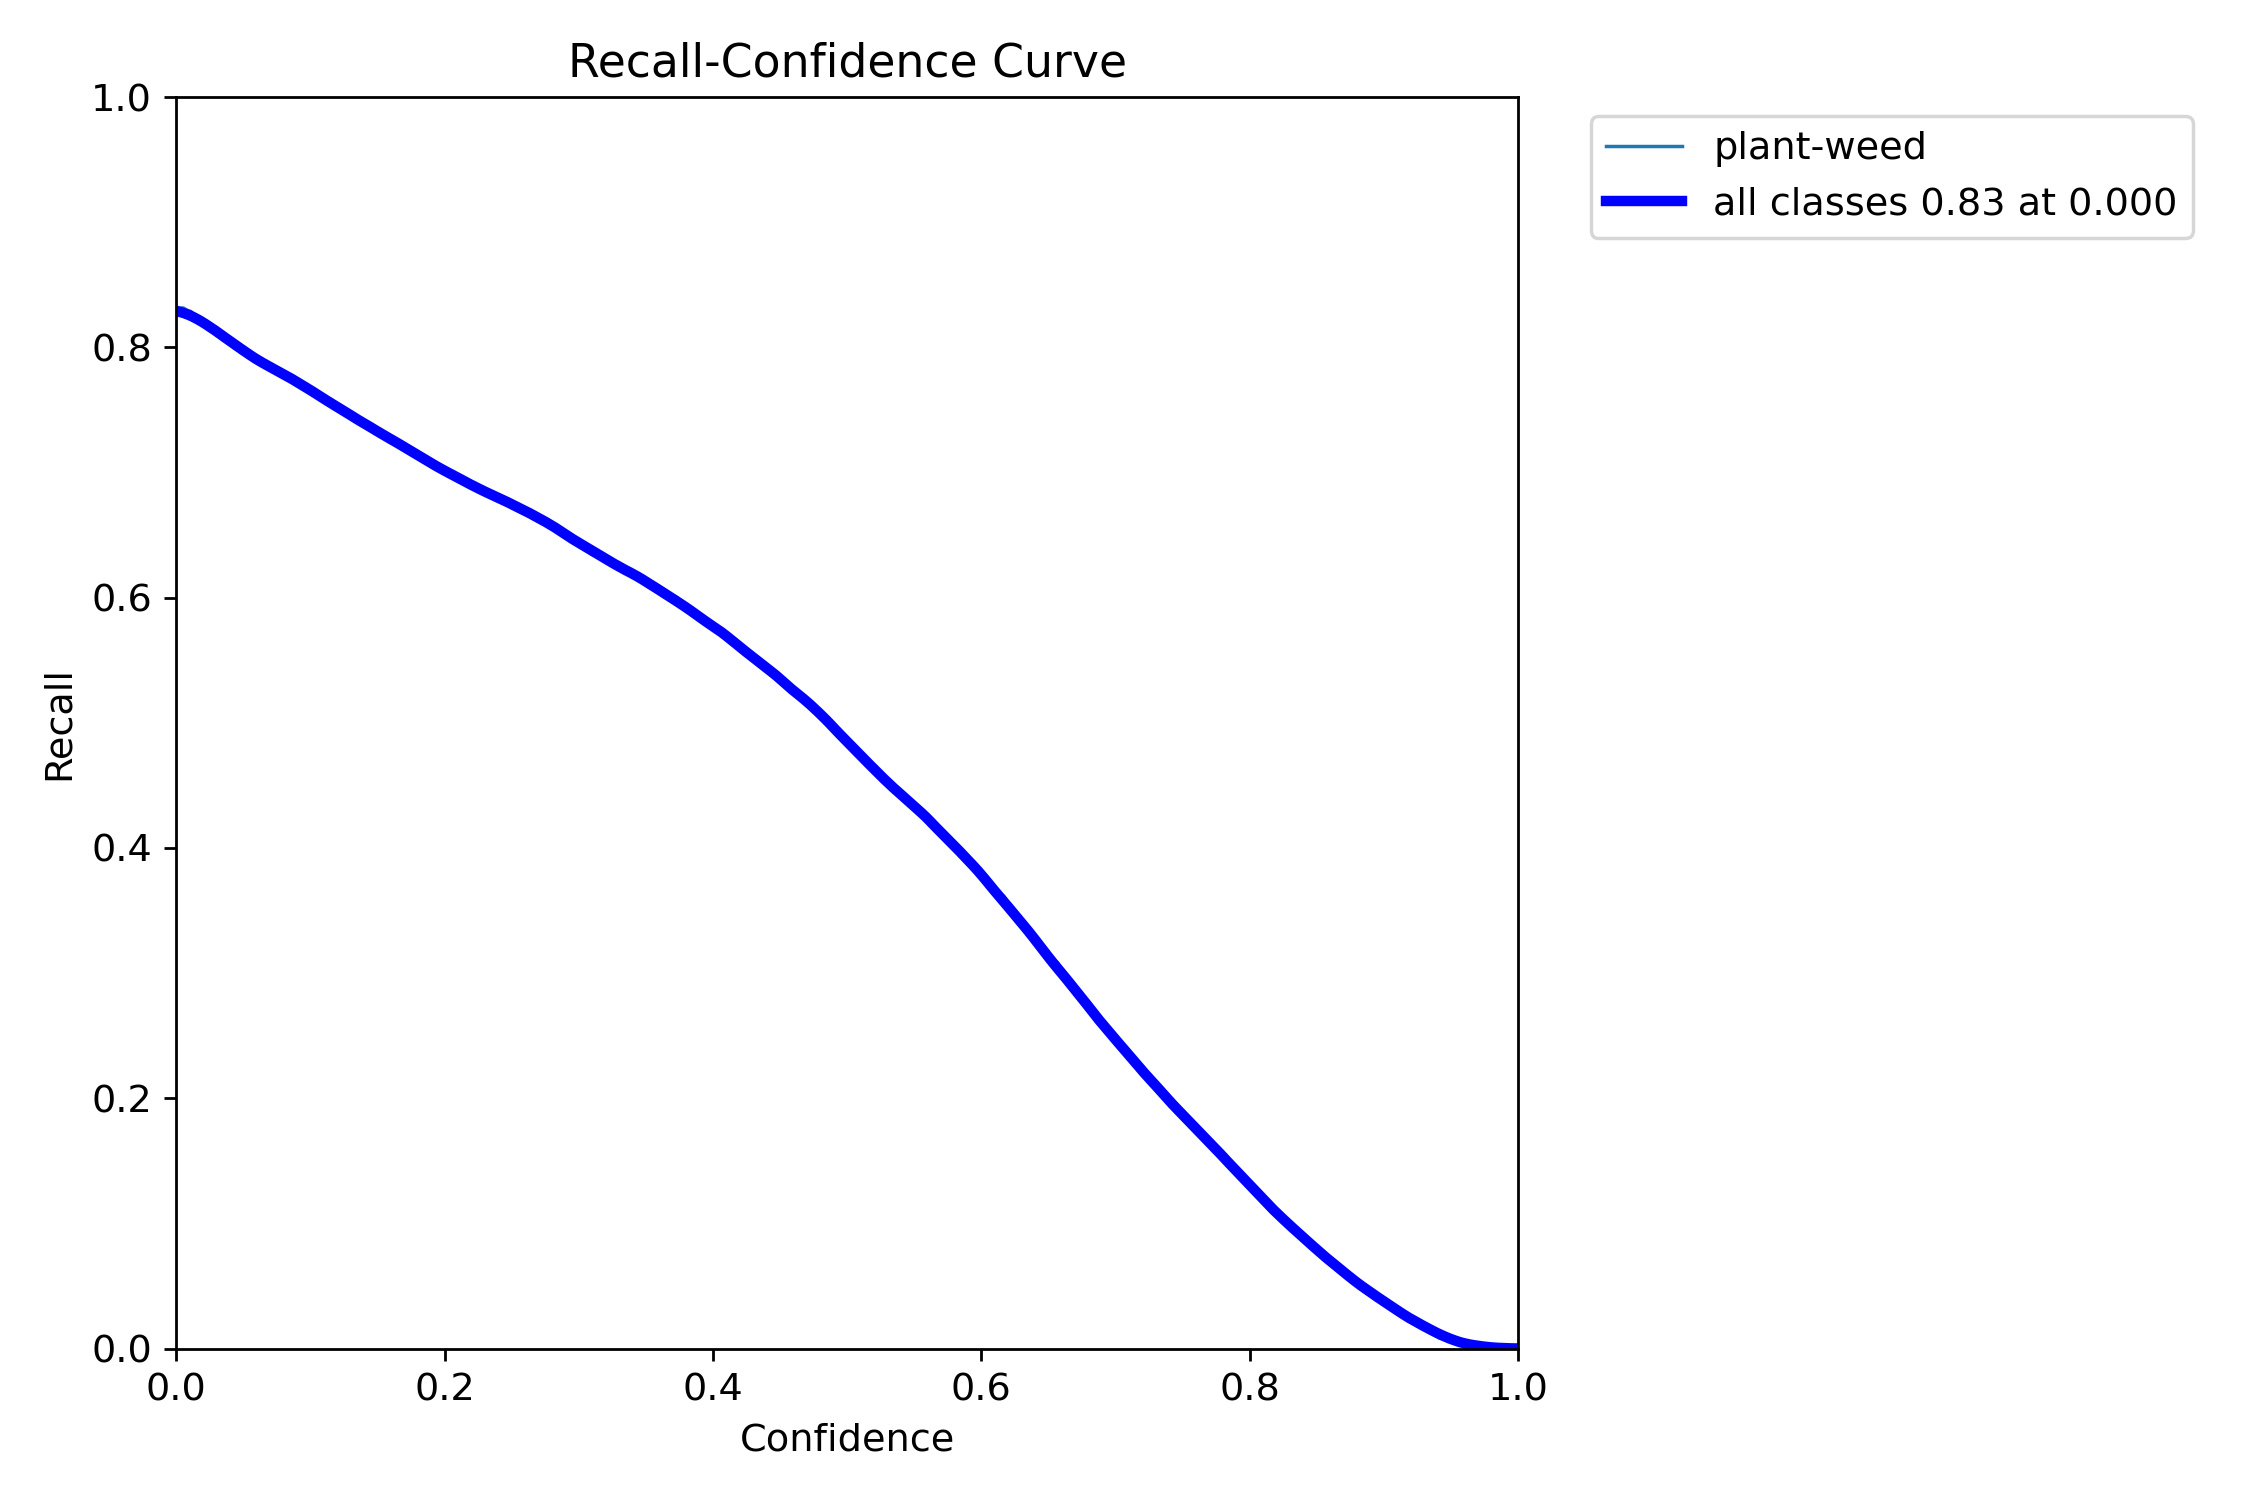

In [248]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

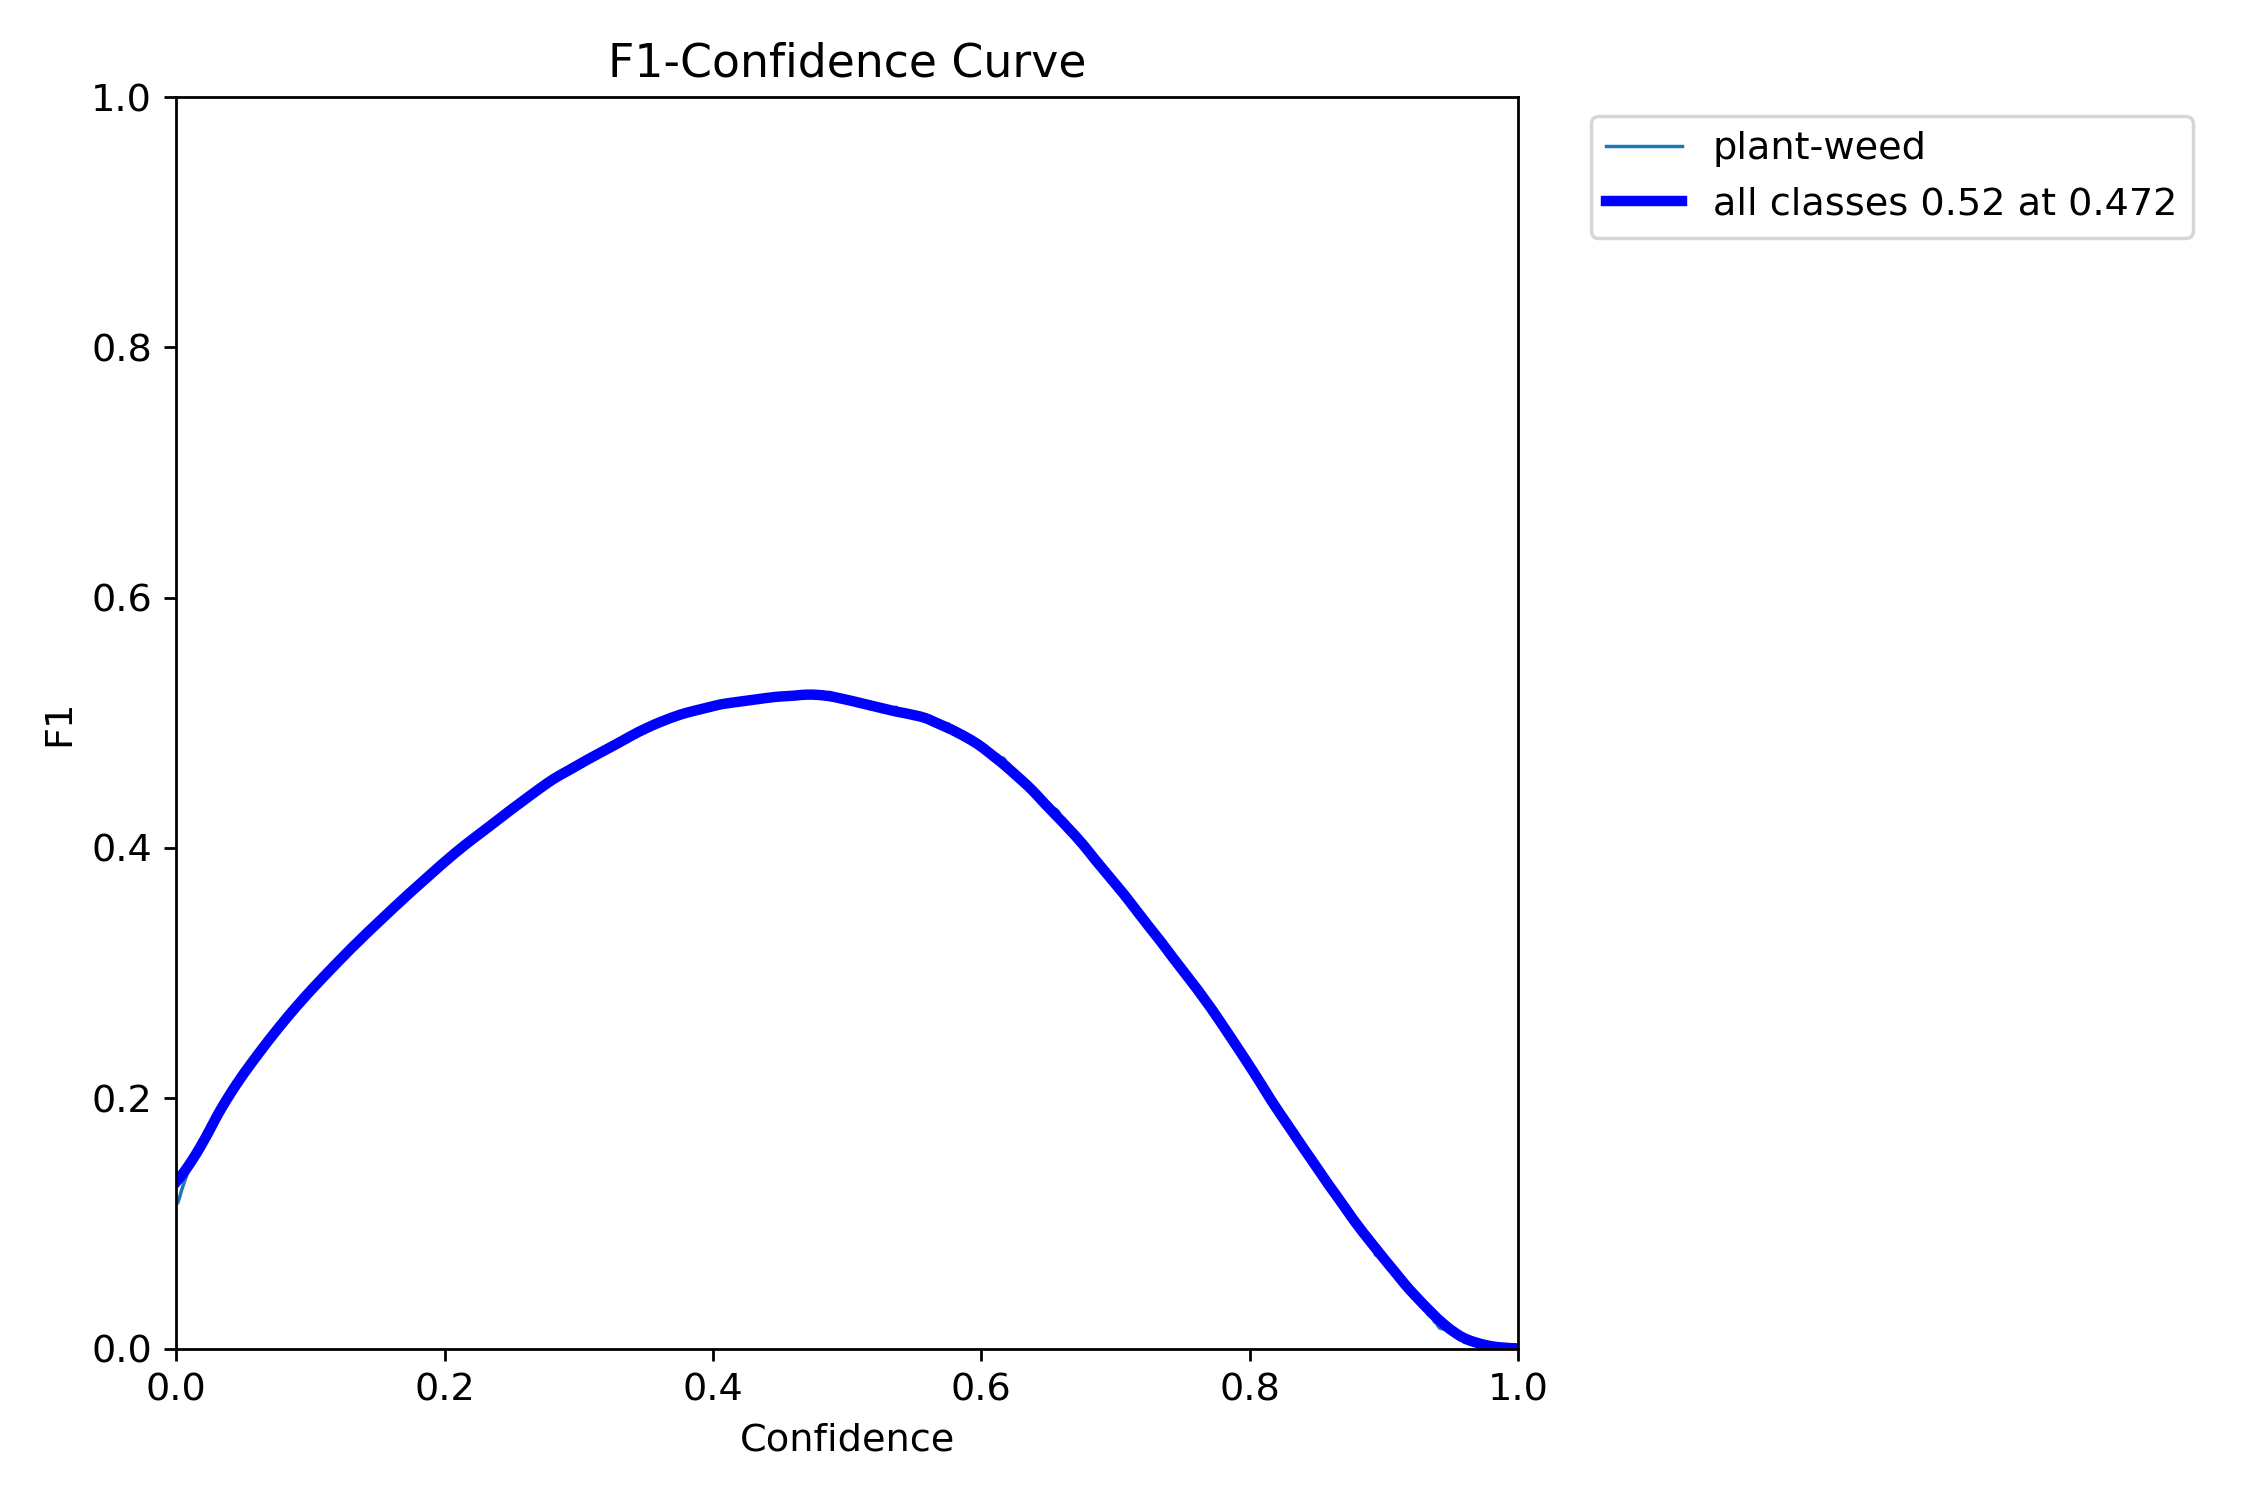

In [249]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

From the F1 curve, the confidence value that optimizes precision and recall is 0.231. In many cases a higher confidence value is desirable.

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

----

# Métricas generales

In [250]:
best_models.index = ['V8','V9','V11','V12']

In [251]:
best_models.sort_values(by='metrics/mAP50(B)', ascending=True)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
V8,361,2792.500,1.20257,0.66073,1.00807,0.54572,0.48236,0.45092,0.14408,2.61832,1.37244,1.71799,0.001287,0.001287,0.001287,50.281833
V9,180,1745.520,1.57606,0.91356,1.24885,0.54504,0.48734,0.46271,0.15455,2.50628,1.35250,1.67852,0.001646,0.001646,0.001646,44.836500
V11,132,1129.730,1.62771,0.96599,1.21858,0.55956,0.50560,0.47743,0.15135,2.48119,1.36224,1.58653,0.001741,0.001741,0.001741,25.394333
V12,98,997.231,1.94758,1.23569,1.40749,0.51662,0.52553,0.48711,0.16720,2.34520,1.67652,1.52583,0.001808,0.001808,0.001808,33.783833


## Graphs

In [ ]:
def plot_metric(metric, ylabel, title, max_epoch=None, init_epoch=None):
    """
    Plots a metric from multiple DataFrames with an optional limit on the x-axis.

    Args:
        metric (str): The column name representing the metric to plot.
        ylabel (str): The label for the y-axis.
        title (str): The title of the plot.
        max_epoch (int, optional): The maximum epoch to display on the x-axis. Defaults to None (no limit).
    """
    plt.figure(figsize=(15, 5))
    plt.plot(df1["epoch"], df1[metric], label=best_models.index[0], linestyle="--", marker="o", markersize=4)
    plt.plot(df2["epoch"], df2[metric], label=best_models.index[1], linestyle="--", marker="s", markersize=4)
    plt.plot(df3["epoch"], df3[metric], label=best_models.index[2], linestyle="--", marker="d", markersize=4)
    plt.plot(df4["epoch"], df4[metric], label=best_models.index[3], linestyle="--", marker="*", markersize=4)
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    if max_epoch is not None:
        if init_epoch is not None:
            plt.xlim(init_epoch, max_epoch)
        else:
            plt.xlim(0, max_epoch)
    else:
        if init_epoch is not None:
            plt.xlim(init_epoch, :)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Training and Validation Losses

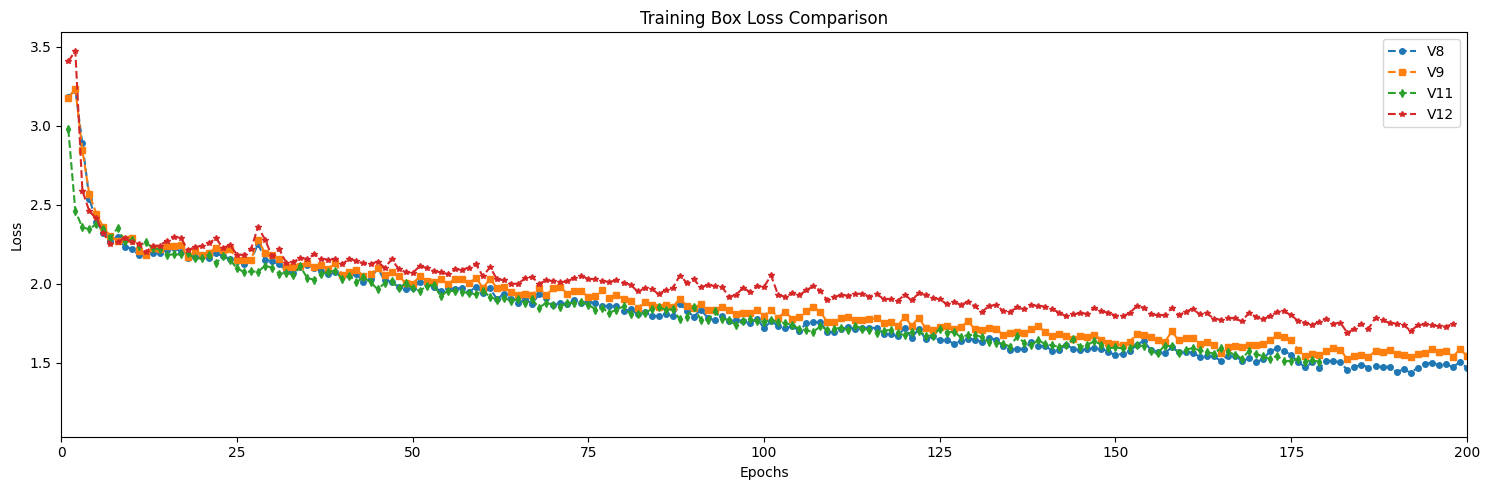

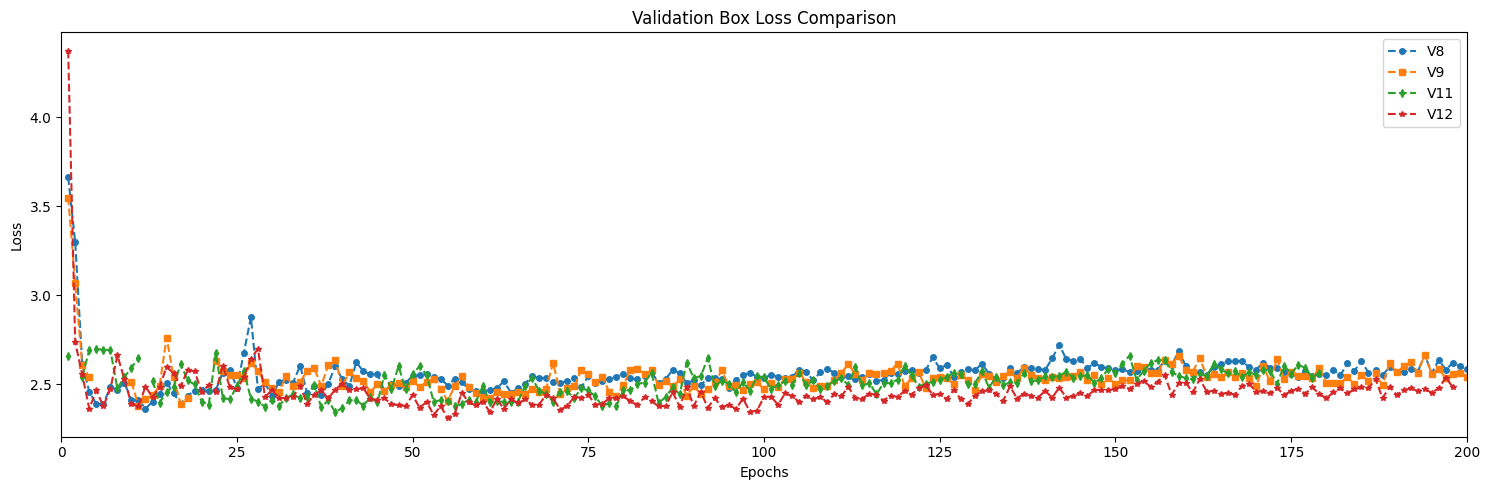

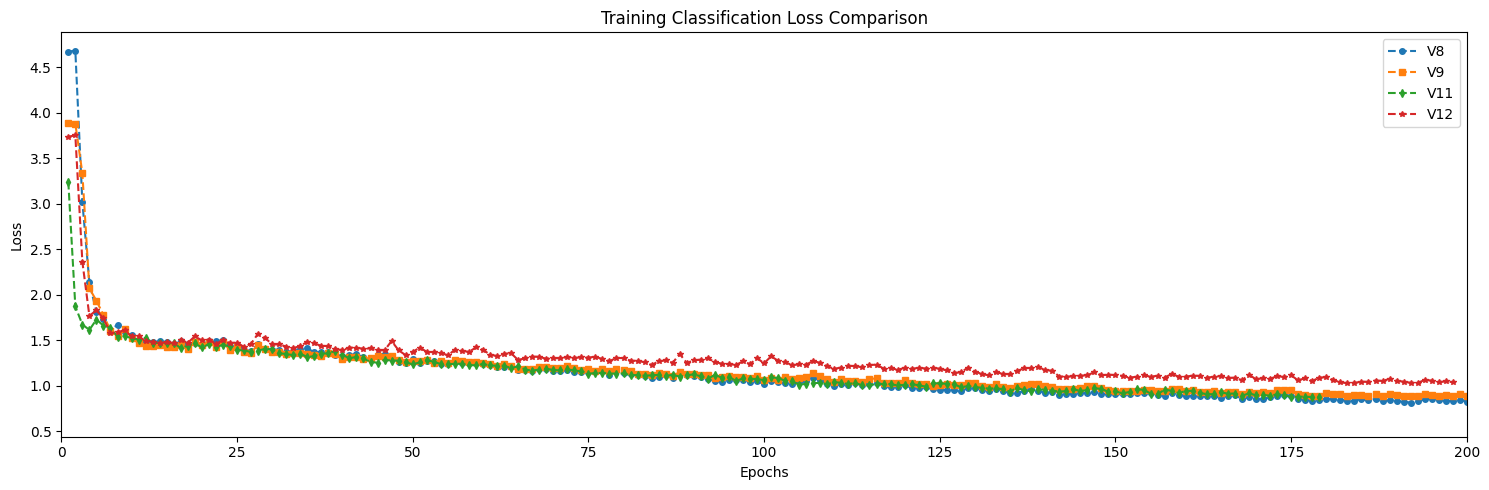

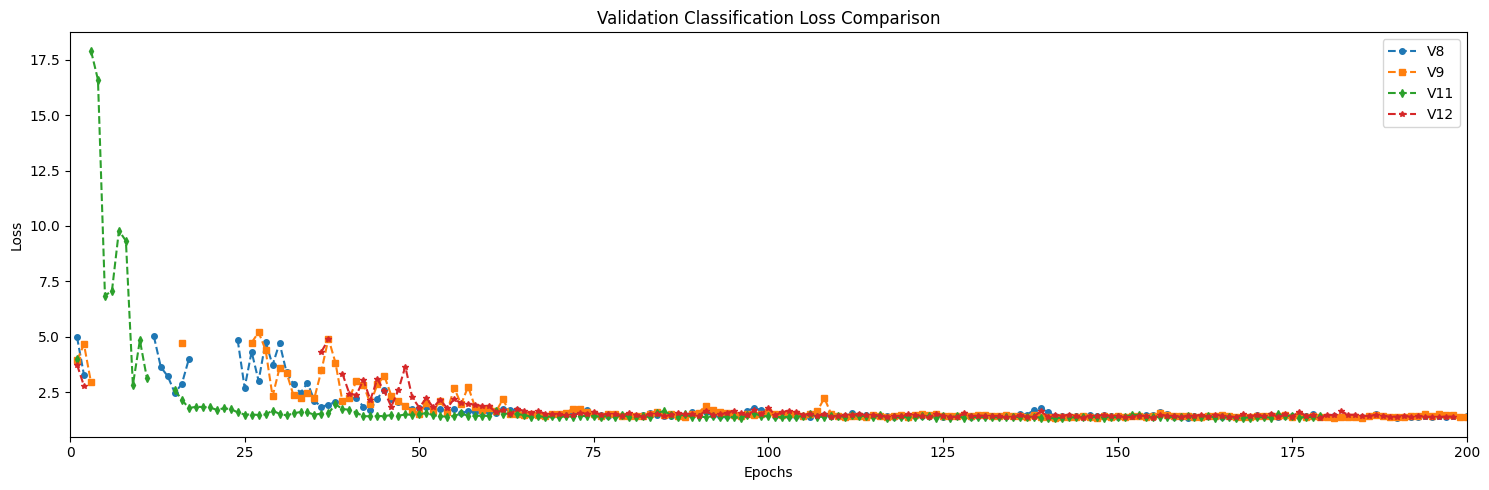

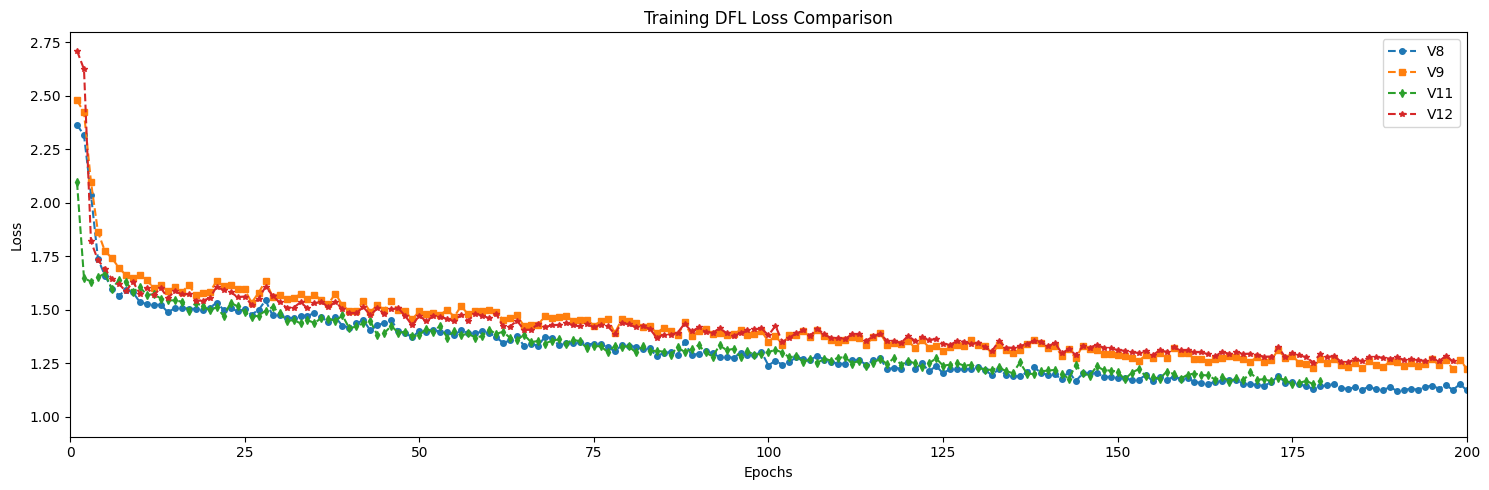

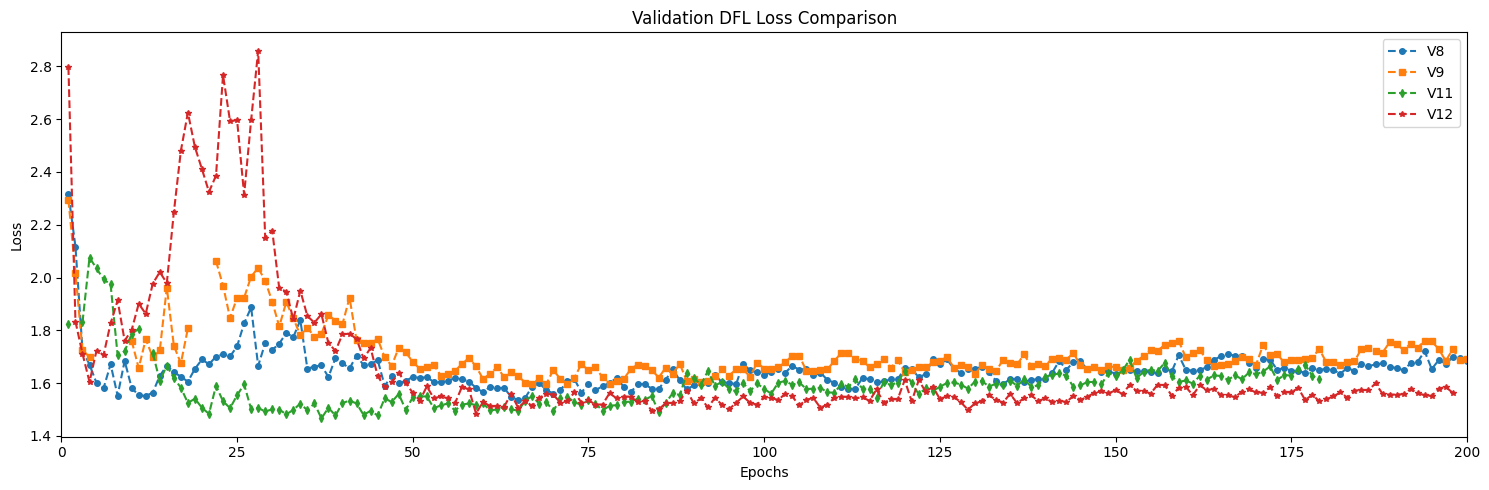

In [260]:
max_epoch = 200 # Set limit for x axes

# Plot Training and Validation Losses
plot_metric("train/box_loss", "Loss", "Training Box Loss Comparison", max_epoch=max_epoch)
plot_metric("val/box_loss", "Loss", "Validation Box Loss Comparison", max_epoch=max_epoch)

plot_metric("train/cls_loss", "Loss", "Training Classification Loss Comparison", max_epoch=max_epoch)
plot_metric("val/cls_loss", "Loss", "Validation Classification Loss Comparison", max_epoch=max_epoch)

plot_metric("train/dfl_loss", "Loss", "Training DFL Loss Comparison", max_epoch=max_epoch)
plot_metric("val/dfl_loss", "Loss", "Validation DFL Loss Comparison", max_epoch=max_epoch)

### Performance Metrics

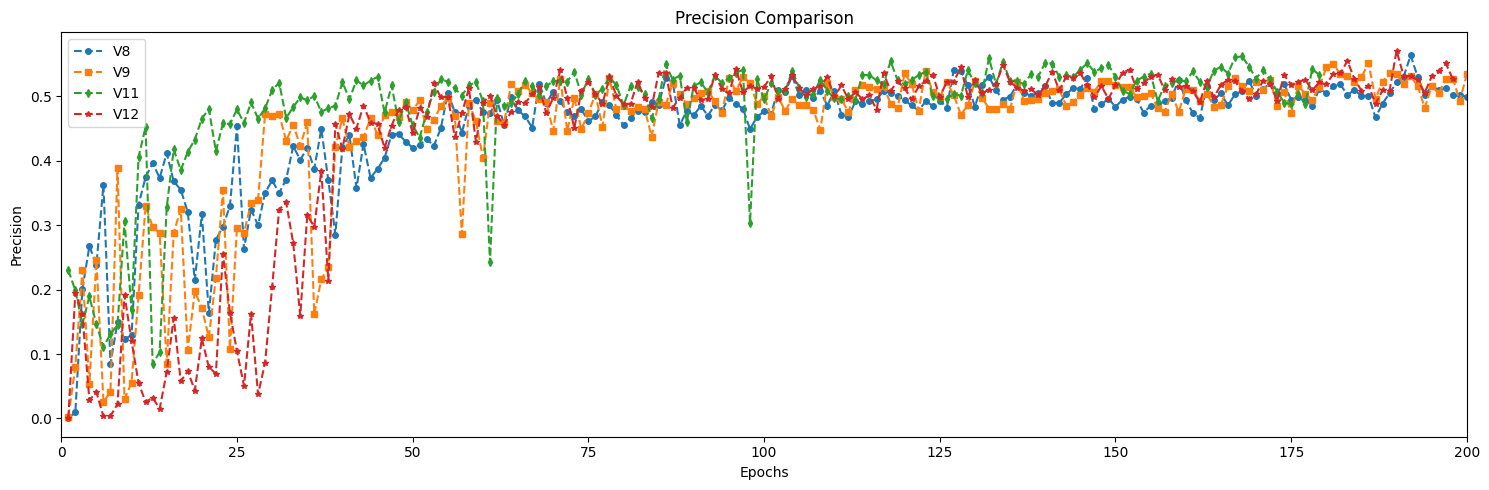

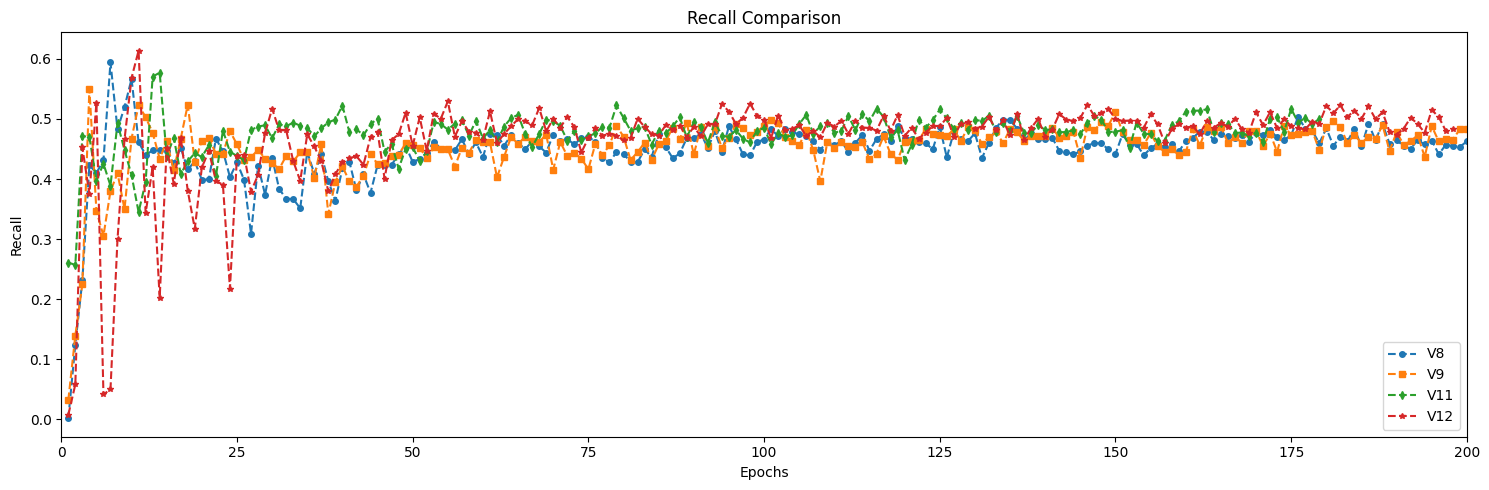

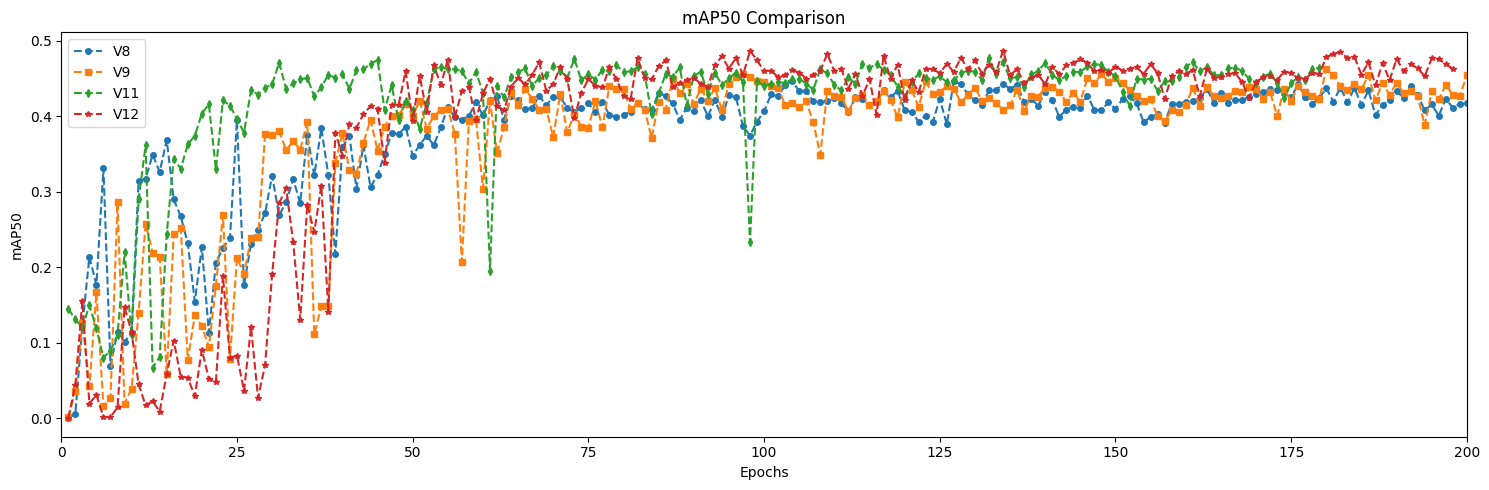

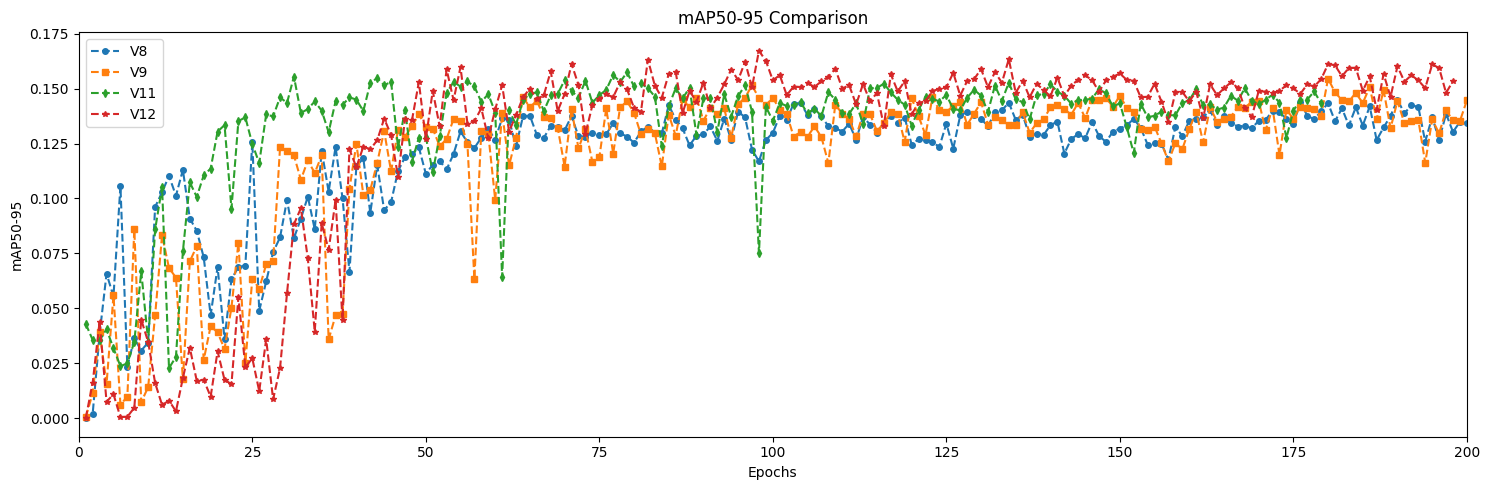

In [261]:
# Plot Performance Metrics
plot_metric("metrics/precision(B)", "Precision", "Precision Comparison", max_epoch=max_epoch)
plot_metric("metrics/recall(B)", "Recall", "Recall Comparison", max_epoch=max_epoch)
plot_metric("metrics/mAP50(B)", "mAP50", "mAP50 Comparison", max_epoch=max_epoch)
plot_metric("metrics/mAP50-95(B)", "mAP50-95", "mAP50-95 Comparison", max_epoch=max_epoch)

### Learning Rate

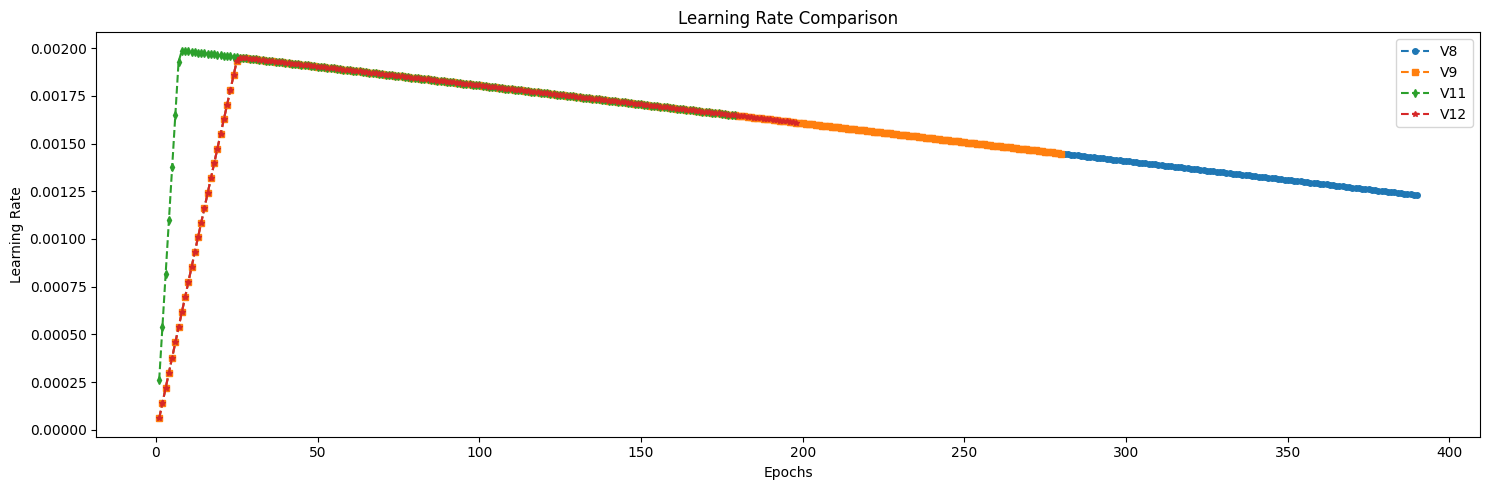

In [262]:
# Plot Learning Rate
plot_metric("lr/pg0", "Learning Rate", "Learning Rate Comparison")

## Resumen de los Experimentos

| Experiment | Dataset (Size) | Images | Tiles | Tags | Train/Valid (%) | Train Time (min) | Inf Time (ms) | Total detections | True Positives | False Positives | False Negatives | mAP@0.5 |
|------------|------|------|--------------|---------|------|------|----------------|---------------|---------------|---------------|---------------|--------|
| **YOLO v8** | Small & Mid | 6 | 324 | 7669 | 67% / 33% | 50.28 | **25.7** | 3593 | 38.24% | 32.95% | 28.81% | **0.451** |
| **YOLO v9** | Small & Mid | 6 | 324 | 7669 | 67% / 33% | 44.84 | **34.3** | 3899 | 37.63% | 38.21% | 24.16% | **0.463** |
| **YOLO v11** | Small & Mid | 6 | 324 | 7669 | 67% / 33% | 25.39 | **26.2** | 4638 | 36.03% | 48.06% | 15.91% | **0.477** |
| **YOLO v12** | Small & Mid | 6 | 324 | 7669 | 67% / 33% | 33.78 | **35.1** | 5783 | 30.68% | 58.34% | 10.98% | **0.487** |

- Yolo V8 presenta el mejor valor de TP, pero menor cantidad de detecciones.
- Yolo V11 representa una disminución del -5.8% en TP, con un incremento del 29% en las detecciones.
- Yolo v9 sería un punto intermedio: -1.6% en TP y 8,5% en detecciones.

**Best result:**
- **YOLO v8:** _Exp 19 **(3.5m | 90º)**_ , Small & Mid -> 3593 det, TP 38,24% & mAP 0.451

#### Criterio de análisis

Para nuestro problema se prefiere:
1. Aquel modelo que genere un mayor número de detecciones _(idealmente TP)_.
2. Que el modelo tienda a generar más FP _(sesgado al alza)_ que FN _(no detecta plantas)_.
3. Se utiliza el mAP@0.5 ya que no se prioriza la posición del BB, pero si la cuenta de objetos.

## Comparación de los Entrenamientos

### Análisis del Dataset
- **Cantidad de imágenes y etiquetas**:  
  -  

- **Distribución de Train/Valid**:  
  -  

- **Tamaño de imágenes (small vs mid)**:  
  -  

### Análisis de los Hiperparámetros
- **Modelo (yolov8n)**: Se mantuvo constante en todos los entrenamientos, lo que permite una comparación justa.  
- **Epochs (100)**: En los tres experimentos, el modelo parece alcanzar su rendimiento máximo antes de completar todas las épocas, lo que podría indicar que no se necesita entrenar tantas iteraciones.  
- **Batch Size (64)**: Se mantiene igual en todos los experimentos.  
- **Freeze (10)**: Congelar los primeros 10 capas del modelo en los tres entrenamientos podría estar limitando la capacidad de ajuste en las primeras etapas.  

### Análisis de Resultados
#### Métricas Generales
- **Precisión (Precision) y Recall**:  
  -  

- **mAP50**:  
  - 
  
- **Confusión entre clases (False Positives y False Negatives)**:  
  - 
  
### Conclusiones Generales
1. 

# Conclusión Final


## Estrategias para Próximos Entrenamientos
1. **Dataset**
- 

2. **Hiperparámetros**
-  

3. **Optimización del Modelo**
- 

4. **Evaluación y Métricas**
-  